# CELL 1: Imports

In [1]:
import os, re, random, warnings, pickle, csv, json, math, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertForSequenceClassification, BertTokenizer,
    DistilBertForSequenceClassification, DistilBertTokenizer,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, precision_recall_fscore_support,
    confusion_matrix, accuracy_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime
from collections import Counter

try:
    import nltk
    from nltk.corpus import stopwords
    nltk.download('stopwords', quiet=True)
    STOP_WORDS = set(stopwords.words('english'))
    HAS_NLTK = True
    print(f"NLTK stopwords available: {len(STOP_WORDS)} words")
except ImportError:
    HAS_NLTK = False
    STOP_WORDS = set()
    print("WARNING: pip install nltk")

try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True; print("WordCloud available")
except ImportError:
    HAS_WORDCLOUD = False; print("pip install wordcloud")

try:
    from bertviz import model_view, head_view
    HAS_BERTVIZ = True; print("BertViz available")
except ImportError:
    HAS_BERTVIZ = False; print("pip install bertviz")

try:
    from lime.lime_text import LimeTextExplainer
    HAS_LIME = True; print("LIME available")
except ImportError:
    HAS_LIME = False; print("pip install lime")

try:
    import shap
    HAS_SHAP = True; print("SHAP available")
except ImportError:
    HAS_SHAP = False; print("pip install shap")

try:
    import gradio as gr
    HAS_GRADIO = True; print("Gradio available")
except ImportError:
    HAS_GRADIO = False; print("pip install gradio")

try:
    from flask import Flask, request, jsonify
    HAS_FLASK = True; print("Flask available")
except ImportError:
    HAS_FLASK = False; print("pip install flask")

try:
    import emoji as emoji_lib
    HAS_EMOJI = True
    print(f"emoji library available ({len(emoji_lib.EMOJI_DATA)} emojis)")
except ImportError:
    HAS_EMOJI = False
    print("WARNING: pip install emoji")

warnings.filterwarnings('ignore')
os.environ["TOKENIZERS_PARALLELISM"] = "false"

print(f"\nPyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

c:\Users\kirubaharan\anaconda3\envs\hatefusion\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


NLTK stopwords available: 198 words
WordCloud available
BertViz available
LIME available
SHAP available
Gradio available
Flask available
emoji library available (5225 emojis)

PyTorch: 2.10.0+cpu, CUDA: False


# CELL 2 — Configuration

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

for d in ['models', 'figures', 'results', 'logs']:
    os.makedirs(d, exist_ok=True)

VERIFY_MODE = True

if VERIFY_MODE:
    SEEDS = [42]
    MAX_EPOCHS = 6
    TOXIGEN_SAMPLE = 20000
else:
    SEEDS = [42, 43, 44, 45, 46]
    MAX_EPOCHS = 16
    TOXIGEN_SAMPLE = None
    print("FULL MODE: 5 seeds, 16 epochs, full Toxigen")

ACTUAL_BATCH_SIZE = 16
GRADIENT_ACCUMULATION_STEPS = 2
EFFECTIVE_BATCH_SIZE = ACTUAL_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS

CONFIG = {
    'learning_rate': 1e-5,
    'actual_batch_size': ACTUAL_BATCH_SIZE,
    'gradient_accumulation_steps': GRADIENT_ACCUMULATION_STEPS,
    'effective_batch_size': EFFECTIVE_BATCH_SIZE,
    'epochs': MAX_EPOCHS,
    'max_length': 128,
    'fp16': torch.cuda.is_available(),
    'warmup_ratio': 0.1,
    'weight_decay': 0.01,
    'early_stopping_patience': 3,
    'bert_model': 'bert-base-uncased',
    'distilbert_model': 'distilbert-base-uncased',
}

EMOJI_JSON_PATH = "D:\hatefusion_project\HateFusion\data\emoji_data.JSON" 
EMOJI_SENTIMENT_PATH = "D:\hatefusion_project\HateFusion\data\Emoji_Sentiment_Data_v1.0.csv"  

print(f"Emoji JSON path: {EMOJI_JSON_PATH}")
print(f"Emoji Sentiment path: {EMOJI_SENTIMENT_PATH}")

print(f"Effective batch size: {EFFECTIVE_BATCH_SIZE} (paper=32)")
print(f"Seeds: {SEEDS}")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Device: cpu
Emoji JSON path: D:\hatefusion_project\HateFusion\data\emoji_data.JSON
Emoji Sentiment path: D:\hatefusion_project\HateFusion\data\Emoji_Sentiment_Data_v1.0.csv
Effective batch size: 32 (paper=32)
Seeds: [42]
  learning_rate: 1e-05
  actual_batch_size: 16
  gradient_accumulation_steps: 2
  effective_batch_size: 32
  epochs: 6
  max_length: 128
  fp16: False
  warmup_ratio: 0.1
  weight_decay: 0.01
  early_stopping_patience: 3
  bert_model: bert-base-uncased
  distilbert_model: distilbert-base-uncased


# Cell 3: Dataset Paths

In [3]:
TOXIGEN_PATH   = "data/toxigen.csv"
IHC_STG1_POSTS = "data/implicit_hate_v1_stg1_posts.csv"
IHC_STG1_IDS   = "data/implicit_hate_v1_stg1.csv"
IHC_STG2_POSTS = "data/implicit_hate_v1_stg2_posts.csv"
IHC_STG2_IDS   = "data/implicit_hate_v1_stg2.csv"
IHC_STG3_POSTS = "data/implicit_hate_v1_stg3_posts.csv"
IHC_STG3_IDS   = "data/implicit_hate_v1_stg3.csv"
IHC_SAP_POSTS  = "data/implicit_hate_v1_SAP_posts.csv"
IMPGAB_PATH    = "data/GabHateCorpus_annotations_unique.csv"

all_paths = {
    'Toxigen': TOXIGEN_PATH, 'IHC Stg1 Posts': IHC_STG1_POSTS,
    'IHC Stg1 IDs': IHC_STG1_IDS, 'IHC Stg2 Posts': IHC_STG2_POSTS,
    'IHC Stg2 IDs': IHC_STG2_IDS, 'IHC Stg3 Posts': IHC_STG3_POSTS,
    'IHC Stg3 IDs': IHC_STG3_IDS, 'IHC SAP Posts': IHC_SAP_POSTS,
    'ImpGab': IMPGAB_PATH,
}
all_found = True
for name, path in all_paths.items():
    exists = os.path.exists(path)
    sz = f"({os.path.getsize(path)/1e6:.1f} MB)" if exists else "NOT FOUND"
    print(f"  {name:<20} {sz}")
    if not exists:
        all_found = False
print(f"\n{'All files found!' if all_found else 'WARNING: Some files missing'}")

  Toxigen              (165.1 MB)
  IHC Stg1 Posts       (2.2 MB)
  IHC Stg1 IDs         (0.7 MB)
  IHC Stg2 Posts       (0.7 MB)
  IHC Stg2 IDs         (0.2 MB)
  IHC Stg3 Posts       (0.9 MB)
  IHC Stg3 IDs         (0.4 MB)
  IHC SAP Posts        (0.1 MB)
  ImpGab               (4.5 MB)

All files found!


# Cell 3.5: Emoji Processor

In [4]:

try:
    with open(EMOJI_JSON_PATH, 'r', encoding='utf-8') as f:
        MANUAL_HATE_EMOJI_DICT = json.load(f)
    print(f"Layer 1: Loaded {len(MANUAL_HATE_EMOJI_DICT)} hate emojis from {EMOJI_JSON_PATH}")
except FileNotFoundError:
    print(f"Layer 1: {EMOJI_JSON_PATH} not found — using empty dict")
    MANUAL_HATE_EMOJI_DICT = {}
except json.JSONDecodeError as e:
    print(f"Layer 1: JSON error in {EMOJI_JSON_PATH}: {e}")
    MANUAL_HATE_EMOJI_DICT = {}

if MANUAL_HATE_EMOJI_DICT:
    print("  Sample entries:")
    for i, (em, info) in enumerate(list(MANUAL_HATE_EMOJI_DICT.items())[:5]):
        print(f"    {em} → {info.get('meaning','?')} (score: {info.get('hate_score',0)})")

EMOJI_SENTIMENT_DICT = {}
try:
    _esdf = pd.read_csv(EMOJI_SENTIMENT_PATH)
    for _, row in _esdf.iterrows():
        EMOJI_SENTIMENT_DICT[row['Emoji']] = {
            'Negative': int(row['Negative']),
            'Neutral': int(row['Neutral']),
            'Positive': int(row['Positive']),
            'Position': float(row['Position']),
            'Unicode_name': str(row['Unicode name']),
            'Occurrences': int(row['Occurrences']),
        }
    print(f"Layer 2: Loaded {len(EMOJI_SENTIMENT_DICT)} emojis from sentiment ranking")
except FileNotFoundError:
    print(f"Layer 2: {EMOJI_SENTIMENT_PATH} not found — Layer 2 disabled")
except Exception as e:
    print(f"Layer 2: Error loading sentiment ranking: {e}")


if HAS_EMOJI:
    print(f"Layer 3: emoji library ready ({len(emoji_lib.EMOJI_DATA)} emojis)")
else:
    print(f"Layer 3: emoji library not installed")

print(f"\nTotal emoji coverage: Layer1={len(MANUAL_HATE_EMOJI_DICT)} + "
      f"Layer2={len(EMOJI_SENTIMENT_DICT)} + Layer3={len(emoji_lib.EMOJI_DATA) if HAS_EMOJI else 0}")


def emoji_get_info(emoji_char):
   
    if emoji_char in MANUAL_HATE_EMOJI_DICT:
        info = MANUAL_HATE_EMOJI_DICT[emoji_char]
        return {
            'emoji': emoji_char,
            'meaning': info.get('meaning', 'unknown_hate'),
            'hate_score': float(info.get('hate_score', 0.5)),
            'sentiment': -float(info.get('hate_score', 0.5)),
            'category': info.get('category', 'hate'),
            'description': info.get('description', ''),
            'source': 'hate_dict',
            'is_hate_emoji': True,
        }

    if emoji_char in EMOJI_SENTIMENT_DICT:
        row = EMOJI_SENTIMENT_DICT[emoji_char]
        total = row['Negative'] + row['Neutral'] + row['Positive']
        if total > 0:
            neg_ratio = row['Negative'] / total
            pos_ratio = row['Positive'] / total
            sentiment = pos_ratio - neg_ratio
        else:
            neg_ratio = pos_ratio = sentiment = 0.0
        hate_score = max(0.0, neg_ratio - 0.3) if neg_ratio > 0.4 else 0.0
        return {
            'emoji': emoji_char,
            'meaning': row['Unicode_name'].lower().replace(' ', '_'),
            'hate_score': round(hate_score, 4),
            'sentiment': round(sentiment, 4),
            'category': 'negative' if sentiment < -0.2 else
                        'positive' if sentiment > 0.2 else 'neutral',
            'description': row['Unicode_name'],
            'source': 'sentiment_csv',
            'is_hate_emoji': hate_score > 0.3,
        }

    if HAS_EMOJI and emoji_char in emoji_lib.EMOJI_DATA:
        name = emoji_lib.EMOJI_DATA[emoji_char].get('en', ':unknown:')
        name = name.strip(':').replace('_', ' ')
        return {
            'emoji': emoji_char,
            'meaning': name.replace(' ', '_'),
            'hate_score': 0.0,
            'sentiment': 0.0,
            'category': 'unknown',
            'description': name,
            'source': 'emoji_lib',
            'is_hate_emoji': True,
        }

    return {
        'emoji': emoji_char,
        'meaning': 'unknown_emoji',
        'hate_score': 0.0,
        'sentiment': 0.0,
        'category': 'unknown',
        'description': 'Unknown',
        'source': 'fallback',
        'is_hate_emoji': False,
    }


def emoji_extract(text):
    
    if not isinstance(text, str) or not HAS_EMOJI:
        return []
    result = []
    for i, ch in enumerate(text):
        if ch in emoji_lib.EMOJI_DATA:
            result.append({
                'emoji': ch,
                'position': i,
                'info': emoji_get_info(ch),
            })
    return result


def emoji_enrich_text(text):
  
    if not isinstance(text, str):
        return ""
    emojis = emoji_extract(text)
    if not emojis:
        return text
    enriched = text
    for ed in reversed(emojis):        
        info = ed['info']
        tag = info['meaning'].replace(' ', '_')
        replacement = f" [{tag}] "
        enriched = enriched.replace(ed['emoji'], replacement, 1)
    return ' '.join(enriched.split()).strip()


def emoji_compute_features(text):
    
    emojis = emoji_extract(text)
    if not emojis:
        return np.zeros(9)
    infos = [e['info'] for e in emojis]
    hate_infos = [i for i in infos if i['is_hate_emoji']]
    return np.array([
        len(emojis),
        len(hate_infos),
        len(hate_infos) / len(emojis),
        np.mean([i['hate_score'] for i in infos]),
        max(i['hate_score'] for i in infos),
        np.mean([i['sentiment'] for i in infos]),
        int(any(i['category'] == 'threatening' for i in infos)),
        int(any(i['category'] == 'dehumanizing' for i in infos)),
        int(any(i['category'] == 'death_threat' for i in infos)),
    ])


def emoji_get_report(text):
    
    emojis = emoji_extract(text)
    if not emojis:
        return "No emojis found in text."

    lines = [f"Emoji Analysis — Found {len(emojis)} emoji(s):", ""]
    hate_count = 0
    for i, ed in enumerate(emojis, 1):
        info = ed['info']
        flag = "HATE" if info['is_hate_emoji'] else "Safe"
        if info['is_hate_emoji']:
            hate_count += 1
        lines.append(f"  {i}. {info['emoji']}  [{flag}]")
        lines.append(f"     Meaning : {info['meaning']}")
        lines.append(f"     Score   : {info['hate_score']:.2f}")
        lines.append(f"     Category: {info['category']}")
        lines.append(f"     Source  : {info['source']}")
        lines.append("")

    feat = emoji_compute_features(text)
    lines.append("─" * 40)
    lines.append(f"  Total emojis      : {int(feat[0])}")
    lines.append(f"  Hate emojis       : {int(feat[1])} ({feat[2]*100:.0f}%)")
    lines.append(f"  Max hate score    : {feat[4]:.2f}")
    lines.append(f"  Avg sentiment     : {feat[5]:+.2f}")
    lines.append(f"  Has threatening   : {'Yes ' if feat[6] else 'No'}")
    lines.append(f"  Has dehumanizing  : {'Yes ' if feat[7] else 'No'}")
    lines.append(f"  Has death threat  : {'Yes ' if feat[8] else 'No'}")

    if hate_count:
        lines.append(f"\nALERT: {hate_count} hate emoji(s) detected!")
    else:
        lines.append(f"\nNo hate emojis detected.")
    return '\n'.join(lines)


def emoji_get_categories_json(text):
    """Return JSON string of emoji categories found."""
    emojis = emoji_extract(text)
    cats = {}
    for ed in emojis:
        cat = ed['info']['category']
        cats.setdefault(cat, []).append(ed['emoji'])
    return json.dumps(cats, ensure_ascii=False)


_test_cases = [
    "You people are 🐒🐒 go back 🔪",
    "Thank you! 😊❤️👍",
    "Go back to where you came from!",
    "Die already 💀⚰️",
]

for t in _test_cases:
    enriched = emoji_enrich_text(t)
    feat = emoji_compute_features(t)
    print(f"\n  Original : {t}")
    print(f"  Enriched : {enriched}")
    print(f"  Emojis   : {int(feat[0])} total, {int(feat[1])} hate, "
          f"max_score={feat[4]:.2f}")
print("\nEmoji processor ready.")

Layer 1: Loaded 294 hate emojis from D:\hatefusion_project\HateFusion\data\emoji_data.JSON
  Sample entries:
    🔪 → knife weapon violence (score: 0.96)
    🔫 → gun shooting weapon (score: 0.96)
    💣 → bomb explosive threat (score: 0.94)
    🧨 → explosive firecracker danger (score: 0.9)
    🪓 → axe weapon attack (score: 0.91)
Layer 2: Loaded 969 emojis from sentiment ranking
Layer 3: emoji library ready (5225 emojis)

Total emoji coverage: Layer1=294 + Layer2=969 + Layer3=5225

  Original : You people are 🐒🐒 go back 🔪
  Enriched : You people are [monkey_racial_insult] [monkey_racial_insult] go back [knife_weapon_violence]
  Emojis   : 3 total, 3 hate, max_score=0.96

  Original : Thank you! 😊❤️👍
  Enriched : Thank you! [smiling_face_with_smiling_eyes] [heavy_black_heart] ️ [thumbs_up_approval]
  Emojis   : 3 total, 1 hate, max_score=0.10

  Original : Go back to where you came from!
  Enriched : Go back to where you came from!
  Emojis   : 0 total, 0 hate, max_score=0.00

  Original :

# CELL 4: Text Preprocessing

In [5]:
NEGATION_KEEP = {
    'not', 'no', 'nor', 'don', "don't", 'doesn', "doesn't",
    'didn', "didn't", 'won', "won't", 'wouldn', "wouldn't",
    'shouldn', "shouldn't", 'couldn', "couldn't",
    'aren', "aren't", 'isn', "isn't",
    'weren', "weren't", 'hasn', "hasn't",
    'haven', "haven't", 'wasn', "wasn't", 'can'
}

def clean_text_paper(text, remove_stopwords=True):
    if not isinstance(text, str):
        return ""
    text = text.strip()

    text = emoji_enrich_text(text)
 
    text = re.sub(r'http\S+|www\S+|https\S+', '[URL]', text)
    text = re.sub(r'@\w+', '[USER]', text)

    def split_hashtag(match):
        tag = match.group(1)
        s = re.sub(r'([a-z])([A-Z])', r'\1 \2', tag)
        s = re.sub(r'([A-Z]+)([A-Z][a-z])', r'\1 \2', s)
        return s
    text = re.sub(r'#(\w+)', split_hashtag, text)

    text = re.sub(r'\s+', ' ', text).strip()

    if remove_stopwords and HAS_NLTK and len(STOP_WORDS) > 0:
        words = text.split()
        words = [w for w in words if w.lower() not in STOP_WORDS
                 or w.lower() in NEGATION_KEEP]
        text = ' '.join(words)

    return re.sub(r'\s+', ' ', text).strip()


print("=== MODIFIED PREPROCESSING TEST ===\n")
test_inputs = [
    "Go back to where you came from! 🐒🐒🔪 https://hate.com @hater #GoHome",
    "You don't belong here and you never will 💀⚰️",
    "Thank you for your help! 😊❤️👍",
    "Those people are always causing trouble 🐷🤮",
    "The weather is beautiful today! ☀️🌈",
]

for t in test_inputs:
    cleaned = clean_text_paper(t)
    emojis = emoji_extract(t)
    print(f"  IN:  {t}")
    print(f"  OUT: {cleaned}")
    print(f"  Emojis found: {len(emojis)}, "
          f"Hate: {sum(1 for e in emojis if e['info']['is_hate_emoji'])}")
    print()

=== MODIFIED PREPROCESSING TEST ===

  IN:  Go back to where you came from! 🐒🐒🔪 https://hate.com @hater #GoHome
  OUT: Go back came from! [monkey_racial_insult] [monkey_racial_insult] [knife_weapon_violence] [URL] [USER] Go Home
  Emojis found: 3, Hate: 3

  IN:  You don't belong here and you never will 💀⚰️
  OUT: don't belong never [skull_death_symbol] [coffin] ️
  Emojis found: 2, Hate: 2

  IN:  Thank you for your help! 😊❤️👍
  OUT: Thank help! [smiling_face_with_smiling_eyes] [heavy_black_heart] ️ [thumbs_up_approval]
  Emojis found: 3, Hate: 1

  IN:  Those people are always causing trouble 🐷🤮
  OUT: people always causing trouble [pig_insult_symbol] [vomiting_disgust_reaction]
  Emojis found: 2, Hate: 2

  IN:  The weather is beautiful today! ☀️🌈
  OUT: weather beautiful today! [black_sun_with_rays] ️ [rainbow]
  Emojis found: 2, Hate: 0



# CELL 5: Load and Verify IHC Dataset

In [6]:
stg1_posts = pd.read_csv(IHC_STG1_POSTS)
stg1_ids   = pd.read_csv(IHC_STG1_IDS)
print(f"IHC Stg1: {stg1_posts.shape[0]:,} rows")

paper_s1 = {'not_hate': 13291, 'implicit_hate': 7100, 'explicit_hate': 1089}
s1_dist = stg1_posts['class'].value_counts()
for cls, pc in paper_s1.items():
    oc = s1_dist.get(cls, 0)
    print(f"  {cls:<22} paper={pc}  Installed_dataset={oc}  {'OK' if oc==pc else 'DIFF'}")

stg2_posts = pd.read_csv(IHC_STG2_POSTS)
stg2_ids   = pd.read_csv(IHC_STG2_IDS)
paper_7way = {
    'white_grievance': 1538, 'incitement': 1269, 'stereotypical': 1133,
    'inferiority': 863, 'irony': 797, 'threatening': 666, 'other': 80
}
s2_tax = stg2_posts.dropna(subset=['implicit_class'])
for cls, pc in paper_7way.items():
    oc = (s2_tax['implicit_class'] == cls).sum()
    print(f"  {cls:<22} paper={pc}  ours={oc}  {'OK' if oc==pc else 'DIFF'}")

stg3_posts = pd.read_csv(IHC_STG3_POSTS)
stg3_ids   = pd.read_csv(IHC_STG3_IDS)
sap_posts  = pd.read_csv(IHC_SAP_POSTS)
print(f"Stg3: {stg3_posts.shape[0]}, SAP: {sap_posts.shape[0]}")

IHC Stg1: 21,480 rows
  not_hate               paper=13291  Installed_dataset=13291  OK
  implicit_hate          paper=7100  Installed_dataset=7100  OK
  explicit_hate          paper=1089  Installed_dataset=1089  OK
  white_grievance        paper=1538  ours=1538  OK
  incitement             paper=1269  ours=1269  OK
  stereotypical          paper=1133  ours=1133  OK
  inferiority            paper=863  ours=863  OK
  irony                  paper=797  ours=797  OK
  threatening            paper=666  ours=666  OK
  other                  paper=80  ours=80  OK
Stg3: 6359, SAP: 548


# CELL 6: Load Toxigen

In [7]:
tox_raw = pd.read_csv(TOXIGEN_PATH)
tox_raw['prompt_label'] = tox_raw['prompt_label'].astype(int)
print(f"Toxigen: {len(tox_raw):,} samples")
print(tox_raw['prompt_label'].value_counts())

Toxigen: 250,951 samples
prompt_label
1    125672
0    125279
Name: count, dtype: int64


# CELL 7: Load ImpGab

In [8]:
impgab_raw = pd.read_csv(IMPGAB_PATH)
print(f"ImpGab raw: {len(impgab_raw):,} rows")

IMPGAB_TEXT_COL = None
for c in ['Text', 'text']:
    if c in impgab_raw.columns:
        IMPGAB_TEXT_COL = c; break
if IMPGAB_TEXT_COL is None:
    for c in impgab_raw.columns:
        if impgab_raw[c].dtype == object and impgab_raw[c].str.len().mean() > 20:
            IMPGAB_TEXT_COL = c; break

hate_col = None
for c in impgab_raw.columns:
    if c.lower() in ['hate', 'hd']:
        hate_col = c; break

id_col = None
for c in impgab_raw.columns:
    if c.lower() in ['id', 'post_id', 'id_post', 'doc_id']:
        id_col = c; break
if id_col is None:
    for c in impgab_raw.columns:
        if 'id' in c.lower():
            id_col = c; break

im_col, ex_col = None, None
for c in impgab_raw.columns:
    cl = c.lower()
    if cl in ['im', 'implicit', 'imp']:   im_col = c
    elif cl in ['ex', 'explicit', 'exp']: ex_col = c

print(f"Text={IMPGAB_TEXT_COL}, Hate={hate_col}, ID={id_col}, IM={im_col}, EX={ex_col}")

def aggregate_impgab(df, id_col, text_col, hate_col, im_col, ex_col):
    group_col = id_col if id_col else text_col
    for col in [hate_col, im_col, ex_col]:
        if col and col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    rows = []
    for gk, gdf in df.groupby(group_col):
        text = gdf[text_col].iloc[0]
        hv   = gdf[hate_col].values
        if (hv < 1).sum() > (hv >= 1).sum():
            label = 'nonhate'
        else:
            hm  = hv >= 1
            imv = (gdf[im_col].values[hm] >= 1).sum() if (im_col and im_col in gdf.columns) else 0
            exv = (gdf[ex_col].values[hm] >= 1).sum() if (ex_col and ex_col in gdf.columns) else 0
            label = 'implicit' if imv > exv else 'explicit'
        rows.append({'text': text, 'impgab_label': label})
    return pd.DataFrame(rows)

impgab_agg = aggregate_impgab(
    impgab_raw.copy(), id_col, IMPGAB_TEXT_COL, hate_col, im_col, ex_col)
print(f"Aggregated: {len(impgab_agg):,} unique posts")

paper_impgab = {'nonhate': 25102, 'explicit': 2179, 'implicit': 404}
dist = impgab_agg['impgab_label'].value_counts()
for cls, pc in paper_impgab.items():
    oc   = dist.get(cls, 0)
    diff = abs(oc - pc)
    print(f"  {cls:<15} paper={pc}  Installed_Dataset={oc}  {'OK' if diff<100 else f'DIFF({diff})'}")

ImpGab raw: 27,665 rows
Text=Text, Hate=Hate, ID=ID, IM=IM, EX=EX
Aggregated: 27,665 unique posts
  nonhate         paper=25102  Installed_Dataset=23668  DIFF(1434)
  explicit        paper=2179  Installed_Dataset=2409  DIFF(230)
  implicit        paper=404  Installed_Dataset=1588  DIFF(1184)


# CELL 8: Prepare All 5 Dataset

In [ ]:
def prepare_dataset(df, text_col, label_col, name):
    print(f"\n--- {name} ---")
    d = df[[text_col, label_col]].copy()
    d.columns = ['raw_text', 'label']
    d = d.dropna()
    d['clean_text']      = d['raw_text'].apply(clean_text_paper)
    d = d[d['clean_text'].str.len() > 5].copy()
    d = d[d['clean_text'].str.split().str.len() >= 3].copy()
    d['raw_char_len']    = d['raw_text'].astype(str).str.len()
    d['clean_char_len']  = d['clean_text'].astype(str).str.len()
    d['raw_word_count']  = d['raw_text'].astype(str).str.split().str.len()
    d['clean_word_count']= d['clean_text'].astype(str).str.split().str.len()
    print(f"  Samples: {len(d):,}")
    for lbl, cnt in d['label'].value_counts().items():
        print(f"    {lbl}: {cnt:,} ({cnt/len(d)*100:.1f}%)")
    return d

ihc_3way  = prepare_dataset(stg1_posts, 'post', 'class', 'IHC 3-Way')

ihc_bin_raw = stg1_posts.copy()
ihc_bin_raw['binary_label'] = ihc_bin_raw['class'].map(
    {'not_hate':'not_hate','implicit_hate':'hate','explicit_hate':'hate'})
ihc_binary = prepare_dataset(ihc_bin_raw, 'post', 'binary_label', 'IHC Binary')

ihc_7way_raw = stg2_posts.dropna(subset=['implicit_class']).copy()
ihc_7way  = prepare_dataset(ihc_7way_raw, 'post', 'implicit_class', 'IHC 7-Way')

tox_prep = tox_raw.copy()
tox_prep['tox_label'] = tox_prep['prompt_label'].map({0:'nonhate', 1:'implicit_hate'})
toxigen   = prepare_dataset(tox_prep, 'generation', 'tox_label', 'Toxigen Binary')


impgab = prepare_dataset(impgab_agg, 'text', 'impgab_label', 'ImpGab 3-Way')

ALL_DATASETS = {
    'IHC 3-Way':  {'df': ihc_3way,   'task': '3-class', 'paper_counts': paper_s1},
    'IHC Binary': {'df': ihc_binary, 'task': '2-class', 'paper_counts': {'not_hate':13291,'hate':8189}},
    'IHC 7-Way':  {'df': ihc_7way,   'task': '7-class', 'paper_counts': paper_7way},
    'Toxigen':    {'df': toxigen,    'task': '2-class', 'paper_counts': {'nonhate':125279,'implicit_hate':125279}},
    'ImpGab':     {'df': impgab,     'task': '3-class', 'paper_counts': paper_impgab},
}


print("\nALL DATASETS:")
for name, info in ALL_DATASETS.items():
    print(f"  {name:<15} {len(info['df']):>8,} samples  {info['task']}")

emoji_stats_rows = []
for name, info in ALL_DATASETS.items():
    df = info['df']
    raw_col = 'raw_text'

    total_emojis = 0
    total_hate_emojis = 0
    texts_with_emojis = 0
    texts_with_hate_emojis = 0

    for text in df[raw_col].values:
        emojis = emoji_extract(str(text))
        n_emoji = len(emojis)
        n_hate = sum(1 for e in emojis if e['info']['is_hate_emoji'])
        total_emojis += n_emoji
        total_hate_emojis += n_hate
        if n_emoji > 0:
            texts_with_emojis += 1
        if n_hate > 0:
            texts_with_hate_emojis += 1

    emoji_stats_rows.append({
        'Dataset': name,
        'Samples': len(df),
        'Texts_with_emojis': texts_with_emojis,
        'Emoji_pct': f"{texts_with_emojis/len(df)*100:.1f}%",
        'Total_emojis': total_emojis,
        'Hate_emojis': total_hate_emojis,
        'Texts_with_hate_emojis': texts_with_hate_emojis,
    })

    print(f"\n  {name}:")
    print(f"    Samples: {len(df)}")
    print(f"    Texts with emojis: {texts_with_emojis} ({texts_with_emojis/len(df)*100:.1f}%)")
    print(f"    Total emojis found: {total_emojis}")
    print(f"    Hate emojis found: {total_hate_emojis}")
    print(f"    Texts with hate emojis: {texts_with_hate_emojis}")

emoji_stats_df = pd.DataFrame(emoji_stats_rows)
emoji_stats_df.to_csv('results/emoji_statistics.csv', index=False)
print(f"\nSaved: results/emoji_statistics.csv")


--- IHC 3-Way ---
  Samples: 21,260
    not_hate: 13,129 (61.8%)
    implicit_hate: 7,057 (33.2%)
    explicit_hate: 1,074 (5.1%)

--- IHC Binary ---
  Samples: 21,260
    not_hate: 13,129 (61.8%)
    hate: 8,131 (38.2%)

--- IHC 7-Way ---
  Samples: 6,311
    white_grievance: 1,535 (24.3%)
    incitement: 1,262 (20.0%)
    stereotypical: 1,131 (17.9%)
    inferiority: 856 (13.6%)
    irony: 797 (12.6%)
    threatening: 651 (10.3%)
    other: 79 (1.3%)

--- Toxigen Binary ---
  Samples: 238,310
    implicit_hate: 119,453 (50.1%)
    nonhate: 118,857 (49.9%)

--- ImpGab 3-Way ---
  Samples: 26,157
    nonhate: 22,310 (85.3%)
    explicit: 2,320 (8.9%)
    implicit: 1,527 (5.8%)

ALL DATASETS:
  IHC 3-Way         21,260 samples  3-class
  IHC Binary        21,260 samples  2-class
  IHC 7-Way          6,311 samples  7-class
  Toxigen           20,000 samples  2-class
  ImpGab            26,157 samples  3-class

  IHC 3-Way:
    Samples: 21260
    Texts with emojis: 3 (0.0%)
    Total emo

# CELL 9: Visualization

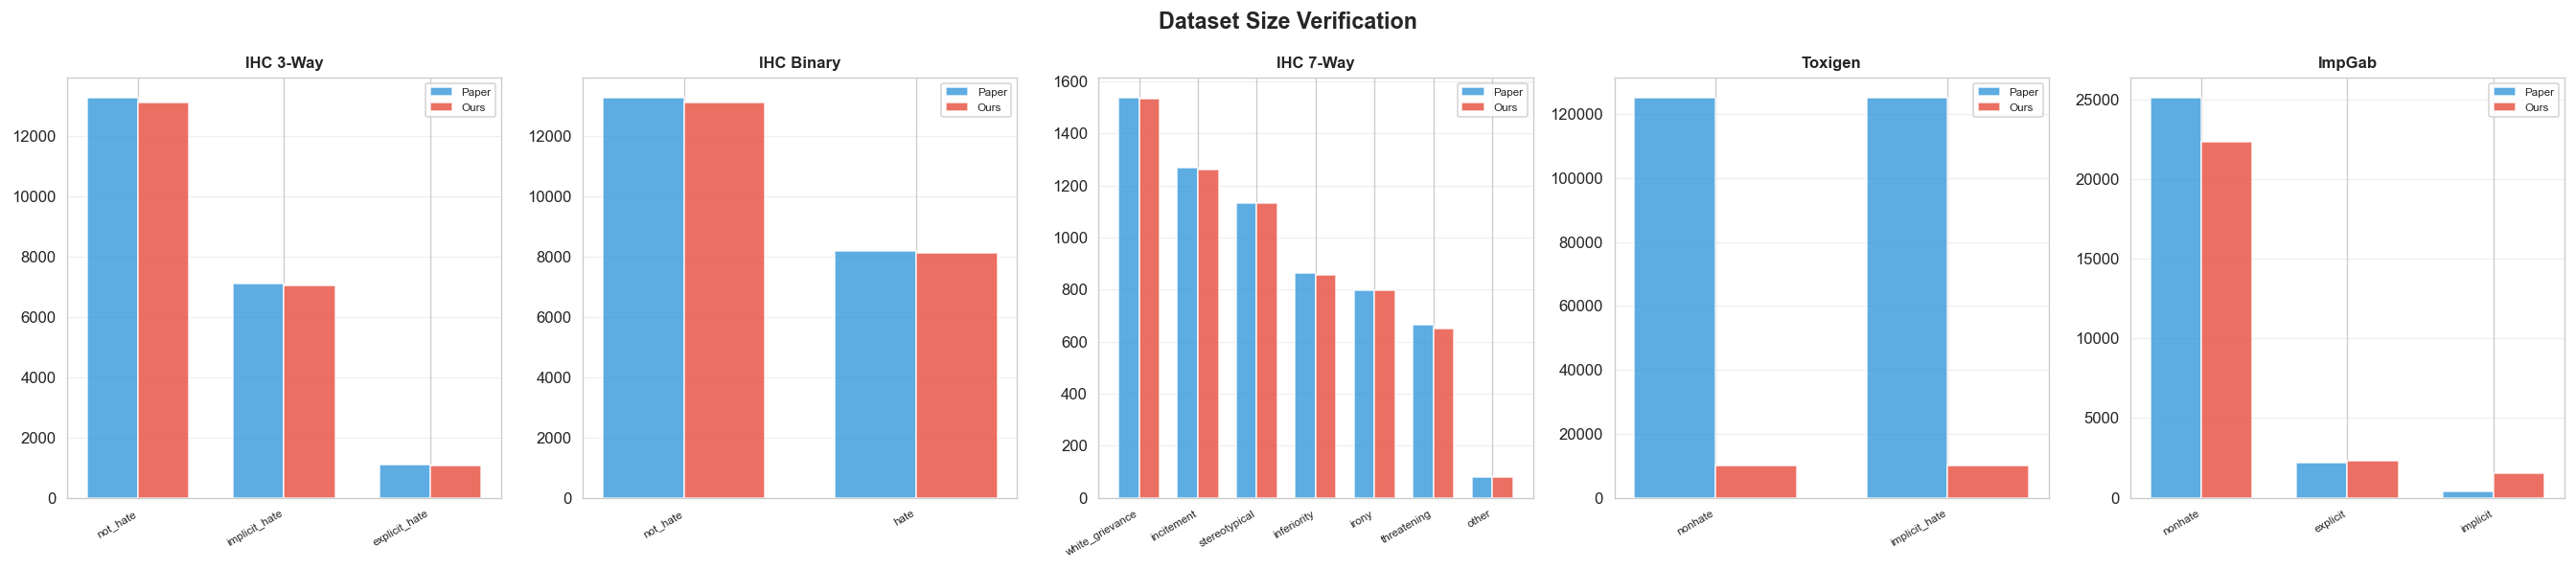

Saved fig1


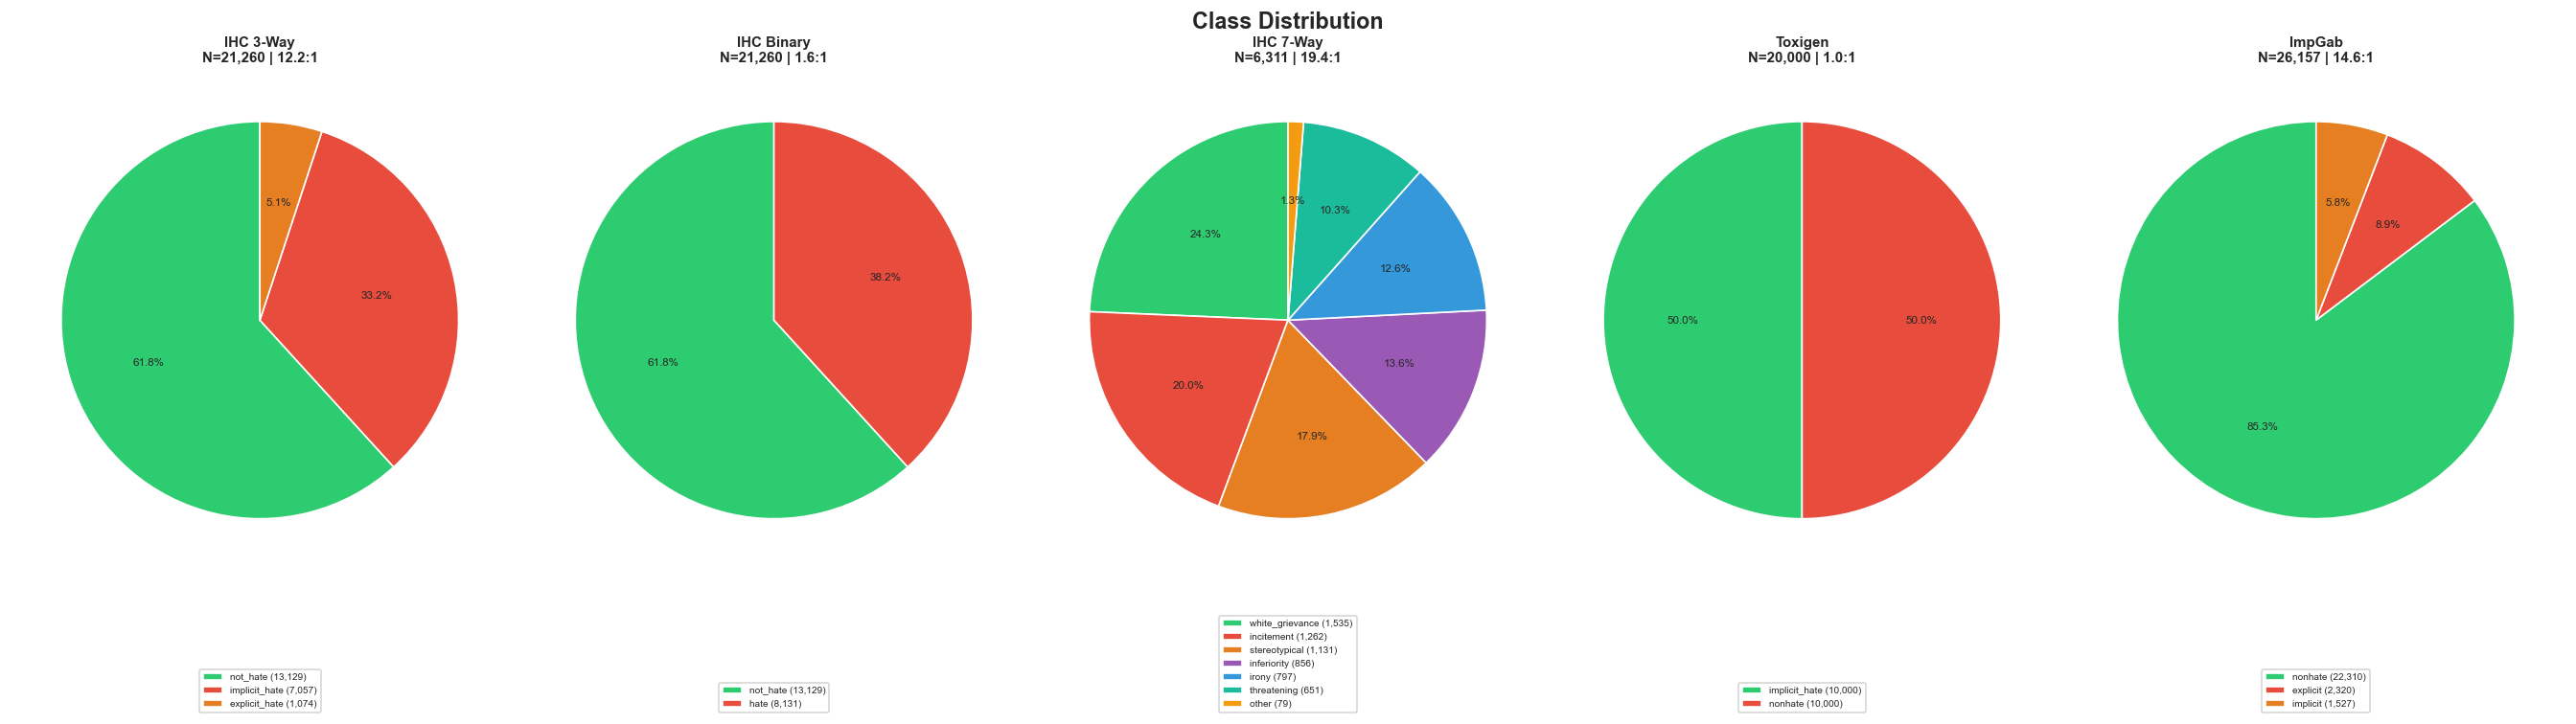

Saved fig2


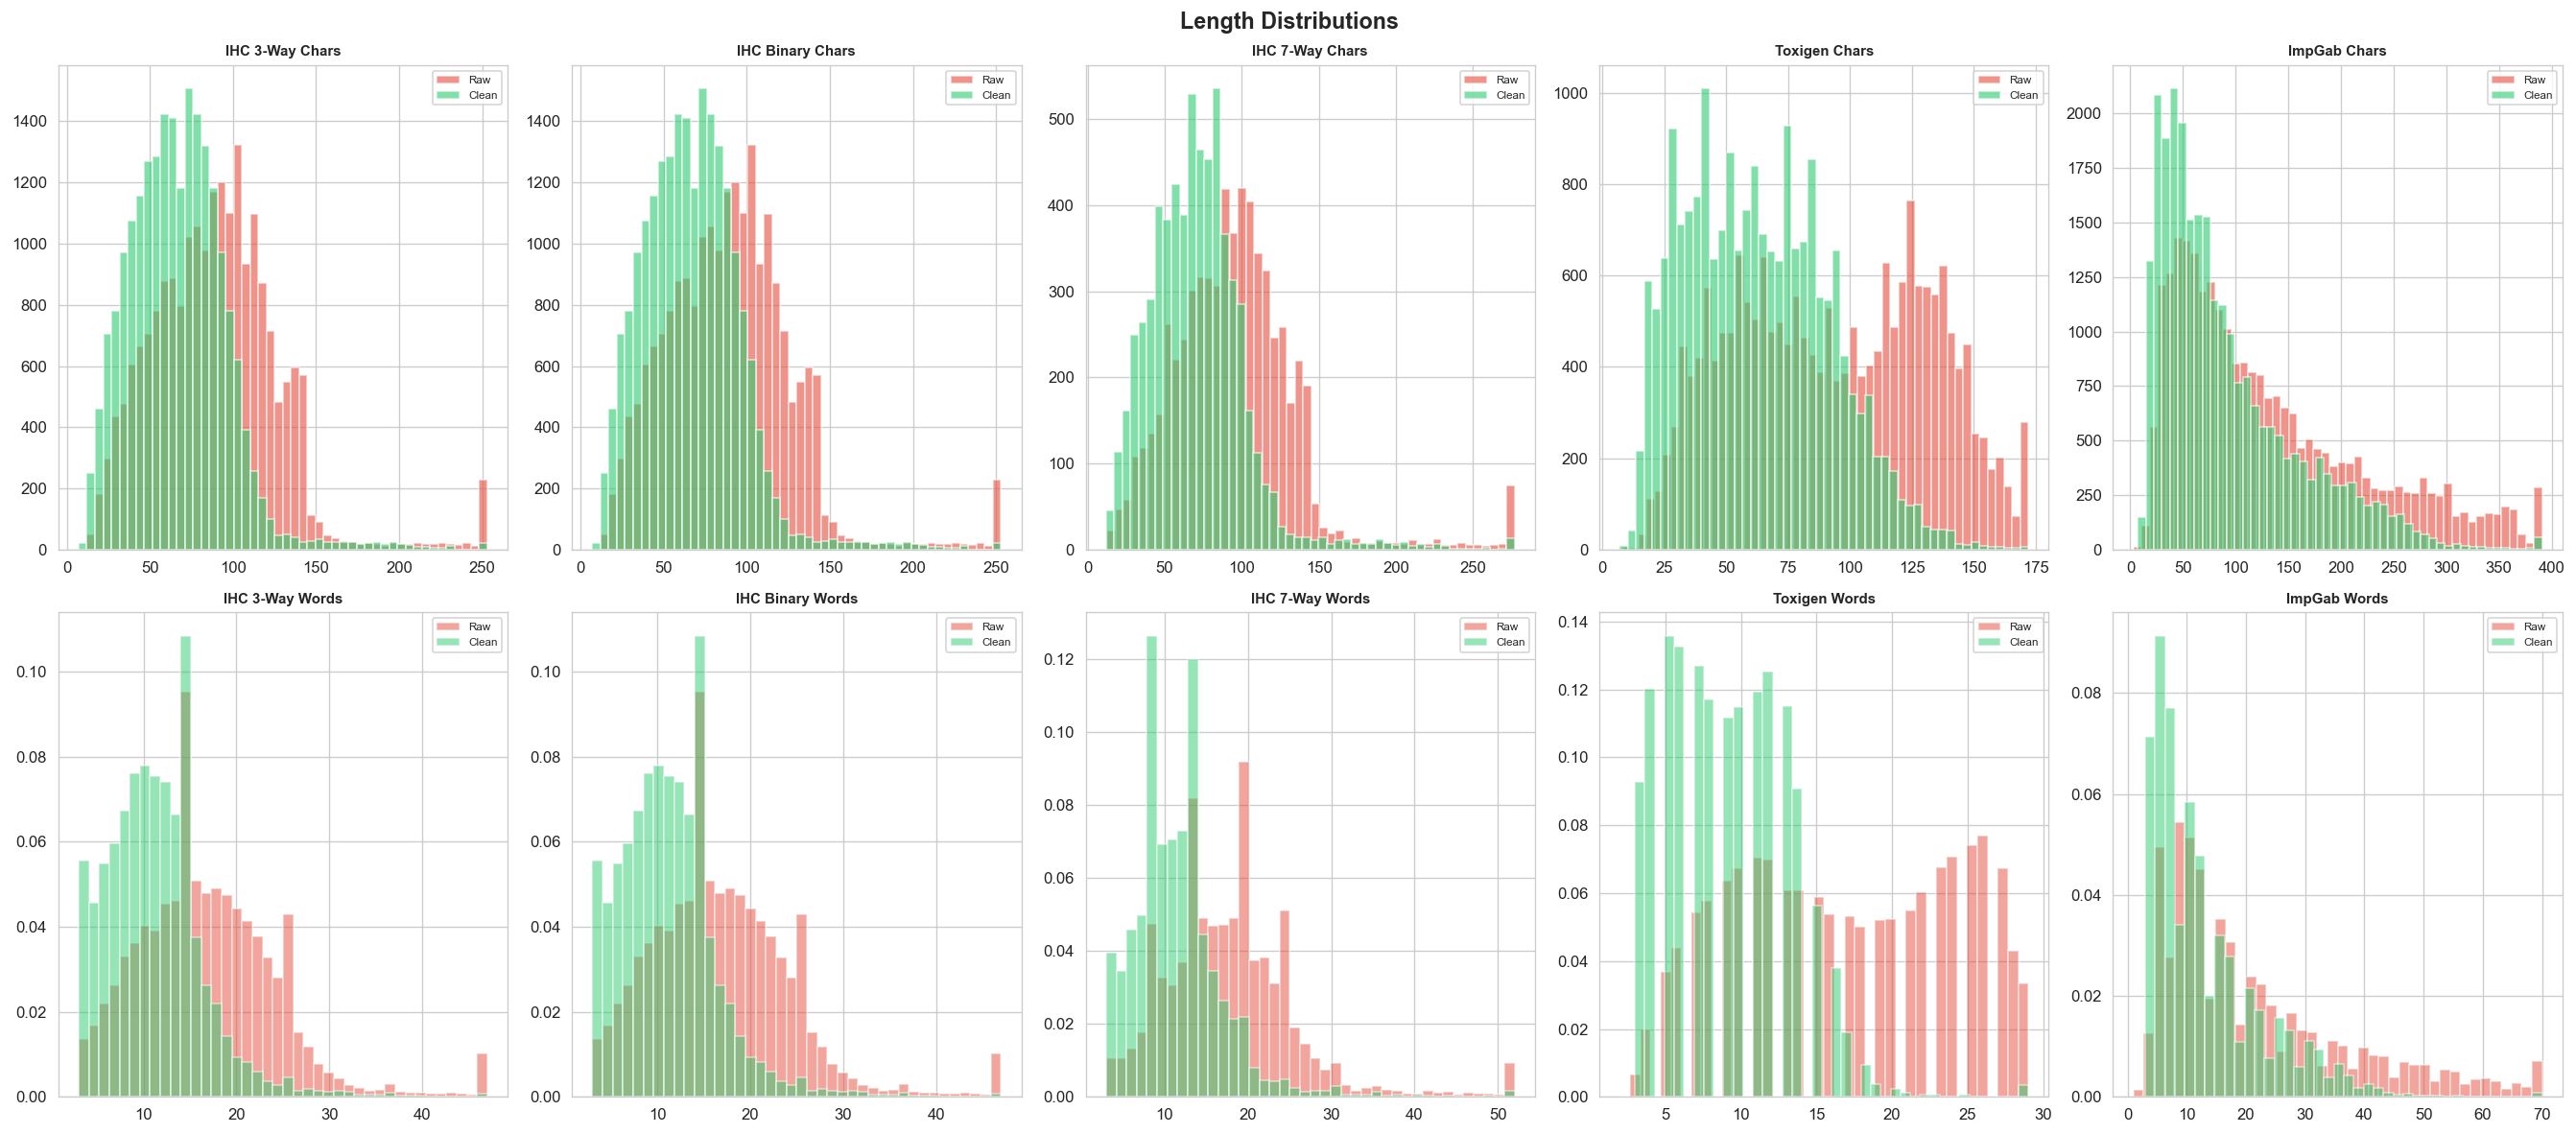

Saved fig3


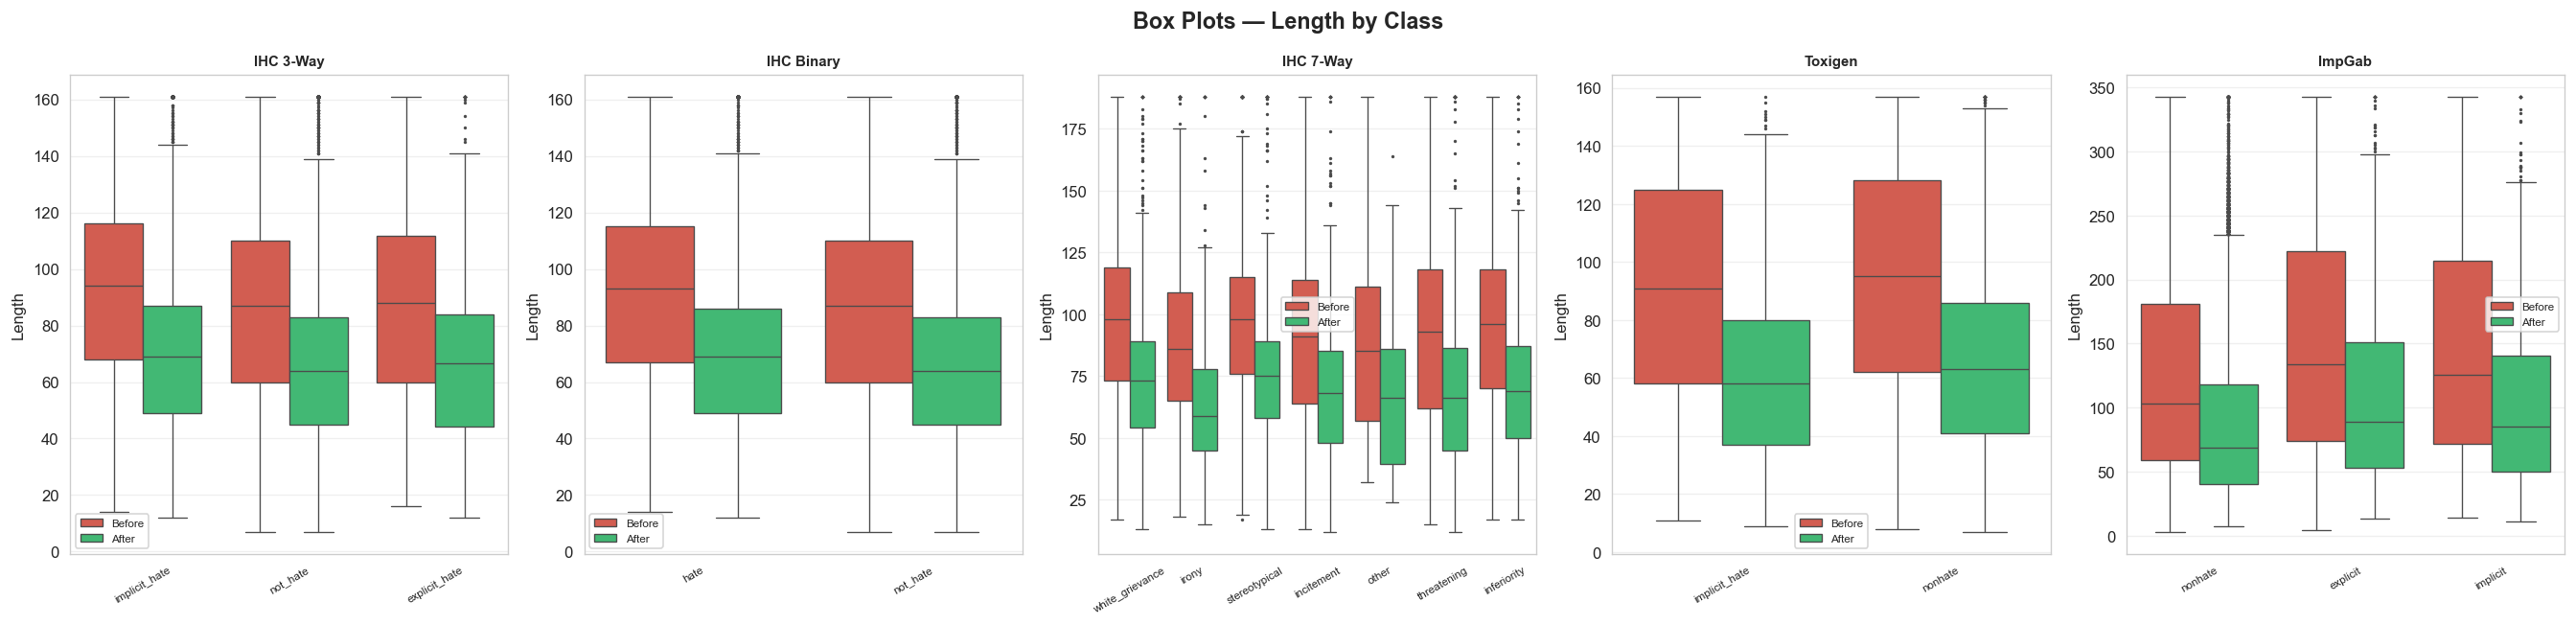

Saved fig4


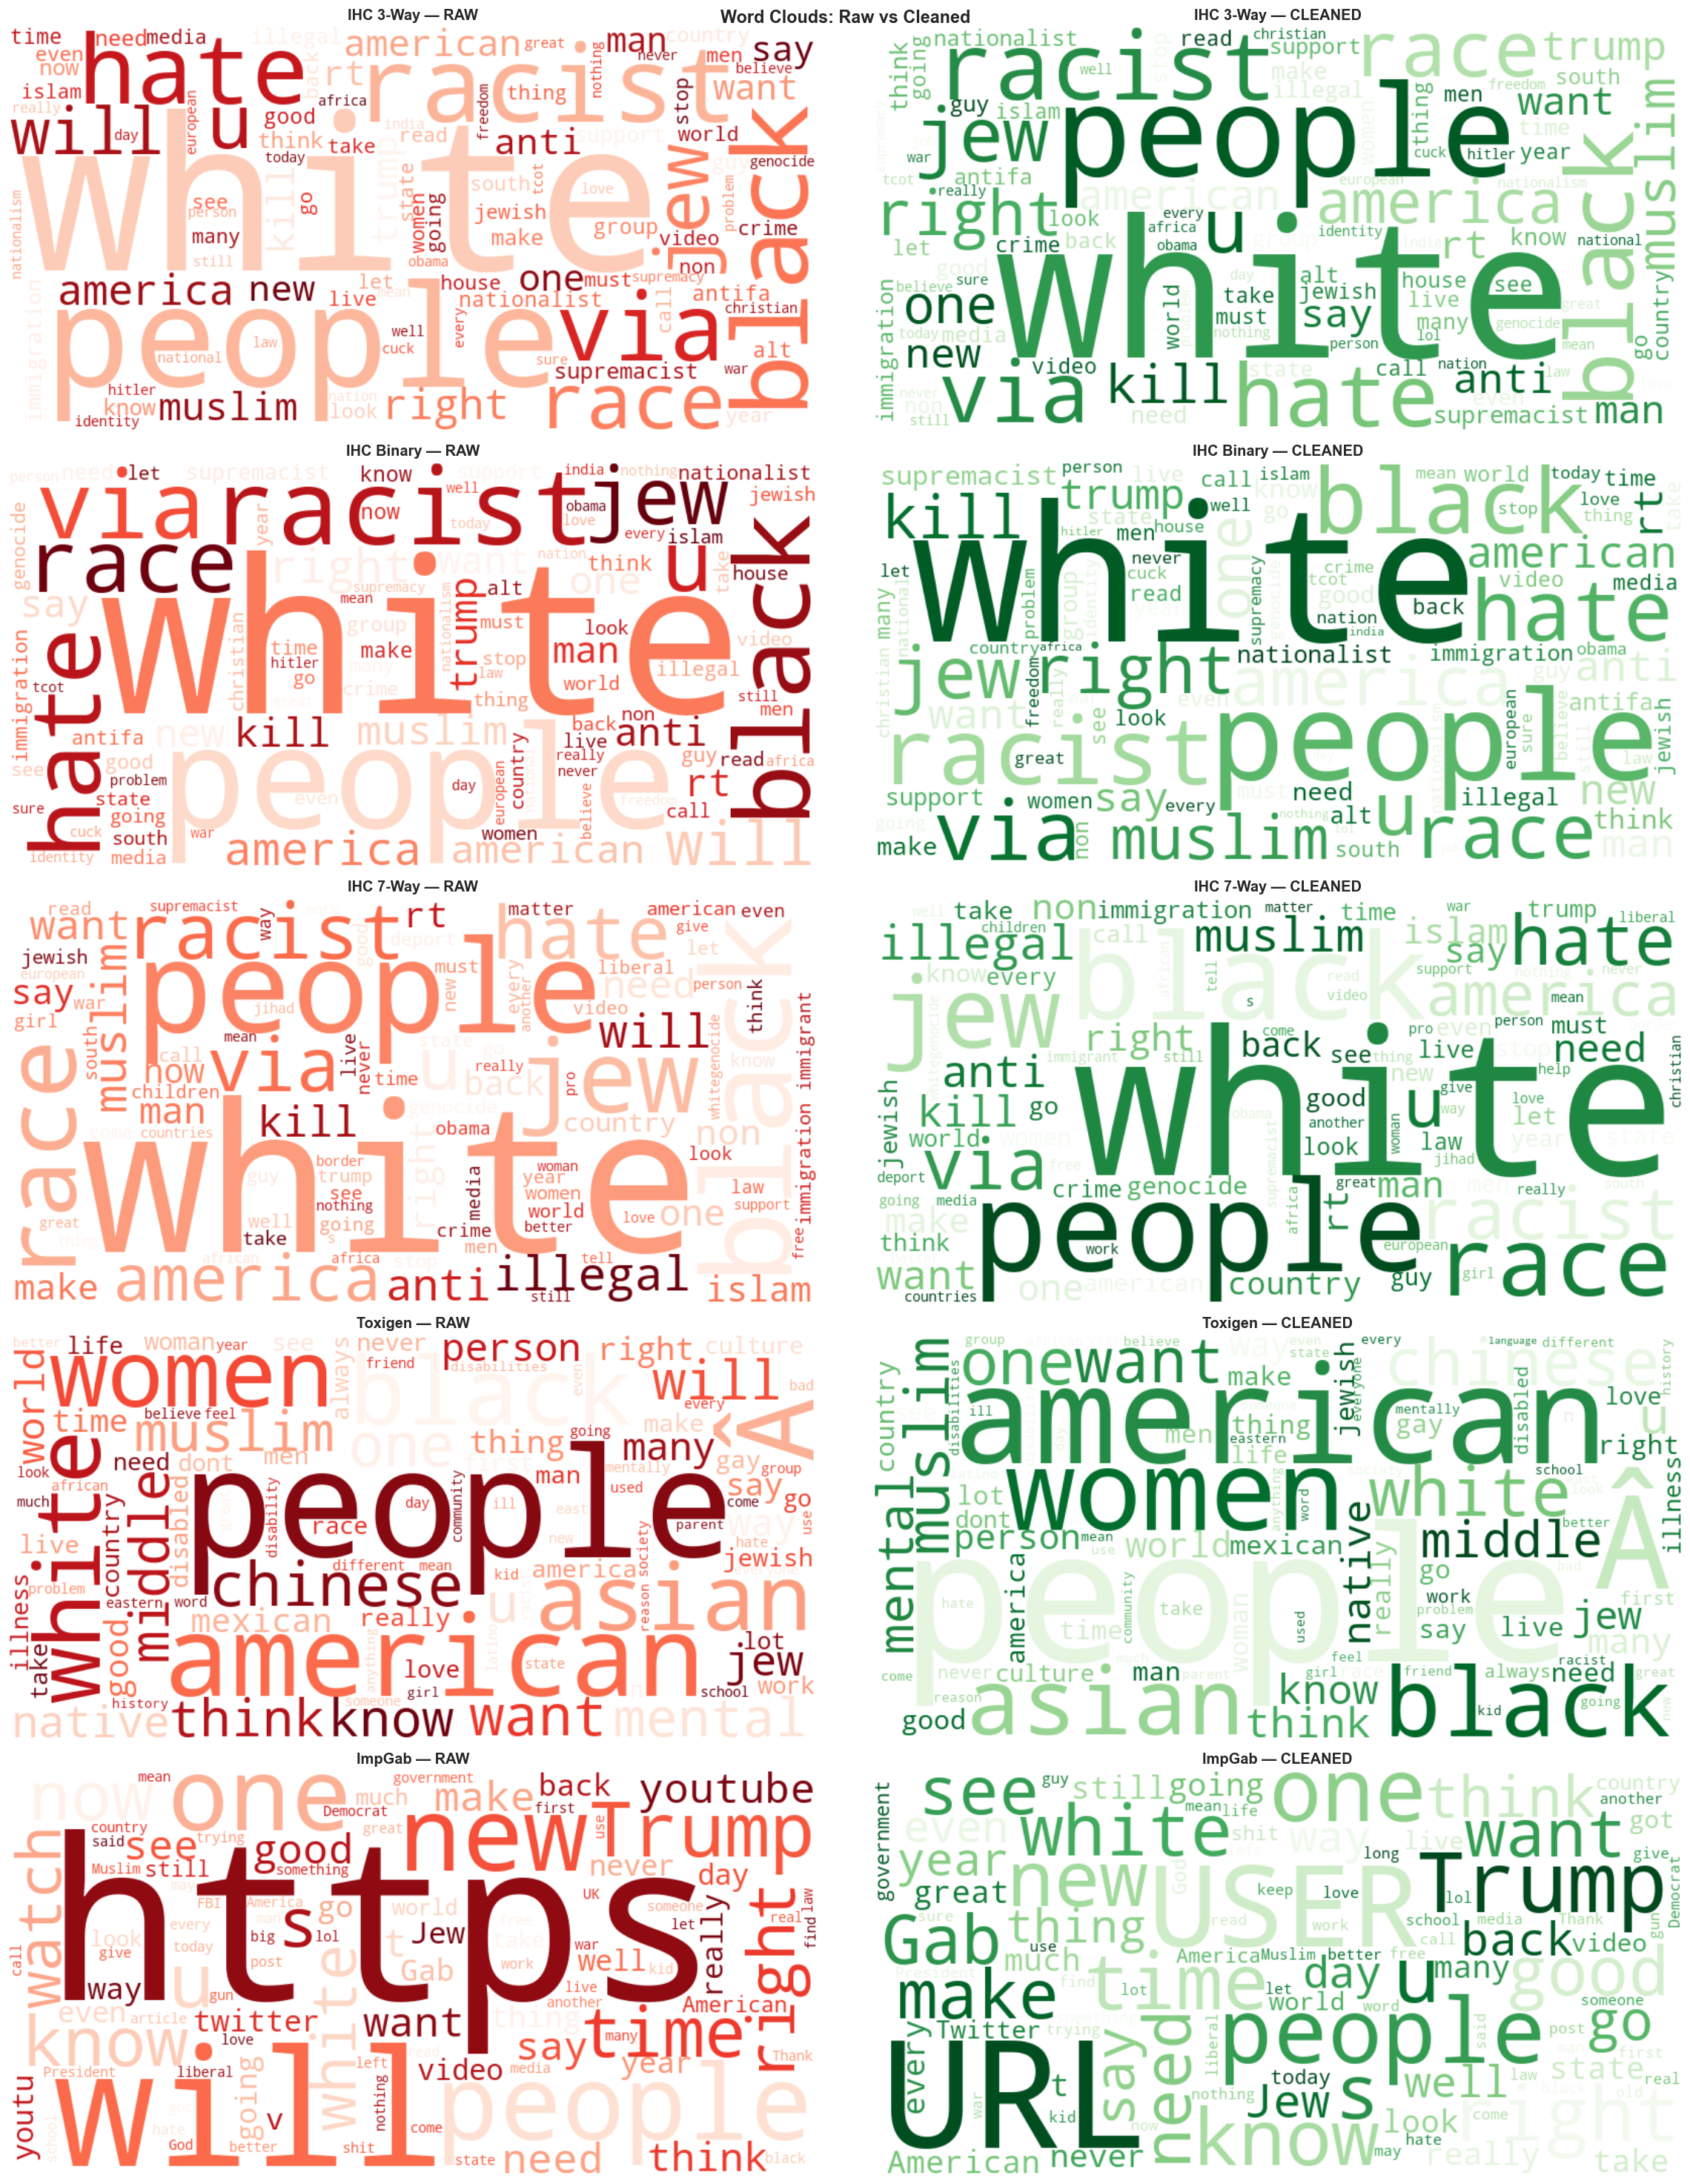

Saved fig5
Saved: results/preprocessing_summary.csv


In [10]:
PALETTE = ['#2ecc71','#e74c3c','#e67e22','#9b59b6','#3498db','#1abc9c','#f39c12','#95a5a6']
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 10, 'figure.dpi': 120})

for name, info in ALL_DATASETS.items():
    df = info['df']
    df['has_url']     = df['raw_text'].astype(str).str.contains(r'http\S+|www\S+', regex=True)
    df['has_mention'] = df['raw_text'].astype(str).str.contains(r'@\w+', regex=True)
    df['has_hashtag'] = df['raw_text'].astype(str).str.contains(r'#\w+', regex=True)
    df['char_diff']   = df['raw_char_len'] - df['clean_char_len']

n_ds = len(ALL_DATASETS)

fig, axes = plt.subplots(1, n_ds, figsize=(n_ds*4.5, 5))
fig.suptitle('Dataset Size Verification', fontsize=14, fontweight='bold')
for idx, (name, info) in enumerate(ALL_DATASETS.items()):
    ax     = axes[idx]
    actual = info['df']['label'].value_counts()
    paper  = info['paper_counts']
    labels = list(paper.keys())
    x, w   = np.arange(len(labels)), 0.35
    ax.bar(x-w/2, [paper[l] for l in labels],       w, label='Paper', color='#3498db', alpha=0.8)
    ax.bar(x+w/2, [actual.get(l,0) for l in labels],w, label='Ours',  color='#e74c3c', alpha=0.8)
    ax.set_title(f'{name}', fontsize=10, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=7)
    ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig1_table1_verification.png', dpi=150, bbox_inches='tight')
plt.show(); print("Saved fig1")

fig, axes = plt.subplots(1, n_ds, figsize=(n_ds*4.5, 5.5))
fig.suptitle('Class Distribution', fontsize=14, fontweight='bold')
for idx, (name, info) in enumerate(ALL_DATASETS.items()):
    ax     = axes[idx]
    counts = info['df']['label'].value_counts()
    colors = [PALETTE[i%len(PALETTE)] for i in range(len(counts))]
    wedges, _, _ = ax.pie(counts.values, labels=None, autopct='%1.1f%%',
                          colors=colors, startangle=90, textprops={'fontsize':7})
    ax.legend(wedges, [f'{l} ({v:,})' for l,v in zip(counts.index, counts.values)],
              loc='lower center', bbox_to_anchor=(0.5,-0.3), fontsize=6)
    ratio = counts.max()/max(counts.min(),1)
    ax.set_title(f'{name}\nN={len(info["df"]):,} | {ratio:.1f}:1', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig2_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show(); print("Saved fig2")

fig, axes = plt.subplots(2, n_ds, figsize=(n_ds*4.5, 10))
fig.suptitle('Length Distributions', fontsize=14, fontweight='bold')
for idx, (name, info) in enumerate(ALL_DATASETS.items()):
    df = info['df']
    mc = int(min(df['raw_char_len'].quantile(0.99),500))
    mw = int(min(df['raw_word_count'].quantile(0.99),80))
    axes[0][idx].hist(df['raw_char_len'].clip(0,mc),  bins=50,alpha=0.6,color='#e74c3c',label='Raw')
    axes[0][idx].hist(df['clean_char_len'].clip(0,mc),bins=50,alpha=0.6,color='#2ecc71',label='Clean')
    axes[0][idx].set_title(f'{name} Chars',fontsize=9,fontweight='bold')
    axes[0][idx].legend(fontsize=7)
    axes[1][idx].hist(df['raw_word_count'].clip(0,mw),  bins=40,alpha=0.5,color='#e74c3c',label='Raw',density=True)
    axes[1][idx].hist(df['clean_word_count'].clip(0,mw),bins=40,alpha=0.5,color='#2ecc71',label='Clean',density=True)
    axes[1][idx].set_title(f'{name} Words',fontsize=9,fontweight='bold')
    axes[1][idx].legend(fontsize=7)
plt.tight_layout()
plt.savefig('figures/fig3_length_distributions.png', dpi=150, bbox_inches='tight')
plt.show(); print("Saved fig3")

fig, axes = plt.subplots(1, n_ds, figsize=(n_ds*4.5, 5.5))
fig.suptitle('Box Plots — Length by Class', fontsize=14, fontweight='bold')
for idx, (name, info) in enumerate(ALL_DATASETS.items()):
    ax   = axes[idx]
    df   = info['df']
    melt = pd.melt(df, id_vars=['label'],
                   value_vars=['raw_char_len','clean_char_len'],
                   var_name='Stage', value_name='Length')
    melt['Stage'] = melt['Stage'].map({'raw_char_len':'Before','clean_char_len':'After'})
    melt['Length']= melt['Length'].clip(0, melt['Length'].quantile(0.98))
    sns.boxplot(data=melt, x='label', y='Length', hue='Stage',
                palette={'Before':'#e74c3c','After':'#2ecc71'},
                ax=ax, fliersize=1, linewidth=0.8)
    ax.set_title(f'{name}',fontsize=9,fontweight='bold')
    ax.set_xlabel(''); ax.tick_params(axis='x',rotation=30,labelsize=7)
    ax.legend(fontsize=7); ax.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig4_boxplots.png', dpi=150, bbox_inches='tight')
plt.show(); print("Saved fig4")

if HAS_WORDCLOUD:
    fig, axes = plt.subplots(n_ds, 2, figsize=(20, 5*n_ds))
    fig.suptitle('Word Clouds: Raw vs Cleaned', fontsize=14, fontweight='bold')
    for idx, (name, info) in enumerate(ALL_DATASETS.items()):
        sample = info['df'].sample(min(5000,len(info['df'])),random_state=42)
        for col_i, (txt_col, cm, lbl) in enumerate([
            ('raw_text','Reds','RAW'), ('clean_text','Greens','CLEANED')]):
            wc = WordCloud(width=800,height=400,background_color='white',
                           max_words=100,colormap=cm,collocations=False
                           ).generate(' '.join(sample[txt_col].astype(str).tolist()))
            axes[idx][col_i].imshow(wc,interpolation='bilinear')
            axes[idx][col_i].set_title(f'{name} — {lbl}',fontsize=12,fontweight='bold')
            axes[idx][col_i].axis('off')
    plt.tight_layout()
    plt.savefig('figures/fig5_wordclouds.png', dpi=150, bbox_inches='tight')
    plt.show(); print("Saved fig5")

summary_rows = []
for name, info in ALL_DATASETS.items():
    df = info['df']
    summary_rows.append({
        'Dataset': name, 'Samples': len(df),
        'Classes': len(df['label'].unique()),
        'Imbalance': f"{df['label'].value_counts().max()/max(df['label'].value_counts().min(),1):.1f}:1",
        'Raw_Mean_Chars': f"{df['raw_char_len'].mean():.0f}",
        'Clean_Mean_Chars': f"{df['clean_char_len'].mean():.0f}",
    })
pd.DataFrame(summary_rows).to_csv('results/preprocessing_summary.csv', index=False)
print("Saved: results/preprocessing_summary.csv")

# Cell 9.5: Emoji Visualizations

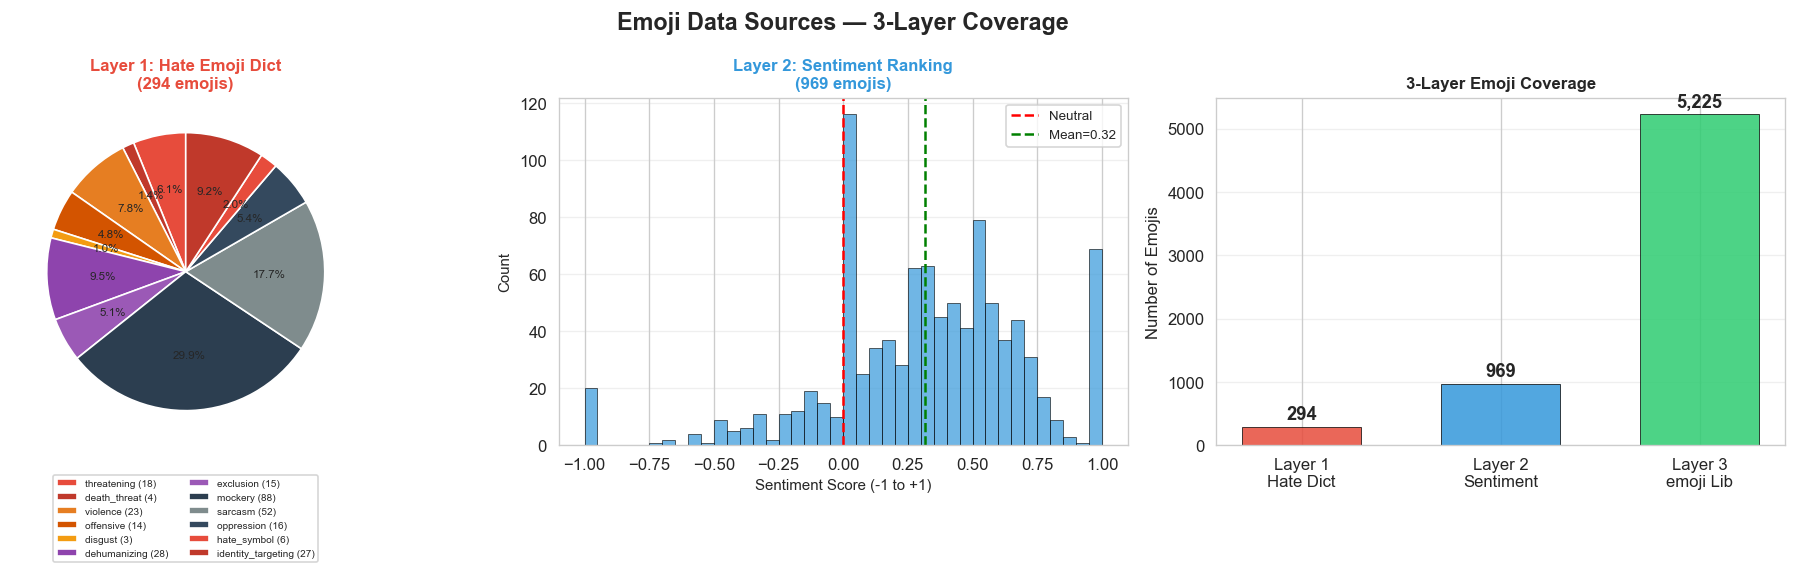

Saved figE1


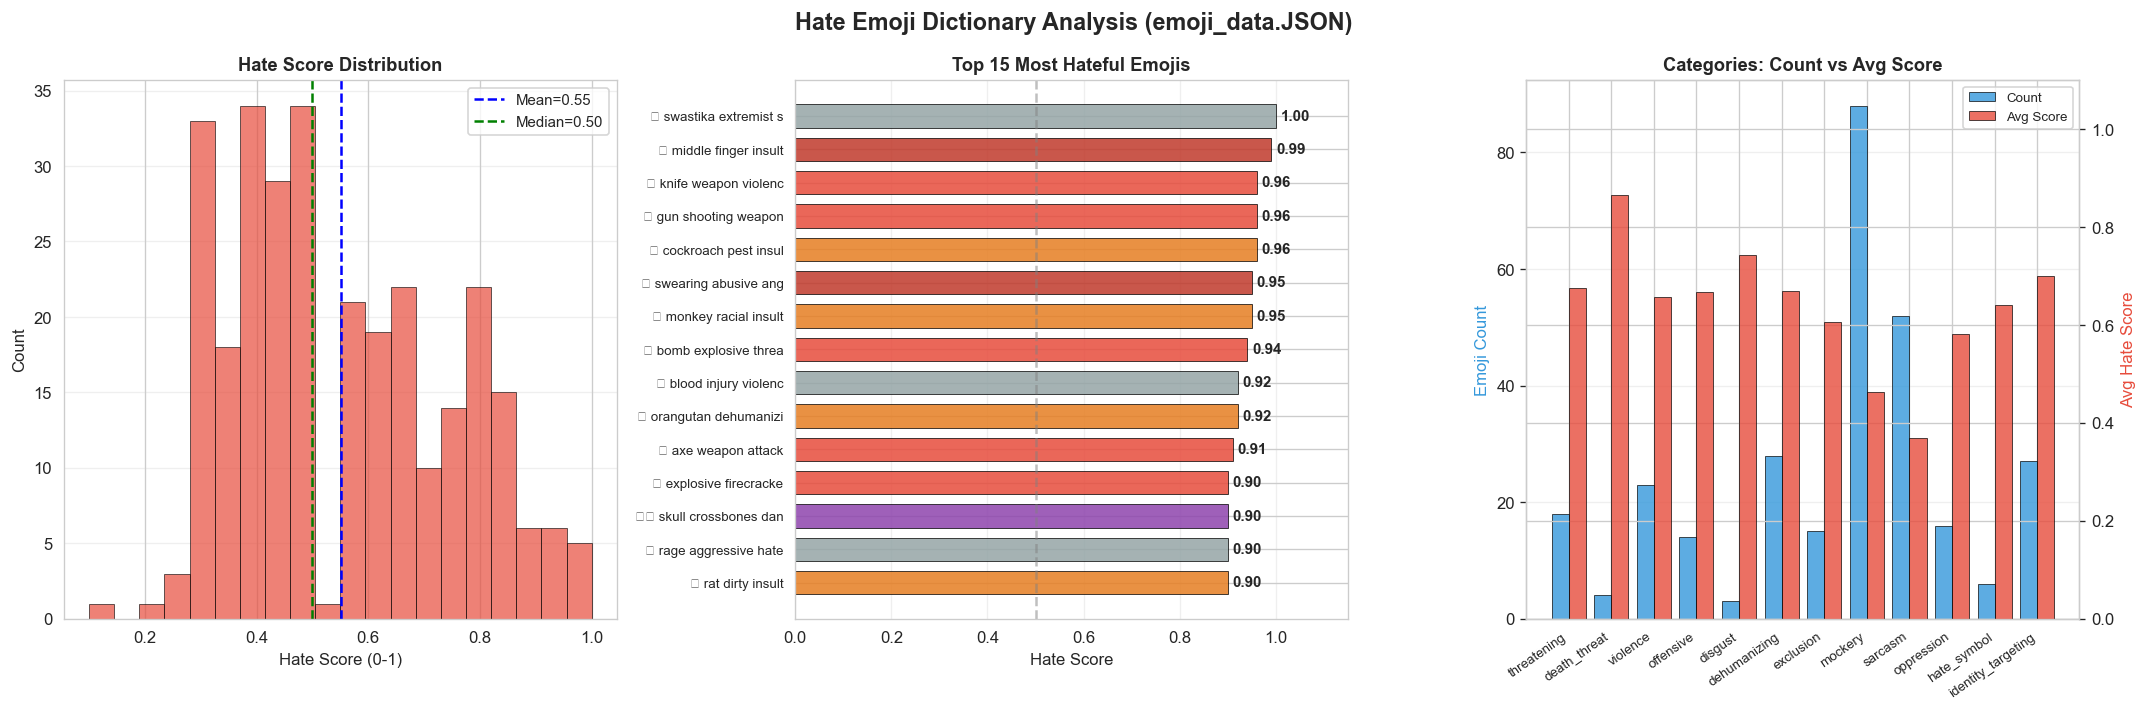

Saved figE2


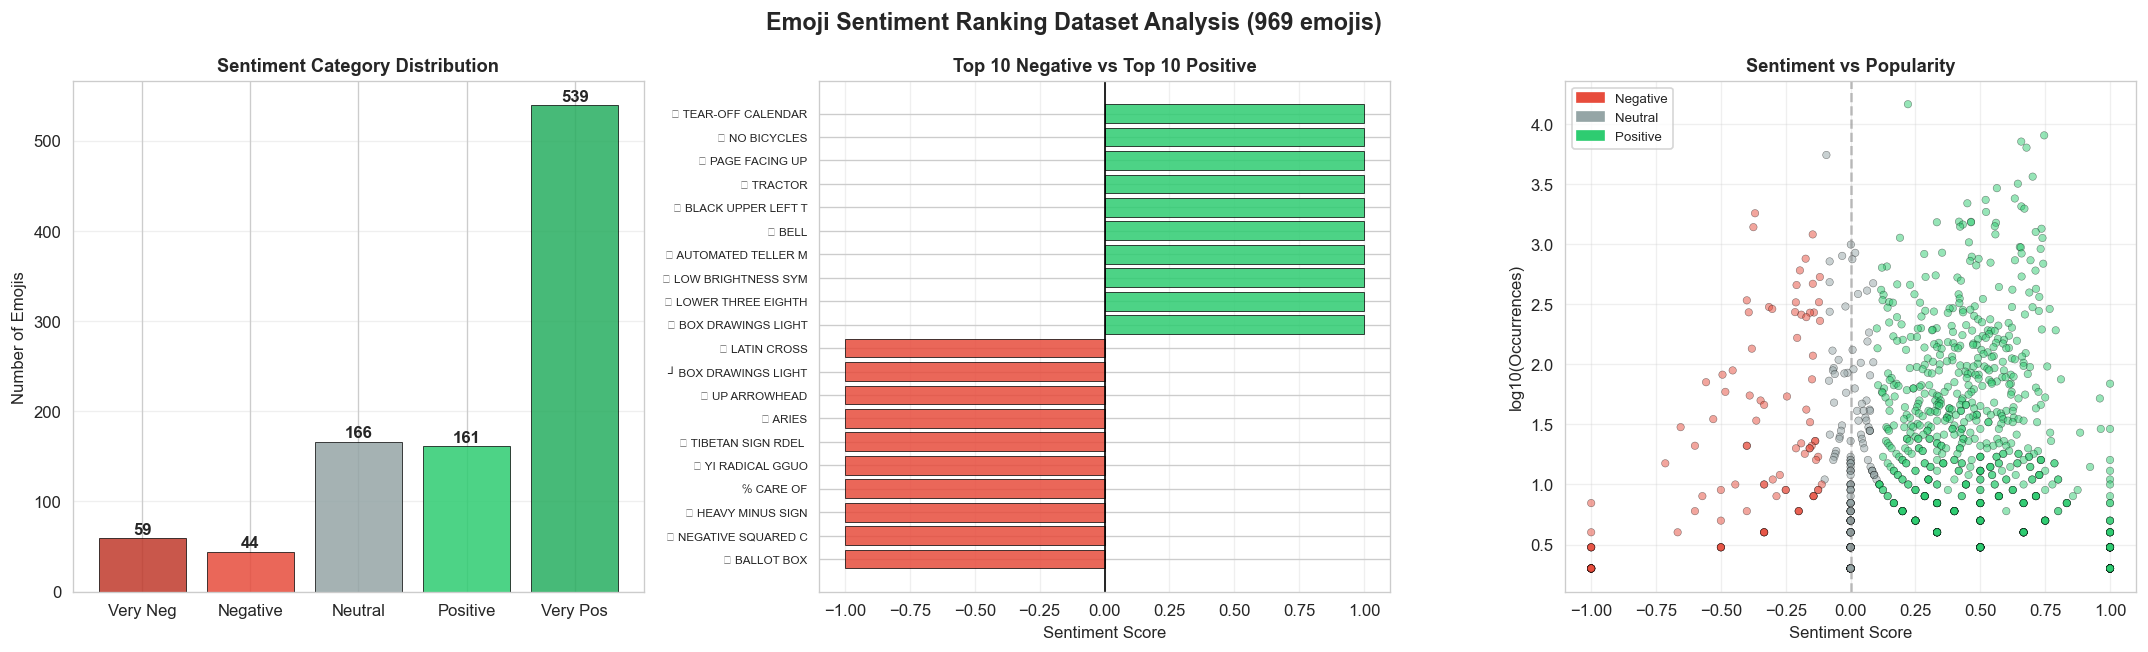

Saved figE3


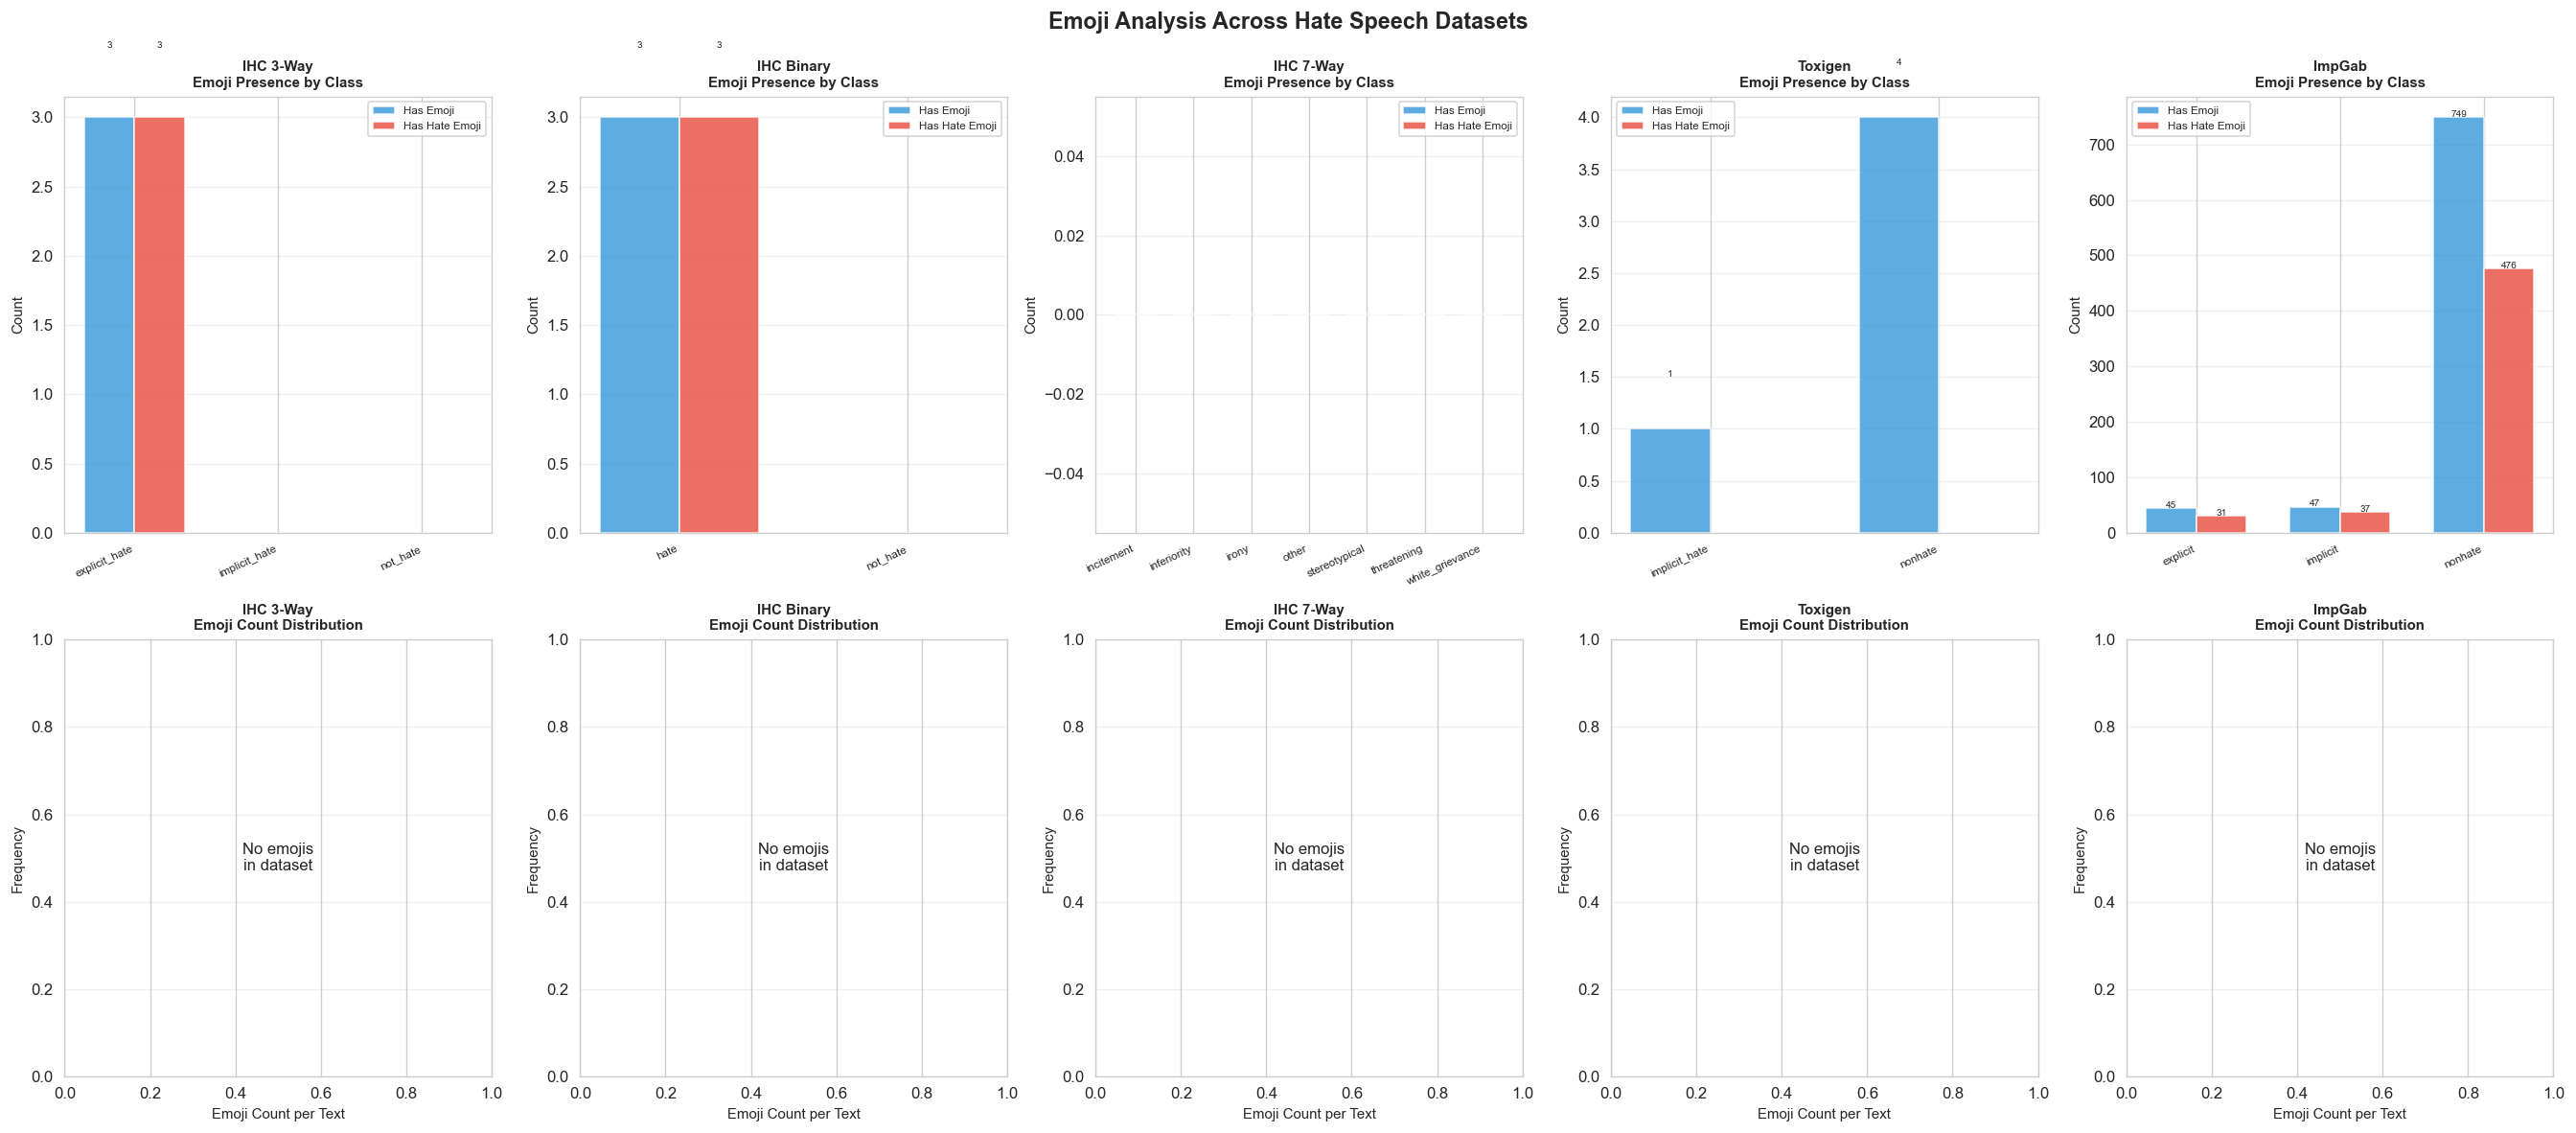

Saved figE4
Saved: results/emoji_dataset_statistics.csv
   Dataset  Samples  With_Emojis Emoji_Pct  With_Hate_Emojis Hate_Emoji_Pct  Total_Emojis  Total_Hate_Emojis
 IHC 3-Way    21260            3      0.0%                 3           0.0%             7                  6
IHC Binary    21260            3      0.0%                 3           0.0%             7                  6
 IHC 7-Way     6311            0      0.0%                 0           0.0%             0                  0
   Toxigen    20000            5      0.0%                 0           0.0%             7                  0
    ImpGab    26157          841      3.2%               544           2.1%          1839               1134


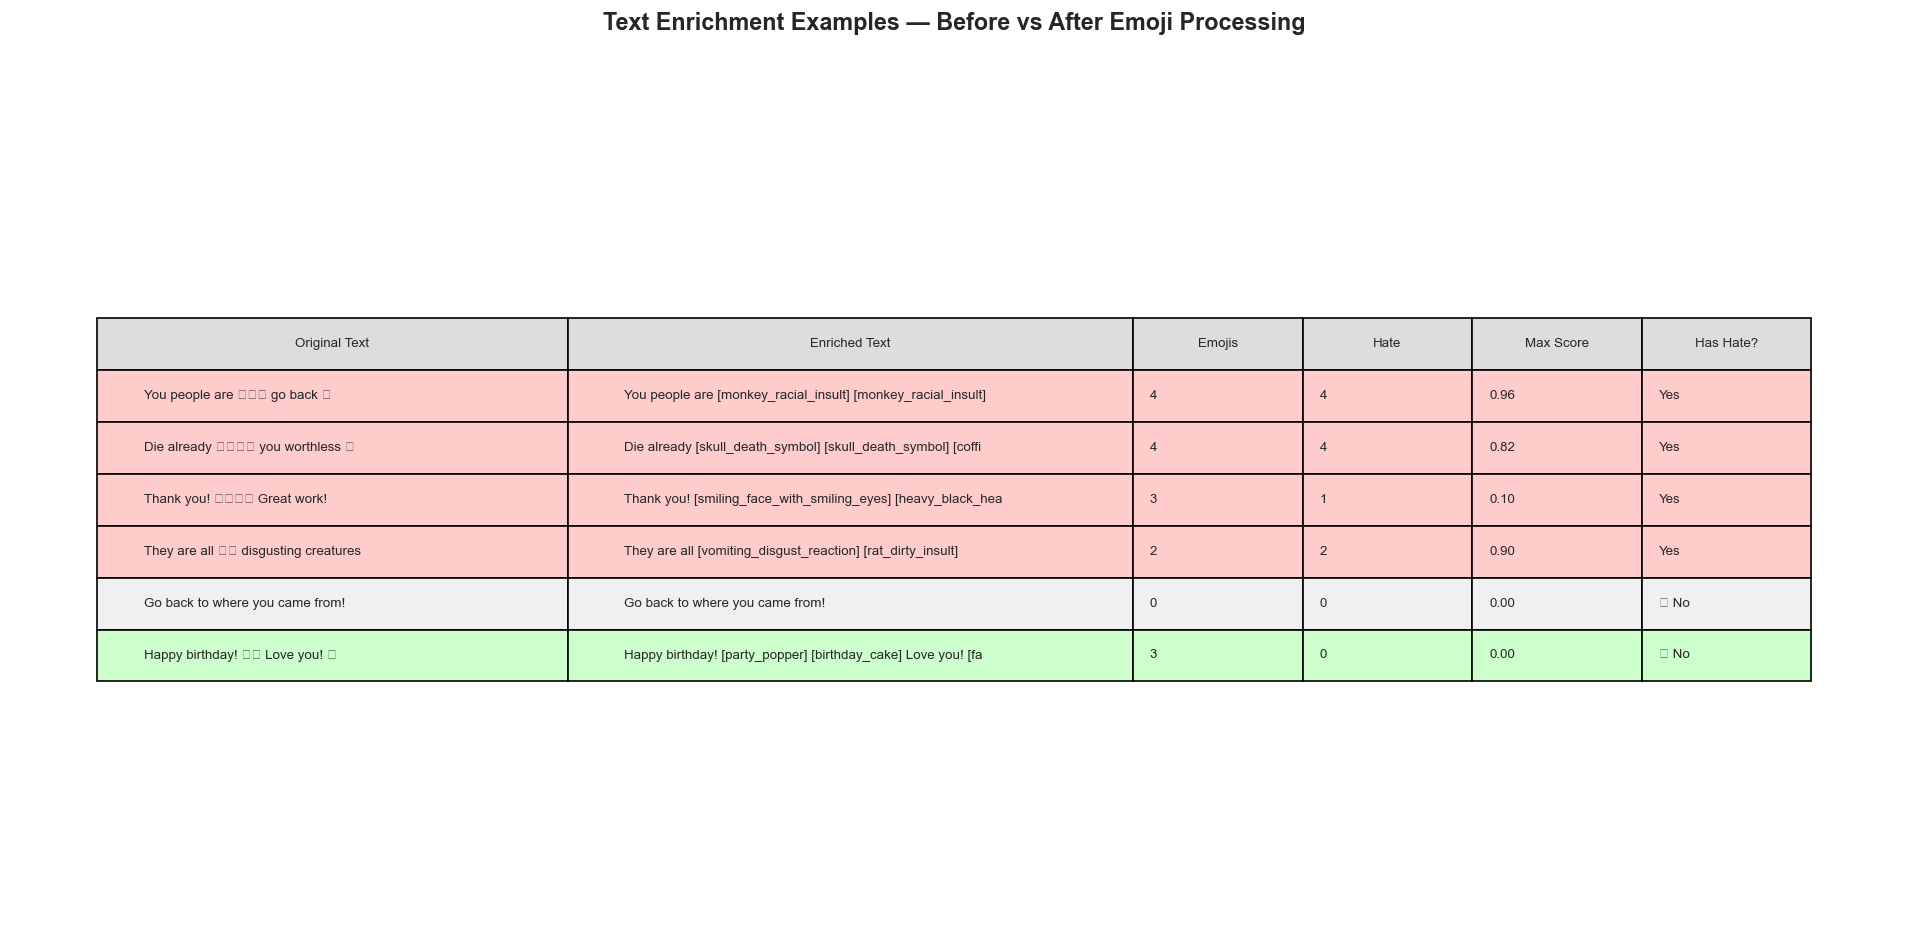

Saved figE5


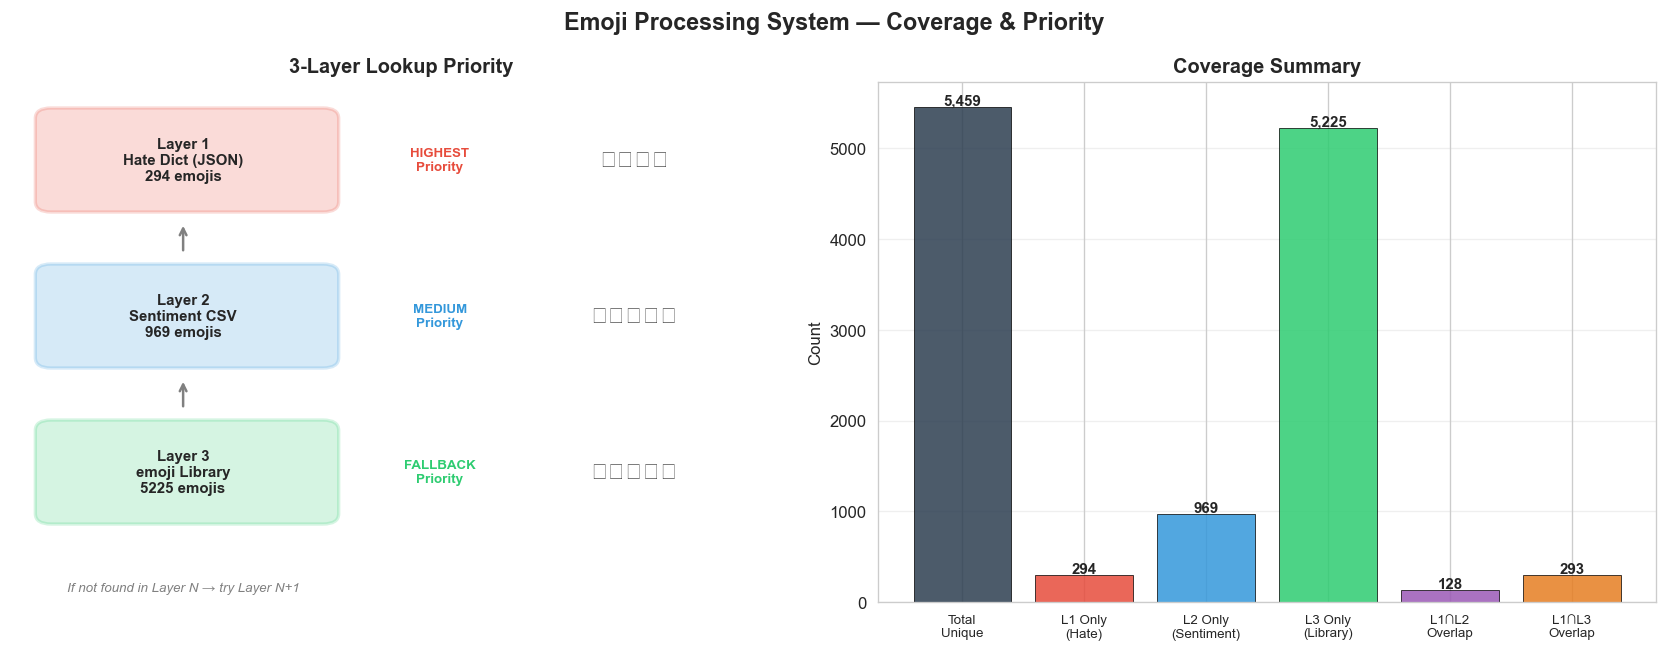

Saved figE6


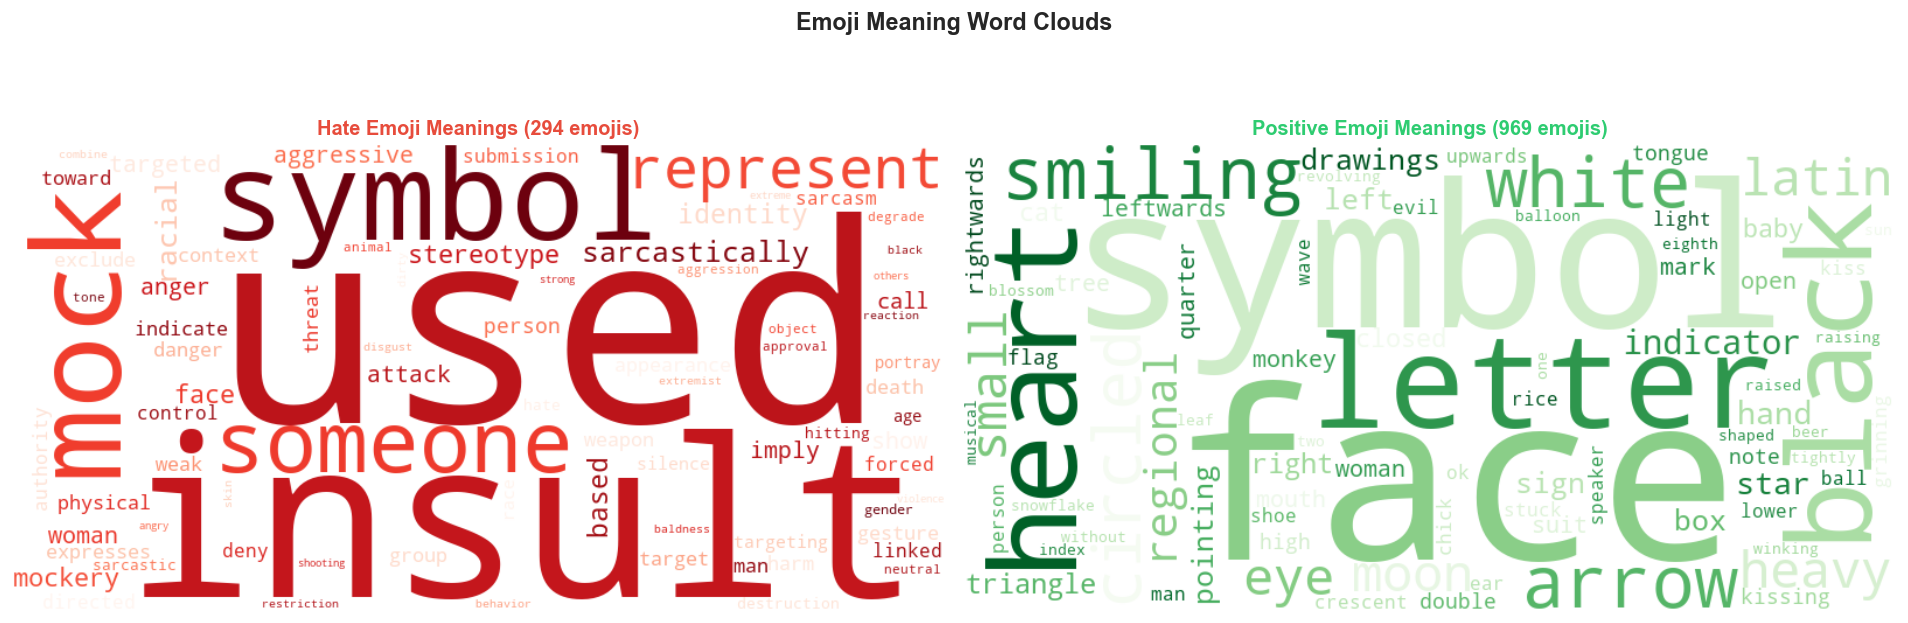

Saved figE7

EMOJI VISUALIZATION SUMMARY
  Layer_1_Hate_Dict        : 294
  Layer_2_Sentiment        : 969
  Layer_3_Library          : 5225
  Hate_Categories          : 12
  Avg_Hate_Score           : 0.551
  Max_Hate_Score           : 1.000

Figures saved: figE1 through figE7
Stats saved: results/emoji_dataset_statistics.csv


In [11]:
import matplotlib.patches as mpatches
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Emoji Data Sources — 3-Layer Coverage', fontsize=14, fontweight='bold')


categories_count = {}
for em, info in MANUAL_HATE_EMOJI_DICT.items():
    cat = info.get('category', 'unknown')
    categories_count[cat] = categories_count.get(cat, 0) + 1

if categories_count:
    cats = list(categories_count.keys())
    vals = list(categories_count.values())
    colors_l1 = ['#e74c3c', '#c0392b', '#e67e22', '#d35400', '#f39c12',
                 '#8e44ad', '#9b59b6', '#2c3e50', '#7f8c8d', '#34495e']
    ax1 = axes[0]
    wedges, texts, autotexts = ax1.pie(
        vals, labels=None, autopct='%1.1f%%',
        colors=[colors_l1[i % len(colors_l1)] for i in range(len(cats))],
        startangle=90, textprops={'fontsize': 7})
    ax1.legend(wedges, [f'{c} ({v})' for c, v in zip(cats, vals)],
               loc='lower center', bbox_to_anchor=(0.5, -0.35), fontsize=6, ncol=2)
    ax1.set_title(f'Layer 1: Hate Emoji Dict\n({len(MANUAL_HATE_EMOJI_DICT)} emojis)',
                  fontsize=10, fontweight='bold', color='#e74c3c')
else:
    axes[0].text(0.5, 0.5, 'No hate emoji\ndict loaded', ha='center', va='center', fontsize=12)
    axes[0].set_title('Layer 1: Hate Emoji Dict\n(0 emojis)', fontsize=10, fontweight='bold')

if EMOJI_SENTIMENT_DICT:
    sentiments = []
    for em, info in EMOJI_SENTIMENT_DICT.items():
        total = info['Negative'] + info['Neutral'] + info['Positive']
        if total > 0:
            sent = (info['Positive'] - info['Negative']) / total
            sentiments.append(sent)

    ax2 = axes[1]
    ax2.hist(sentiments, bins=40, color='#3498db', alpha=0.7, edgecolor='black', linewidth=0.5)
    ax2.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Neutral')
    ax2.axvline(x=np.mean(sentiments), color='green', linestyle='--',
                linewidth=1.5, label=f'Mean={np.mean(sentiments):.2f}')
    ax2.set_xlabel('Sentiment Score (-1 to +1)', fontsize=9)
    ax2.set_ylabel('Count', fontsize=9)
    ax2.set_title(f'Layer 2: Sentiment Ranking\n({len(EMOJI_SENTIMENT_DICT)} emojis)',
                  fontsize=10, fontweight='bold', color='#3498db')
    ax2.legend(fontsize=8)
    ax2.grid(axis='y', alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'Sentiment ranking\nnot loaded', ha='center', va='center', fontsize=12)
    axes[1].set_title('Layer 2: Sentiment Ranking\n(0 emojis)', fontsize=10, fontweight='bold')

ax3 = axes[2]
layer_names = ['Layer 1\nHate Dict', 'Layer 2\nSentiment', 'Layer 3\nemoji Lib']
layer_counts = [
    len(MANUAL_HATE_EMOJI_DICT),
    len(EMOJI_SENTIMENT_DICT),
    len(emoji_lib.EMOJI_DATA) if HAS_EMOJI else 0
]
bar_colors = ['#e74c3c', '#3498db', '#2ecc71']
bars = ax3.bar(layer_names, layer_counts, color=bar_colors, alpha=0.85,
               edgecolor='black', linewidth=0.5, width=0.6)
for bar, val in zip(bars, layer_counts):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
             f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax3.set_ylabel('Number of Emojis', fontsize=10)
ax3.set_title('3-Layer Emoji Coverage', fontsize=10, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/figE1_emoji_sources.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figE1")


if MANUAL_HATE_EMOJI_DICT:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Hate Emoji Dictionary Analysis (emoji_data.JSON)',
                 fontsize=14, fontweight='bold')

    scores = [info.get('hate_score', 0) for info in MANUAL_HATE_EMOJI_DICT.values()]
    ax_a = axes[0]
    ax_a.hist(scores, bins=20, color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=0.5)
    ax_a.axvline(x=np.mean(scores), color='blue', linestyle='--',
                 linewidth=1.5, label=f'Mean={np.mean(scores):.2f}')
    ax_a.axvline(x=np.median(scores), color='green', linestyle='--',
                 linewidth=1.5, label=f'Median={np.median(scores):.2f}')
    ax_a.set_xlabel('Hate Score (0-1)', fontsize=10)
    ax_a.set_ylabel('Count', fontsize=10)
    ax_a.set_title('Hate Score Distribution', fontsize=11, fontweight='bold')
    ax_a.legend(fontsize=9)
    ax_a.grid(axis='y', alpha=0.3)


    sorted_emojis = sorted(MANUAL_HATE_EMOJI_DICT.items(),
                           key=lambda x: x[1].get('hate_score', 0), reverse=True)
    top_n = min(15, len(sorted_emojis))
    top_emojis = sorted_emojis[:top_n]

    ax_b = axes[1]
    emoji_labels = [f"{em} {info.get('meaning', '?')[:20]}" for em, info in top_emojis]
    emoji_scores = [info.get('hate_score', 0) for _, info in top_emojis]
    emoji_colors = []
    for _, info in top_emojis:
        cat = info.get('category', '')
        if cat == 'threatening':
            emoji_colors.append('#e74c3c')
        elif cat == 'dehumanizing':
            emoji_colors.append('#e67e22')
        elif cat == 'death_threat':
            emoji_colors.append('#8e44ad')
        elif cat == 'offensive':
            emoji_colors.append('#c0392b')
        elif cat == 'disgust':
            emoji_colors.append('#d35400')
        else:
            emoji_colors.append('#95a5a6')

    bars = ax_b.barh(range(top_n), emoji_scores, color=emoji_colors,
                     alpha=0.85, edgecolor='black', linewidth=0.5, height=0.7)
    for bar, score in zip(bars, emoji_scores):
        ax_b.text(score + 0.01, bar.get_y() + bar.get_height() / 2,
                  f'{score:.2f}', va='center', fontsize=9, fontweight='bold')
    ax_b.set_yticks(range(top_n))
    ax_b.set_yticklabels(emoji_labels, fontsize=8)
    ax_b.set_xlim(0, 1.15)
    ax_b.set_xlabel('Hate Score', fontsize=10)
    ax_b.set_title(f'Top {top_n} Most Hateful Emojis', fontsize=11, fontweight='bold')
    ax_b.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
    ax_b.grid(axis='x', alpha=0.3)
    ax_b.invert_yaxis()


    ax_c = axes[2]
    cat_counts = {}
    cat_avg_scores = {}
    for em, info in MANUAL_HATE_EMOJI_DICT.items():
        cat = info.get('category', 'unknown')
        cat_counts[cat] = cat_counts.get(cat, 0) + 1
        cat_avg_scores.setdefault(cat, []).append(info.get('hate_score', 0))

    cat_names = list(cat_counts.keys())
    cat_values = list(cat_counts.values())
    cat_avgs = [np.mean(cat_avg_scores[c]) for c in cat_names]

    x_pos = np.arange(len(cat_names))
    bars1 = ax_c.bar(x_pos - 0.2, cat_values, 0.4, label='Count',
                     color='#3498db', alpha=0.8, edgecolor='black', linewidth=0.5)
    ax_c2 = ax_c.twinx()
    bars2 = ax_c2.bar(x_pos + 0.2, cat_avgs, 0.4, label='Avg Score',
                      color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.5)

    ax_c.set_xticks(x_pos)
    ax_c.set_xticklabels(cat_names, rotation=35, ha='right', fontsize=8)
    ax_c.set_ylabel('Emoji Count', fontsize=10, color='#3498db')
    ax_c2.set_ylabel('Avg Hate Score', fontsize=10, color='#e74c3c')
    ax_c2.set_ylim(0, 1.1)
    ax_c.set_title('Categories: Count vs Avg Score', fontsize=11, fontweight='bold')

    lines1, labels1 = ax_c.get_legend_handles_labels()
    lines2, labels2 = ax_c2.get_legend_handles_labels()
    ax_c.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')
    ax_c.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('figures/figE2_hate_emoji_dict.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved figE2")

if EMOJI_SENTIMENT_DICT:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    fig.suptitle('Emoji Sentiment Ranking Dataset Analysis (969 emojis)',
                 fontsize=14, fontweight='bold')

    all_emojis_data = []
    for em, info in EMOJI_SENTIMENT_DICT.items():
        total = info['Negative'] + info['Neutral'] + info['Positive']
        if total > 0:
            all_emojis_data.append({
                'emoji': em,
                'neg_ratio': info['Negative'] / total,
                'neu_ratio': info['Neutral'] / total,
                'pos_ratio': info['Positive'] / total,
                'sentiment': (info['Positive'] - info['Negative']) / total,
                'occurrences': info['Occurrences'],
                'name': info['Unicode_name'],
            })
    edf = pd.DataFrame(all_emojis_data)


    ax_a = axes[0]
    edf['sent_cat'] = pd.cut(edf['sentiment'],
                             bins=[-1.01, -0.3, -0.1, 0.1, 0.3, 1.01],
                             labels=['Very Neg', 'Negative', 'Neutral', 'Positive', 'Very Pos'])
    sent_counts = edf['sent_cat'].value_counts().reindex(
        ['Very Neg', 'Negative', 'Neutral', 'Positive', 'Very Pos'])
    sent_colors = ['#c0392b', '#e74c3c', '#95a5a6', '#2ecc71', '#27ae60']
    bars = ax_a.bar(sent_counts.index, sent_counts.values, color=sent_colors,
                    alpha=0.85, edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, sent_counts.values):
        ax_a.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                  str(val), ha='center', fontsize=10, fontweight='bold')
    ax_a.set_ylabel('Number of Emojis', fontsize=10)
    ax_a.set_title('Sentiment Category Distribution', fontsize=11, fontweight='bold')
    ax_a.grid(axis='y', alpha=0.3)


    ax_b = axes[1]
    top_neg = edf.nsmallest(10, 'sentiment')
    top_pos = edf.nlargest(10, 'sentiment')
    combined = pd.concat([top_neg, top_pos])

    labels_combined = [f"{row['emoji']} {row['name'][:18]}" for _, row in combined.iterrows()]
    scores_combined = combined['sentiment'].values
    colors_combined = ['#e74c3c' if s < 0 else '#2ecc71' for s in scores_combined]

    bars = ax_b.barh(range(len(labels_combined)), scores_combined,
                     color=colors_combined, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax_b.set_yticks(range(len(labels_combined)))
    ax_b.set_yticklabels(labels_combined, fontsize=7)
    ax_b.axvline(x=0, color='black', linewidth=1)
    ax_b.set_xlabel('Sentiment Score', fontsize=10)
    ax_b.set_title('Top 10 Negative vs Top 10 Positive', fontsize=11, fontweight='bold')
    ax_b.grid(axis='x', alpha=0.3)


    ax_c = axes[2]
    scatter_colors = ['#e74c3c' if s < -0.1 else '#2ecc71' if s > 0.1 else '#95a5a6'
                      for s in edf['sentiment']]
    ax_c.scatter(edf['sentiment'], np.log10(edf['occurrences'] + 1),
                 c=scatter_colors, alpha=0.5, s=20, edgecolors='black', linewidth=0.3)
    ax_c.set_xlabel('Sentiment Score', fontsize=10)
    ax_c.set_ylabel('log10(Occurrences)', fontsize=10)
    ax_c.set_title('Sentiment vs Popularity', fontsize=11, fontweight='bold')
    ax_c.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax_c.grid(alpha=0.3)
    ax_c.legend(handles=[
        mpatches.Patch(color='#e74c3c', label='Negative'),
        mpatches.Patch(color='#95a5a6', label='Neutral'),
        mpatches.Patch(color='#2ecc71', label='Positive'),
    ], fontsize=8)

    plt.tight_layout()
    plt.savefig('figures/figE3_sentiment_ranking.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved figE3")


fig, axes = plt.subplots(2, n_ds, figsize=(n_ds * 4.5, 10))
fig.suptitle('Emoji Analysis Across Hate Speech Datasets',
             fontsize=14, fontweight='bold')

emoji_dataset_stats = []

for idx, (name, info) in enumerate(ALL_DATASETS.items()):
    df = info['df']

   
    emoji_counts = []
    hate_emoji_counts = []
    has_emoji_list = []
    has_hate_emoji_list = []

    for text in df['raw_text'].values:
        emojis = emoji_extract(str(text))
        n_total = len(emojis)
        n_hate = sum(1 for e in emojis if e['info']['is_hate_emoji'])
        emoji_counts.append(n_total)
        hate_emoji_counts.append(n_hate)
        has_emoji_list.append(1 if n_total > 0 else 0)
        has_hate_emoji_list.append(1 if n_hate > 0 else 0)

    df['emoji_count'] = emoji_counts
    df['hate_emoji_count'] = hate_emoji_counts
    df['has_emoji'] = has_emoji_list
    df['has_hate_emoji'] = has_hate_emoji_list

    total_samples = len(df)
    with_emojis = sum(has_emoji_list)
    with_hate_emojis = sum(has_hate_emoji_list)
    total_emojis_found = sum(emoji_counts)
    total_hate_emojis_found = sum(hate_emoji_counts)

    emoji_dataset_stats.append({
        'Dataset': name,
        'Samples': total_samples,
        'With_Emojis': with_emojis,
        'Emoji_Pct': f'{with_emojis / total_samples * 100:.1f}%',
        'With_Hate_Emojis': with_hate_emojis,
        'Hate_Emoji_Pct': f'{with_hate_emojis / total_samples * 100:.1f}%',
        'Total_Emojis': total_emojis_found,
        'Total_Hate_Emojis': total_hate_emojis_found,
    })

    
    ax_top = axes[0][idx]
    class_emoji_stats = df.groupby('label').agg(
        total=('has_emoji', 'count'),
        with_emoji=('has_emoji', 'sum'),
        with_hate=('has_hate_emoji', 'sum'),
    ).reset_index()

    x = np.arange(len(class_emoji_stats))
    width = 0.35
    bars1 = ax_top.bar(x - width / 2, class_emoji_stats['with_emoji'],
                       width, label='Has Emoji', color='#3498db', alpha=0.8)
    bars2 = ax_top.bar(x + width / 2, class_emoji_stats['with_hate'],
                       width, label='Has Hate Emoji', color='#e74c3c', alpha=0.8)

    ax_top.set_xticks(x)
    ax_top.set_xticklabels(class_emoji_stats['label'], rotation=25, ha='right', fontsize=7)
    ax_top.set_ylabel('Count', fontsize=9)
    ax_top.set_title(f'{name}\nEmoji Presence by Class', fontsize=9, fontweight='bold')
    ax_top.legend(fontsize=7)
    ax_top.grid(axis='y', alpha=0.3)


    for bar in bars1:
        if bar.get_height() > 0:
            ax_top.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                        str(int(bar.get_height())), ha='center', fontsize=6)
    for bar in bars2:
        if bar.get_height() > 0:
            ax_top.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                        str(int(bar.get_height())), ha='center', fontsize=6)

    ax_bot = axes[1][idx]
    max_count = min(int(df['emoji_count'].quantile(0.95)), 10)
    if max_count > 0:
        ax_bot.hist(df[df['emoji_count'] > 0]['emoji_count'].clip(0, max_count),
                    bins=range(0, max_count + 2), color='#3498db', alpha=0.7,
                    edgecolor='black', linewidth=0.5, label='All Emojis')
        if df['hate_emoji_count'].sum() > 0:
            ax_bot.hist(df[df['hate_emoji_count'] > 0]['hate_emoji_count'].clip(0, max_count),
                        bins=range(0, max_count + 2), color='#e74c3c', alpha=0.7,
                        edgecolor='black', linewidth=0.5, label='Hate Emojis')
        ax_bot.legend(fontsize=7)
    else:
        ax_bot.text(0.5, 0.5, 'No emojis\nin dataset', ha='center', va='center',
                    fontsize=10, transform=ax_bot.transAxes)

    ax_bot.set_xlabel('Emoji Count per Text', fontsize=9)
    ax_bot.set_ylabel('Frequency', fontsize=9)
    ax_bot.set_title(f'{name}\nEmoji Count Distribution', fontsize=9, fontweight='bold')
    ax_bot.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/figE4_emoji_in_datasets.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figE4")


emoji_stats_df = pd.DataFrame(emoji_dataset_stats)
emoji_stats_df.to_csv('results/emoji_dataset_statistics.csv', index=False)
print(f"Saved: results/emoji_dataset_statistics.csv")
print(emoji_stats_df.to_string(index=False))


fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('off')
ax.set_title('Text Enrichment Examples — Before vs After Emoji Processing',
             fontsize=14, fontweight='bold', pad=20)

example_texts = [
    "You people are 🐒🐒🐒 go back 🔪",
    "Die already 💀💀⚰️ you worthless 🐷",
    "Thank you! 😊❤️👍 Great work!",
    "They are all 🤮🐀 disgusting creatures",
    "Go back to where you came from!",
    "Happy birthday! 🎉🎂 Love you! 😘",
]

table_data = []
cell_colors = []

for text in example_texts:
    enriched = emoji_enrich_text(text)
    feat = emoji_compute_features(text)
    n_emoji = int(feat[0])
    n_hate = int(feat[1])
    max_score = feat[4]

    has_hate = n_hate > 0
    row_color = '#ffcccc' if has_hate else '#ccffcc' if n_emoji > 0 else '#f0f0f0'

    table_data.append([
        text[:50],
        enriched[:60],
        str(n_emoji),
        str(n_hate),
        f'{max_score:.2f}',
        'Yes' if has_hate else '✅ No'
    ])
    cell_colors.append([row_color] * 6)

table = ax.table(
    cellText=table_data,
    colLabels=['Original Text', 'Enriched Text', 'Emojis', 'Hate', 'Max Score', 'Has Hate?'],
    cellColours=cell_colors,
    colColours=['#ddd'] * 6,
    loc='center',
    cellLoc='left'
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 2.2)

for i in range(6):
    for j in range(len(table_data) + 1):
        cell = table[j, i]
        if i == 0:
            cell.set_width(0.25)
        elif i == 1:
            cell.set_width(0.30)
        else:
            cell.set_width(0.09)

plt.tight_layout()
plt.savefig('figures/figE5_enrichment_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figE5")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Emoji Processing System — Coverage & Priority',
             fontsize=14, fontweight='bold')


ax_a = axes[0]
ax_a.axis('off')
ax_a.set_title('3-Layer Lookup Priority', fontsize=12, fontweight='bold')

flow_data = [
    ('Layer 1\nHate Dict (JSON)', f'{len(MANUAL_HATE_EMOJI_DICT)} emojis',
     '#e74c3c', 'HIGHEST\nPriority', '🔪🐒💀🐷'),
    ('Layer 2\nSentiment CSV', f'{len(EMOJI_SENTIMENT_DICT)} emojis',
     '#3498db', 'MEDIUM\nPriority', '😂❤️😭😊'),
    ('Layer 3\nemoji Library', f'{len(emoji_lib.EMOJI_DATA) if HAS_EMOJI else 0} emojis',
     '#2ecc71', 'FALLBACK\nPriority', '🎉☀️🌈🎵'),
]

for i, (name, count, color, priority, examples) in enumerate(flow_data):
    y = 0.85 - i * 0.30
    
    ax_a.add_patch(mpatches.FancyBboxPatch(
        (0.05, y - 0.08), 0.35, 0.16,
        boxstyle="round,pad=0.02", facecolor=color, alpha=0.2,
        edgecolor=color, linewidth=2, transform=ax_a.transAxes))
    ax_a.text(0.22, y, f'{name}\n{count}', ha='center', va='center',
              fontsize=9, fontweight='bold', transform=ax_a.transAxes)

   
    ax_a.text(0.55, y, priority, ha='center', va='center',
              fontsize=8, fontweight='bold', color=color, transform=ax_a.transAxes)

   
    ax_a.text(0.80, y, examples, ha='center', va='center',
              fontsize=14, transform=ax_a.transAxes)

    
    if i < 2:
        ax_a.annotate('', xy=(0.22, y - 0.12), xytext=(0.22, y - 0.18),
                      arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
                      transform=ax_a.transAxes)

ax_a.text(0.22, 0.02, 'If not found in Layer N → try Layer N+1',
          ha='center', fontsize=8, style='italic', color='gray', transform=ax_a.transAxes)


ax_b = axes[1]
ax_b.set_title('Coverage Summary', fontsize=12, fontweight='bold')


only_l1 = len(MANUAL_HATE_EMOJI_DICT)
only_l2 = len(EMOJI_SENTIMENT_DICT)
only_l3 = len(emoji_lib.EMOJI_DATA) if HAS_EMOJI else 0
overlap_l1_l2 = sum(1 for em in MANUAL_HATE_EMOJI_DICT if em in EMOJI_SENTIMENT_DICT)
overlap_l1_l3 = sum(1 for em in MANUAL_HATE_EMOJI_DICT
                     if HAS_EMOJI and em in emoji_lib.EMOJI_DATA)

categories_bar = ['Total\nUnique', 'L1 Only\n(Hate)', 'L2 Only\n(Sentiment)',
                  'L3 Only\n(Library)', 'L1∩L2\nOverlap', 'L1∩L3\nOverlap']
unique_total = len(set(list(MANUAL_HATE_EMOJI_DICT.keys()) +
                       list(EMOJI_SENTIMENT_DICT.keys()) +
                       (list(emoji_lib.EMOJI_DATA.keys()) if HAS_EMOJI else [])))
values_bar = [unique_total, only_l1, only_l2, only_l3, overlap_l1_l2, overlap_l1_l3]
colors_bar = ['#2c3e50', '#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#e67e22']

bars = ax_b.bar(categories_bar, values_bar, color=colors_bar, alpha=0.85,
                edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, values_bar):
    ax_b.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
              f'{val:,}', ha='center', fontsize=9, fontweight='bold')
ax_b.set_ylabel('Count', fontsize=10)
ax_b.grid(axis='y', alpha=0.3)
ax_b.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig('figures/figE6_coverage_priority.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figE6")


if HAS_WORDCLOUD and MANUAL_HATE_EMOJI_DICT:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Emoji Meaning Word Clouds', fontsize=14, fontweight='bold')

   
    hate_meanings = ' '.join([
        (info.get('meaning', '') + ' ' + info.get('description', '')) * max(1, int(info.get('hate_score', 0.5) * 5))
        for info in MANUAL_HATE_EMOJI_DICT.values()
    ])

    if hate_meanings.strip():
        wc_hate = WordCloud(width=800, height=400, background_color='white',
                            max_words=80, colormap='Reds', collocations=False
                            ).generate(hate_meanings)
        axes[0].imshow(wc_hate, interpolation='bilinear')
        axes[0].set_title(f'Hate Emoji Meanings ({len(MANUAL_HATE_EMOJI_DICT)} emojis)',
                          fontsize=12, fontweight='bold', color='#e74c3c')
    axes[0].axis('off')


    if EMOJI_SENTIMENT_DICT:
        positive_meanings = ' '.join([
            info['Unicode_name'].lower()
            for info in EMOJI_SENTIMENT_DICT.values()
            if (info['Positive'] / max(1, info['Negative'] + info['Neutral'] + info['Positive'])) > 0.5
        ])
        if positive_meanings.strip():
            wc_pos = WordCloud(width=800, height=400, background_color='white',
                               max_words=80, colormap='Greens', collocations=False
                               ).generate(positive_meanings)
            axes[1].imshow(wc_pos, interpolation='bilinear')
            axes[1].set_title(f'Positive Emoji Meanings ({len(EMOJI_SENTIMENT_DICT)} emojis)',
                              fontsize=12, fontweight='bold', color='#2ecc71')
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig('figures/figE7_emoji_wordclouds.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved figE7")



emoji_summary = {
    'Layer_1_Hate_Dict': len(MANUAL_HATE_EMOJI_DICT),
    'Layer_2_Sentiment': len(EMOJI_SENTIMENT_DICT),
    'Layer_3_Library': len(emoji_lib.EMOJI_DATA) if HAS_EMOJI else 0,
    'Hate_Categories': len(categories_count) if MANUAL_HATE_EMOJI_DICT else 0,
    'Avg_Hate_Score': f"{np.mean(scores):.3f}" if MANUAL_HATE_EMOJI_DICT else "N/A",
    'Max_Hate_Score': f"{max(scores):.3f}" if MANUAL_HATE_EMOJI_DICT else "N/A",
}

print("\n" + "=" * 60)
print("EMOJI VISUALIZATION SUMMARY")
print("=" * 60)
for k, v in emoji_summary.items():
    print(f"  {k:<25}: {v}")
print(f"\nFigures saved: figE1 through figE7")
print(f"Stats saved: results/emoji_dataset_statistics.csv")

# CELL 10: Time Complexity Analysis

In [12]:
H = 768
ds_info = {'IHC': len(ihc_3way), 'ImpGab': len(impgab), 'Toxigen': len(toxigen)}
md_info = {'BERT': 12, 'DistilBERT': 6}

print(f"H={H}  H²={H**2:,}")
print(f"{'Dataset':<12} {'N':>9} {'Model':<12} {'L':>3} {'O(N·L·H²)':>18}")
for dn, N in ds_info.items():
    for mn, L in md_info.items():
        print(f"  {dn:<10} {N:>9,} {mn:<12} {L:>3} {N*L*H**2:>18.2e}")

H=768  H²=589,824
Dataset              N Model          L          O(N·L·H²)
  IHC           21,260 BERT          12           1.50e+11
  IHC           21,260 DistilBERT     6           7.52e+10
  ImpGab        26,157 BERT          12           1.85e+11
  ImpGab        26,157 DistilBERT     6           9.26e+10
  Toxigen       20,000 BERT          12           1.42e+11
  Toxigen       20,000 DistilBERT     6           7.08e+10


# CELL 11: Dataset, Metrics, WeightedTrainer, BatchedPredictor

In [13]:
class HateSpeechDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts, self.labels, self.tokenizer, self.max_length = texts, labels, tokenizer, max_length
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(str(self.texts[idx]), max_length=self.max_length,
                             padding='max_length', truncation=True, return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(0),
                'attention_mask': enc['attention_mask'].squeeze(0),
                'labels': torch.tensor(self.labels[idx], dtype=torch.long)}

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    p,  r,  f1,  _ = precision_recall_fscore_support(labels, preds, average='weighted', zero_division=0)
    mp, mr, mf1, _ = precision_recall_fscore_support(labels, preds, average='macro',    zero_division=0)
    return {'accuracy': accuracy_score(labels,preds), 'precision':p, 'recall':r, 'f1':f1,
            'macro_precision':mp, 'macro_recall':mr, 'macro_f1':mf1}

def compute_class_weights_fn(labels):
    counts = Counter(labels); total = len(labels); n = len(counts)
    w = [total/(n*counts[i]) if counts.get(i,0)>0 else 1.0 for i in range(n)]
    return torch.tensor(w, dtype=torch.float32).to(DEVICE)

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss_fn = (nn.CrossEntropyLoss(weight=self.class_weights)
                   if self.class_weights is not None else nn.CrossEntropyLoss())
        loss = loss_fn(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

LIME_BATCH_SIZE = 32

class BatchedPredictor:
    def __init__(self, model, tokenizer, device, max_length=128, batch_size=32):
        self.model, self.tokenizer, self.device = model, tokenizer, device
        self.max_length, self.batch_size = max_length, batch_size
    def predict_proba(self, texts):
        self.model.eval()
        all_probs = []
        for i in range(0, len(texts), self.batch_size):
            batch = texts[i:i+self.batch_size]
            enc   = self.tokenizer(list(batch), max_length=self.max_length,
                                   truncation=True, padding=True, return_tensors='pt')
            enc   = {k: v.to(self.device) for k,v in enc.items()}
            with torch.no_grad():
                out = self.model(**enc)
                all_probs.append(torch.softmax(out.logits, dim=-1).cpu().numpy())
        return np.concatenate(all_probs, axis=0)
    def __call__(self, texts): return self.predict_proba(texts)

print("Infrastructure defined.")

Infrastructure defined.


# CELL 12: train model

In [14]:
def train_model(
    df, text_col, label_col,
    model_name, num_labels, label_names,
    experiment_name="experiment",
    epochs=None, learning_rate=None,
    use_class_weights=True,
    seed=42,
):
    if epochs is None:        epochs = CONFIG['epochs']
    if learning_rate is None: learning_rate = CONFIG['learning_rate']

    output_dir  = f'models/{experiment_name}'
    config_path = os.path.join(output_dir, 'config.json')
    le_path     = os.path.join(output_dir, 'label_encoder.pkl')

   
    if os.path.isdir(output_dir) and os.path.exists(config_path) and os.path.exists(le_path):
        print(f"\n{'='*60}")
        print(f" Loading saved model: {output_dir}")
        print(f"{'='*60}")

       
        with open(le_path, 'rb') as f:
            le = pickle.load(f)
        label_names_list = list(le.classes_)

       
        if 'distilbert' in model_name:
            tokenizer = DistilBertTokenizer.from_pretrained(output_dir)
            model     = DistilBertForSequenceClassification.from_pretrained(
                            output_dir, output_attentions=True)
        else:
            tokenizer = BertTokenizer.from_pretrained(output_dir)
            model     = BertForSequenceClassification.from_pretrained(
                            output_dir, output_attentions=True)
        model.to(DEVICE)
        model.eval()
        print(f"  Loaded {label_names_list} from {output_dir}")

        
        wa_f1 = None
        ma_f1 = None
        accuracy = None
        best_metric = None
        report = {}
        report_str = ''
        cm = None

        
        trainer_state_path = None
        possible_paths = [
            os.path.join(output_dir, 'trainer_state.json'),
        ]
        
        if os.path.isdir(output_dir):
            for item in sorted(os.listdir(output_dir)):
                cp_path = os.path.join(output_dir, item, 'trainer_state.json')
                if os.path.exists(cp_path):
                    possible_paths.append(cp_path)

        for p in possible_paths:
            if os.path.exists(p):
                trainer_state_path = p
                break

        if trainer_state_path:
            with open(trainer_state_path, 'r') as f:
                trainer_state = json.load(f)

            best_metric    = trainer_state.get('best_metric', None)
            total_epochs   = trainer_state.get('epoch', None)
            best_step      = trainer_state.get('best_global_step', None)
            total_steps    = trainer_state.get('global_step', None)
            total_flos     = trainer_state.get('total_flos', None)
            train_batch_size = trainer_state.get('train_batch_size', None)
            log_history    = trainer_state.get('log_history', [])

            
            best_eval = None
            for entry in log_history:
                if 'eval_f1' in entry:
                    if best_metric and abs(entry['eval_f1'] - best_metric) < 1e-8:
                        best_eval = entry
                        break

            
            if best_eval is None:
                for entry in reversed(log_history):
                    if 'eval_f1' in entry:
                        best_eval = entry
                        break

            if best_eval:
                wa_f1    = best_eval.get('eval_f1', None)
                ma_f1    = best_eval.get('eval_macro_f1', None)
                accuracy = best_eval.get('eval_accuracy', None)

                report = {
                    'weighted avg': {
                        'f1-score':  wa_f1,
                        'precision': best_eval.get('eval_precision', None),
                        'recall':    best_eval.get('eval_recall', None),
                    },
                    'macro avg': {
                        'f1-score':  ma_f1,
                        'precision': best_eval.get('eval_macro_precision', None),
                        'recall':    best_eval.get('eval_macro_recall', None),
                    },
                }

            
            train_entries = [e for e in log_history if 'loss' in e and 'eval_f1' not in e]
            eval_entries  = [e for e in log_history if 'eval_f1' in e]

            
            print(f"\n Recovered Training Metrics from trainer_state.json")
            print(f"  {'─'*55}")
            print(f"  Total Epochs Trained : {total_epochs}")
            print(f"  Total Steps          : {total_steps}")
            print(f"  Best Step            : {best_step}")
            print(f"  Train Batch Size     : {train_batch_size}")
            if total_flos:
                print(f"  Total FLOPs          : {total_flos:.2e}")
            print()

            
            print(f"  {'Epoch':>5}  {'Train Loss':>11}  {'Val Loss':>10}  "
                  f"{'Val Acc':>8}  {'WA-F1':>8}  {'MA-F1':>8}  {'LR':>12}")
            print(f"  {'─'*5}  {'─'*11}  {'─'*10}  "
                  f"{'─'*8}  {'─'*8}  {'─'*8}  {'─'*12}")

            for t_entry, e_entry in zip(train_entries, eval_entries):
                ep     = t_entry.get('epoch', 0)
                t_loss = t_entry.get('loss', 0)
                e_loss = e_entry.get('eval_loss', 0)
                e_acc  = e_entry.get('eval_accuracy', 0)
                e_wf1  = e_entry.get('eval_f1', 0)
                e_mf1  = e_entry.get('eval_macro_f1', 0)
                lr     = t_entry.get('learning_rate', 0)

               
                marker = '' if (best_metric and abs(e_wf1 - best_metric) < 1e-8) else ''

                print(f"  {ep:>5.0f}  {t_loss:>11.4f}  {e_loss:>10.4f}  "
                      f"{e_acc:>8.4f}  {e_wf1:>8.4f}  {e_mf1:>8.4f}  "
                      f"{lr:>12.2e}{marker}")

            print(f"  {'─'*55}")
            print(f"\n  Best Validation Metrics (at step {best_step}):")
            print(f"     Weighted F1  : {wa_f1:.4f}" if wa_f1 else "     Weighted F1  : N/A")
            print(f"     Macro F1     : {ma_f1:.4f}" if ma_f1 else "     Macro F1     : N/A")
            print(f"     Accuracy     : {accuracy:.4f}" if accuracy else "     Accuracy     : N/A")

            
            es_info = trainer_state.get('stateful_callbacks', {}).get('EarlyStoppingCallback', {})
            if es_info:
                patience = es_info.get('args', {}).get('early_stopping_patience', '?')
                counter  = es_info.get('attributes', {}).get('early_stopping_patience_counter', '?')
                print(f"     Early Stop    : patience={patience}, counter={counter}")

            print(f"\n{'='*60}\n")

        else:
            print(f"  trainer_state.json not found — metrics unavailable")
            print(f"{'='*60}\n")

    
        return model, tokenizer, {
            'experiment': experiment_name,
            'model_name': model_name,
            'label_names': label_names_list,
            'label_encoder': le,
            'wa_f1': wa_f1,
            'ma_f1': ma_f1,
            'accuracy': accuracy,
            'confusion_matrix': cm,
            'report': report,
            'report_str': report_str,
        }


    set_seed(seed)
    batch_size    = CONFIG['actual_batch_size']
    grad_accum    = CONFIG['gradient_accumulation_steps']
    effective_bs  = batch_size * grad_accum

    print(f"\n{'='*60}")
    print(f"Training: {experiment_name}  (seed={seed})")
    print(f"  Model: {model_name}, Labels: {num_labels}, Samples: {len(df):,}")
    print(f"  Epochs: {epochs}, LR: {learning_rate}, Batch: {batch_size}×{grad_accum}={effective_bs}")
    print(f"{'='*60}")

    le = LabelEncoder()
    df_work = df.copy()
    df_work['encoded_label'] = le.fit_transform(df_work[label_col])
    label_names_list = list(le.classes_)

    train_df, temp_df = train_test_split(
        df_work, test_size=0.20, random_state=seed,
        stratify=df_work['encoded_label'])
    val_df, test_df = train_test_split(
        temp_df, test_size=0.50, random_state=seed,
        stratify=temp_df['encoded_label'])
    print(f"  Train:{len(train_df):,}  Val:{len(val_df):,}  Test:{len(test_df):,}")

    if 'distilbert' in model_name:
        tokenizer = DistilBertTokenizer.from_pretrained(model_name)
        model     = DistilBertForSequenceClassification.from_pretrained(
                        model_name, num_labels=num_labels, output_attentions=True)
    else:
        tokenizer = BertTokenizer.from_pretrained(model_name)
        model     = BertForSequenceClassification.from_pretrained(
                        model_name, num_labels=num_labels, output_attentions=True)
    model.to(DEVICE)
    if hasattr(model, 'gradient_checkpointing_enable'):
        model.gradient_checkpointing_enable()
    print(f"  Params: {sum(p.numel() for p in model.parameters()):,}")

    train_ds = HateSpeechDataset(train_df[text_col].values, train_df['encoded_label'].values,
                                  tokenizer, CONFIG['max_length'])
    val_ds   = HateSpeechDataset(val_df[text_col].values,   val_df['encoded_label'].values,
                                  tokenizer, CONFIG['max_length'])
    test_ds  = HateSpeechDataset(test_df[text_col].values,  test_df['encoded_label'].values,
                                  tokenizer, CONFIG['max_length'])

    class_weights = None
    if use_class_weights:
        class_weights = compute_class_weights_fn(train_df['encoded_label'].tolist())
        print(f"  Class weights: {class_weights.cpu().numpy().round(3)}")

    os.makedirs(output_dir, exist_ok=True)
    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        gradient_accumulation_steps=grad_accum,
        learning_rate=learning_rate,
        weight_decay=CONFIG['weight_decay'],
        warmup_ratio=CONFIG['warmup_ratio'],
        fp16=CONFIG['fp16'],
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        greater_is_better=True,
        save_total_limit=2,
        seed=seed,
        logging_dir=f'{output_dir}/logs',
        logging_strategy='epoch',
        report_to='none',
        optim='adamw_torch',
        dataloader_num_workers=0,
    )

    trainer = WeightedTrainer(
        class_weights=class_weights,
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(
            early_stopping_patience=CONFIG['early_stopping_patience'])]
    )

    t0 = time.time()
    trainer.train()
    print(f"  Training time: {(time.time()-t0)/60:.1f} min")

    predictions = trainer.predict(test_ds)
    preds       = np.argmax(predictions.predictions, axis=1)
    true_labels = test_df['encoded_label'].values
    report      = classification_report(true_labels, preds,
                      target_names=label_names_list,
                      output_dict=True, zero_division=0)
    report_str  = classification_report(true_labels, preds,
                      target_names=label_names_list, zero_division=0)
    cm          = confusion_matrix(true_labels, preds)

    print(report_str)

    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)
    with open(le_path, 'wb') as f:
        pickle.dump(le, f)
    with open(os.path.join(output_dir, 'label_names.json'), 'w') as f:
        json.dump(label_names_list, f)
    print(f"  Saved to: {output_dir}")

    fig, ax = plt.subplots(figsize=(max(8, num_labels*1.5), max(6, num_labels*1.2)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=label_names_list, yticklabels=label_names_list,
                annot_kws={"size": max(8, 14-num_labels)})
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{experiment_name}  WA-F1={report["weighted avg"]["f1-score"]:.4f}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'figures/{experiment_name}_cm.png', dpi=150, bbox_inches='tight')
    plt.show()

    del trainer; torch.cuda.empty_cache()

    return model, tokenizer, {
        'experiment': experiment_name,
        'model_name': model_name,
        'report': report,
        'report_str': report_str,
        'confusion_matrix': cm,
        'wa_f1':    report['weighted avg']['f1-score'],
        'ma_f1':    report['macro avg']['f1-score'],
        'accuracy': accuracy_score(true_labels, preds),
        'predictions': preds,
        'true_labels': true_labels,
        'label_encoder': le,
        'label_names': label_names_list,
    }

print("train_model ready.")

train_model ready.


# CELL 13: IHC 3-Way Experiments

In [15]:
ihc_3way_results = {}

_, _, distilbert_res_3way = train_model(
    df=ihc_3way, text_col='clean_text', label_col='label',
    model_name=CONFIG['distilbert_model'], num_labels=3,
    label_names=['not_hate','implicit_hate','explicit_hate'],
    experiment_name='ihc_3way_distilbert',
)
ihc_3way_results['DistilBERT'] = distilbert_res_3way

_, _, bert_res_3way = train_model(
    df=ihc_3way, text_col='clean_text', label_col='label',
    model_name=CONFIG['bert_model'], num_labels=3,
    label_names=['not_hate','implicit_hate','explicit_hate'],
    experiment_name='ihc_3way_bert',
)
ihc_3way_results['BERT'] = bert_res_3way

for m, r in ihc_3way_results.items():
    wf1 = r.get('wa_f1')
    print(f"  {m:<12} WA-F1: {f'{wf1:.4f}' if wf1 else 'loaded'}")


 Loading saved model: models/ihc_3way_distilbert


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 675.92it/s, Materializing param=pre_classifier.weight]                                  


  Loaded ['explicit_hate', 'implicit_hate', 'not_hate'] from models/ihc_3way_distilbert

 Recovered Training Metrics from trainer_state.json
  ───────────────────────────────────────────────────────
  Total Epochs Trained : 16.0
  Total Steps          : 8576
  Best Step            : 1608
  Train Batch Size     : 16
  Total FLOPs          : 4.54e+15

  Epoch   Train Loss    Val Loss   Val Acc     WA-F1     MA-F1            LR
  ─────  ───────────  ──────────  ────────  ────────  ────────  ────────────
      1       1.9779      0.8232    0.6136    0.6429    0.5238      9.27e-06
      2       1.5437      0.7816    0.6549    0.6770    0.5475      7.42e-06
      3       1.3068      0.8208    0.7266    0.7293    0.6131      5.57e-06
      4       1.1829      0.8483    0.7220    0.7254    0.6088      4.33e-06
      5       1.0813      0.8867    0.7173    0.7211    0.6050      3.12e-06
      6       0.9968      0.9265    0.7132    0.7167    0.6002      1.89e-06
      7       0.9285      0.9693

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 550.57it/s, Materializing param=classifier.weight]                                      


  Loaded ['explicit_hate', 'implicit_hate', 'not_hate'] from models/ihc_3way_bert

 Recovered Training Metrics from trainer_state.json
  ───────────────────────────────────────────────────────
  Total Epochs Trained : 16.0
  Total Steps          : 8576
  Best Step            : 2144
  Train Batch Size     : 16
  Total FLOPs          : 1.80e+16

  Epoch   Train Loss    Val Loss   Val Acc     WA-F1     MA-F1            LR
  ─────  ───────────  ──────────  ────────  ────────  ────────  ────────────
      1       1.9761      0.8243    0.5989    0.6333    0.5119      9.27e-06
      2       1.5115      0.7795    0.6988    0.7088    0.5804      7.42e-06
      3       1.2223      0.8299    0.7147    0.7246    0.6199      5.57e-06
      4       1.0170      0.9328    0.7273    0.7322    0.6199      3.72e-06
      5       0.8355      0.9898    0.7257    0.7320    0.6175      1.87e-06
      6       0.7812      1.0159    0.7239    0.7298    0.6146      1.51e-06
      7       0.7406      1.0386    0.

# CELL 14: IHC Binary Experiments

In [16]:
ihc_binary_results = {}

_, _, r = train_model(
    df=ihc_binary, text_col='clean_text', label_col='label',
    model_name=CONFIG['distilbert_model'], num_labels=2,
    label_names=['not_hate','hate'],
    experiment_name='ihc_binary_distilbert',
)
ihc_binary_results['DistilBERT'] = r

_, _, r = train_model(
    df=ihc_binary, text_col='clean_text', label_col='label',
    model_name=CONFIG['bert_model'], num_labels=2,
    label_names=['not_hate','hate'],
    experiment_name='ihc_binary_bert',
)
ihc_binary_results['BERT'] = r

for m, res in ihc_binary_results.items():
    wf1 = res.get('wa_f1')
    print(f"  {m:<12} WA-F1: {f'{wf1:.4f}' if wf1 else 'loaded'}")


 Loading saved model: models/ihc_binary_distilbert


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 532.57it/s, Materializing param=pre_classifier.weight]                                  


  Loaded ['hate', 'not_hate'] from models/ihc_binary_distilbert

 Recovered Training Metrics from trainer_state.json
  ───────────────────────────────────────────────────────
  Total Epochs Trained : 16.0
  Total Steps          : 8576
  Best Step            : 2144
  Train Batch Size     : 16
  Total FLOPs          : 9.08e+15

  Epoch   Train Loss    Val Loss   Val Acc     WA-F1     MA-F1            LR
  ─────  ───────────  ──────────  ────────  ────────  ────────  ────────────
      1       1.2131      0.5083    0.7338    0.7376    0.7298      9.26e-06
      2       0.9329      0.4802    0.7548    0.7583    0.7502      7.42e-06
      3       0.7912      0.4706    0.7691    0.7721    0.7634      5.57e-06
      4       0.6887      0.5084    0.7943    0.7929    0.7793      3.71e-06
      5       0.6422      0.5246    0.7906    0.7909    0.7766      2.95e-06
      6       0.6170      0.5419    0.7870    0.7872    0.7733      2.30e-06
      7       0.5979      0.5608    0.7836    0.7839    

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 565.12it/s, Materializing param=classifier.weight]                                      


  Loaded ['hate', 'not_hate'] from models/ihc_binary_bert

 Recovered Training Metrics from trainer_state.json
  ───────────────────────────────────────────────────────
  Total Epochs Trained : 16.0
  Total Steps          : 8576
  Best Step            : 2144
  Train Batch Size     : 16
  Total FLOPs          : 1.80e+16

  Epoch   Train Loss    Val Loss   Val Acc     WA-F1     MA-F1            LR
  ─────  ───────────  ──────────  ────────  ────────  ────────  ────────────
      1       1.2112      0.5045    0.7350    0.7387    0.7321      9.27e-06
      2       0.9074      0.4701    0.7602    0.7636    0.7568      7.42e-06
      3       0.7372      0.4669    0.7754    0.7784    0.7704      5.57e-06
      4       0.5916      0.5164    0.7966    0.7969    0.7852      3.71e-06
      5       0.5524      0.5297    0.7934    0.7939    0.7812      2.90e-06
      6       0.5251      0.5456    0.7899    0.7904    0.7778      2.30e-06
      7       0.5079      0.5629    0.7871    0.7875    0.7750

# CELL 15: IHC 7-Way Experiments

In [17]:
ihc_7way_results = {}

_, _, r = train_model(
    df=ihc_7way, text_col='clean_text', label_col='label',
    model_name=CONFIG['distilbert_model'], num_labels=7,
    label_names=list(paper_7way.keys()),
    experiment_name='ihc_7way_distilbert',
)
ihc_7way_results['DistilBERT'] = r

_, _, r = train_model(
    df=ihc_7way, text_col='clean_text', label_col='label',
    model_name=CONFIG['bert_model'], num_labels=7,
    label_names=list(paper_7way.keys()),
    experiment_name='ihc_7way_bert',
)
ihc_7way_results['BERT'] = r


 Loading saved model: models/ihc_7way_distilbert


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 594.92it/s, Materializing param=pre_classifier.weight]                                  


  Loaded ['incitement', 'inferiority', 'irony', 'other', 'stereotypical', 'threatening', 'white_grievance'] from models/ihc_7way_distilbert

 Recovered Training Metrics from trainer_state.json
  ───────────────────────────────────────────────────────
  Total Epochs Trained : 16.0
  Total Steps          : 2544
  Best Step            : 795
  Train Batch Size     : 16
  Total FLOPs          : 2.23e+15

  Epoch   Train Loss    Val Loss   Val Acc     WA-F1     MA-F1            LR
  ─────  ───────────  ──────────  ────────  ────────  ────────  ────────────
      1       3.7010      1.6207    0.4748    0.4275    0.3657      9.28e-06
      2       2.9384      1.3658    0.5426    0.5298    0.4616      7.42e-06
      3       2.5143      1.2673    0.5694    0.5625    0.4896      5.57e-06
      4       2.2045      1.2311    0.6033    0.5974    0.5358      3.73e-06
      5       2.0174      1.2001    0.6120    0.6083    0.5546      1.88e-06
      6       1.9186      1.2187    0.6092    0.6060    0.

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 574.09it/s, Materializing param=classifier.weight]                                      


  Loaded ['incitement', 'inferiority', 'irony', 'other', 'stereotypical', 'threatening', 'white_grievance'] from models/ihc_7way_bert

 Recovered Training Metrics from trainer_state.json
  ───────────────────────────────────────────────────────
  Total Epochs Trained : 16.0
  Total Steps          : 2544
  Best Step            : 954
  Train Batch Size     : 16
  Total FLOPs          : 4.46e+15

  Epoch   Train Loss    Val Loss   Val Acc     WA-F1     MA-F1            LR
  ─────  ───────────  ──────────  ────────  ────────  ────────  ────────────
      1       3.7158      1.6658    0.4740    0.4461    0.3845      9.31e-06
      2       2.9739      1.3467    0.5773    0.5634    0.4855      7.46e-06
      3       2.4377      1.2478    0.5986    0.5948    0.5291      5.61e-06
      4       2.0467      1.2171    0.6222    0.6165    0.5589      3.75e-06
      5       1.8160      1.1928    0.6262    0.6233    0.5627      1.90e-06
      6       1.6949      1.1841    0.6298    0.6269    0.5654  

# CELL 16: Toxigen Binary Experiments

In [18]:
toxigen_results = {}

_, _, r = train_model(
    df=toxigen, text_col='clean_text', label_col='label',
    model_name=CONFIG['bert_model'], num_labels=2,
    label_names=['nonhate','implicit_hate'],
    experiment_name='Toxigen_binary_BERT',
)
toxigen_results['BERT'] = r

_, _, r = train_model(
    df=toxigen, text_col='clean_text', label_col='label',
    model_name=CONFIG['distilbert_model'], num_labels=2,
    label_names=['nonhate','implicit_hate'],
    experiment_name='Toxigen_binary_DistilBERT',
)
toxigen_results['DistilBERT'] = r


 Loading saved model: models/Toxigen_binary_BERT


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 567.68it/s, Materializing param=classifier.weight]                                      


  Loaded ['implicit_hate', 'nonhate'] from models/Toxigen_binary_BERT

 Recovered Training Metrics from trainer_state.json
  ───────────────────────────────────────────────────────
  Total Epochs Trained : 16.0
  Total Steps          : 8000
  Best Step            : 2500
  Train Batch Size     : 16
  Total FLOPs          : 1.68e+16

  Epoch   Train Loss    Val Loss   Val Acc     WA-F1     MA-F1            LR
  ─────  ───────────  ──────────  ────────  ────────  ────────  ────────────
      1       1.1017      0.4484    0.7957    0.7956    0.7956      9.27e-06
      2       0.7928      0.4274    0.8117    0.8116    0.8116      7.41e-06
      3       0.6005      0.4455    0.8095    0.8093    0.8093      5.56e-06
      4       0.4464      0.5019    0.8080    0.8078    0.8078      3.71e-06
      5       0.3340      0.5524    0.8125    0.8125    0.8125      1.86e-06
      6       0.3184      0.5667    0.8113    0.8112    0.8112      1.52e-06
      7       0.3069      0.5828    0.8099    0.80

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 571.59it/s, Materializing param=pre_classifier.weight]                                  


  Loaded ['implicit_hate', 'nonhate'] from models/Toxigen_binary_DistilBERT

 Recovered Training Metrics from trainer_state.json
  ───────────────────────────────────────────────────────
  Total Epochs Trained : 16.0
  Total Steps          : 8000
  Best Step            : 2500
  Train Batch Size     : 16
  Total FLOPs          : 7.06e+15

  Epoch   Train Loss    Val Loss   Val Acc     WA-F1     MA-F1            LR
  ─────  ───────────  ──────────  ────────  ────────  ────────  ────────────
      1       1.1373      0.4580    0.7853    0.7851    0.7851      9.27e-06
      2       0.8275      0.4429    0.7975    0.7973    0.7973      7.41e-06
      3       0.6867      0.4412    0.8007    0.8007    0.8007      5.56e-06
      4       0.5629      0.4861    0.7995    0.7995    0.7995      3.71e-06
      5       0.4751      0.5140    0.8027    0.8027    0.8027      1.86e-06
      6       0.4561      0.5286    0.8013    0.8011    0.8011      1.52e-06
      7       0.4418      0.5467    0.7996  

# CELL 17: ImpGab 3-Way Experiments

In [19]:
impgab_results = {}

_, _, r = train_model(
    df=impgab, text_col='clean_text', label_col='label',
    model_name=CONFIG['bert_model'], num_labels=3,
    label_names=['nonhate','explicit','implicit'],
    experiment_name='ImpGab_3way_BERT',
)
impgab_results['BERT'] = r

_, _, r = train_model(
    df=impgab, text_col='clean_text', label_col='label',
    model_name=CONFIG['distilbert_model'], num_labels=3,
    label_names=['nonhate','explicit','implicit'],
    experiment_name='ImpGab_3way_DistilBERT',
)
impgab_results['DistilBERT'] = r


 Loading saved model: models/ImpGab_3way_BERT


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 559.45it/s, Materializing param=classifier.weight]                                      


  Loaded ['explicit', 'implicit', 'nonhate'] from models/ImpGab_3way_BERT

 Recovered Training Metrics from trainer_state.json
  ───────────────────────────────────────────────────────
  Total Epochs Trained : 16.0
  Total Steps          : 10688
  Best Step            : 2004
  Train Batch Size     : 16
  Total FLOPs          : 1.87e+16

  Epoch   Train Loss    Val Loss   Val Acc     WA-F1     MA-F1            LR
  ─────  ───────────  ──────────  ────────  ────────  ────────  ────────────
      1       2.0004      0.9402    0.6249    0.6916    0.4190      9.27e-06
      2       1.7464      0.9079    0.7047    0.7530    0.4584      7.42e-06
      3       1.5503      0.9566    0.7551    0.7873    0.4856      5.57e-06
      4       1.2994      1.0872    0.7553    0.7866    0.4914      3.72e-06
      5       1.0991      1.1371    0.7482    0.7826    0.4839      1.87e-06
      6       1.0287      1.1652    0.7449    0.7799    0.4813      1.18e-06
      7       0.9829      1.1968    0.7411   

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 587.65it/s, Materializing param=pre_classifier.weight]                                  


  Loaded ['explicit', 'implicit', 'nonhate'] from models/ImpGab_3way_DistilBERT

 Recovered Training Metrics from trainer_state.json
  ───────────────────────────────────────────────────────
  Total Epochs Trained : 16.0
  Total Steps          : 10688
  Best Step            : 2004
  Train Batch Size     : 16
  Total FLOPs          : 1.13e+16

  Epoch   Train Loss    Val Loss   Val Acc     WA-F1     MA-F1            LR
  ─────  ───────────  ──────────  ────────  ────────  ────────  ────────────
      1       2.0053      0.9327    0.6579    0.7198    0.4359      9.27e-06
      2       1.7370      0.9137    0.7019    0.7540    0.4607      7.42e-06
      3       1.5611      0.9867    0.7371    0.7752    0.4728      5.56e-06
      4       1.4490      1.0220    0.7332    0.7721    0.4699      4.05e-06
      5       1.3716      1.0614    0.7280    0.7680    0.4657      3.10e-06
      6       1.3169      1.1069    0.7221    0.7632    0.4608      2.30e-06
      7       1.2770      1.1574    0.7

# CELL 18: Results Summary Table

In [20]:
all_results_list = []
for ds_name, res_dict in [
    ('IHC 3-Way',  ihc_3way_results),
    ('IHC Binary', ihc_binary_results),
    ('IHC 7-Way',  ihc_7way_results),
    ('Toxigen',    toxigen_results),
    ('ImpGab',     impgab_results),
]:
    for model_name, r in res_dict.items():
        wf1 = r.get('wa_f1')
        mf1 = r.get('ma_f1')
        acc = r.get('accuracy')
        all_results_list.append({
            'Dataset':   ds_name,
            'Model':     model_name,
            'WA-F1':     f"{wf1:.4f}" if wf1 else "loaded",
            'MA-F1':     f"{mf1:.4f}" if mf1 else "loaded",
            'Accuracy':  f"{acc:.4f}" if acc  else "loaded",
        })

results_df = pd.DataFrame(all_results_list)
print(results_df.to_string(index=False))
results_df.to_csv('results/all_results_summary.csv', index=False)
print("\nSaved: results/all_results_summary.csv")

   Dataset      Model  WA-F1  MA-F1 Accuracy
 IHC 3-Way DistilBERT 0.7293 0.6131   0.7266
 IHC 3-Way       BERT 0.7322 0.6199   0.7273
IHC Binary DistilBERT 0.7929 0.7793   0.7943
IHC Binary       BERT 0.7969 0.7852   0.7966
 IHC 7-Way DistilBERT 0.6083 0.5546   0.6120
 IHC 7-Way       BERT 0.6269 0.5654   0.6298
   Toxigen       BERT 0.8125 0.8125   0.8125
   Toxigen DistilBERT 0.8027 0.8027   0.8027
    ImpGab       BERT 0.7873 0.4856   0.7551
    ImpGab DistilBERT 0.7752 0.4728   0.7371

Saved: results/all_results_summary.csv


# Result_Analysis

Merged comparison table:
   Dataset      Model  WA-F1  MA-F1  Paper_F1  Diff_WA  Diff_MA
 IHC 3-Way       BERT 0.7322 0.6199      0.72   0.0122  -0.1001
 IHC 3-Way DistilBERT 0.7293 0.6131      0.73  -0.0007  -0.1169
 IHC 7-Way       BERT 0.6269 0.5654      0.60   0.0269  -0.0346
 IHC 7-Way DistilBERT 0.6083 0.5546      0.61  -0.0017  -0.0554
IHC Binary       BERT 0.7969 0.7852      0.77   0.0269   0.0152
IHC Binary DistilBERT 0.7929 0.7793      0.75   0.0429   0.0293
    ImpGab       BERT 0.7873 0.4856      0.89  -0.1027  -0.4044
    ImpGab DistilBERT 0.7752 0.4728      0.89  -0.1148  -0.4172
   Toxigen       BERT 0.8125 0.8125      0.82  -0.0075  -0.0075
   Toxigen DistilBERT 0.8027 0.8027      0.77   0.0327   0.0327


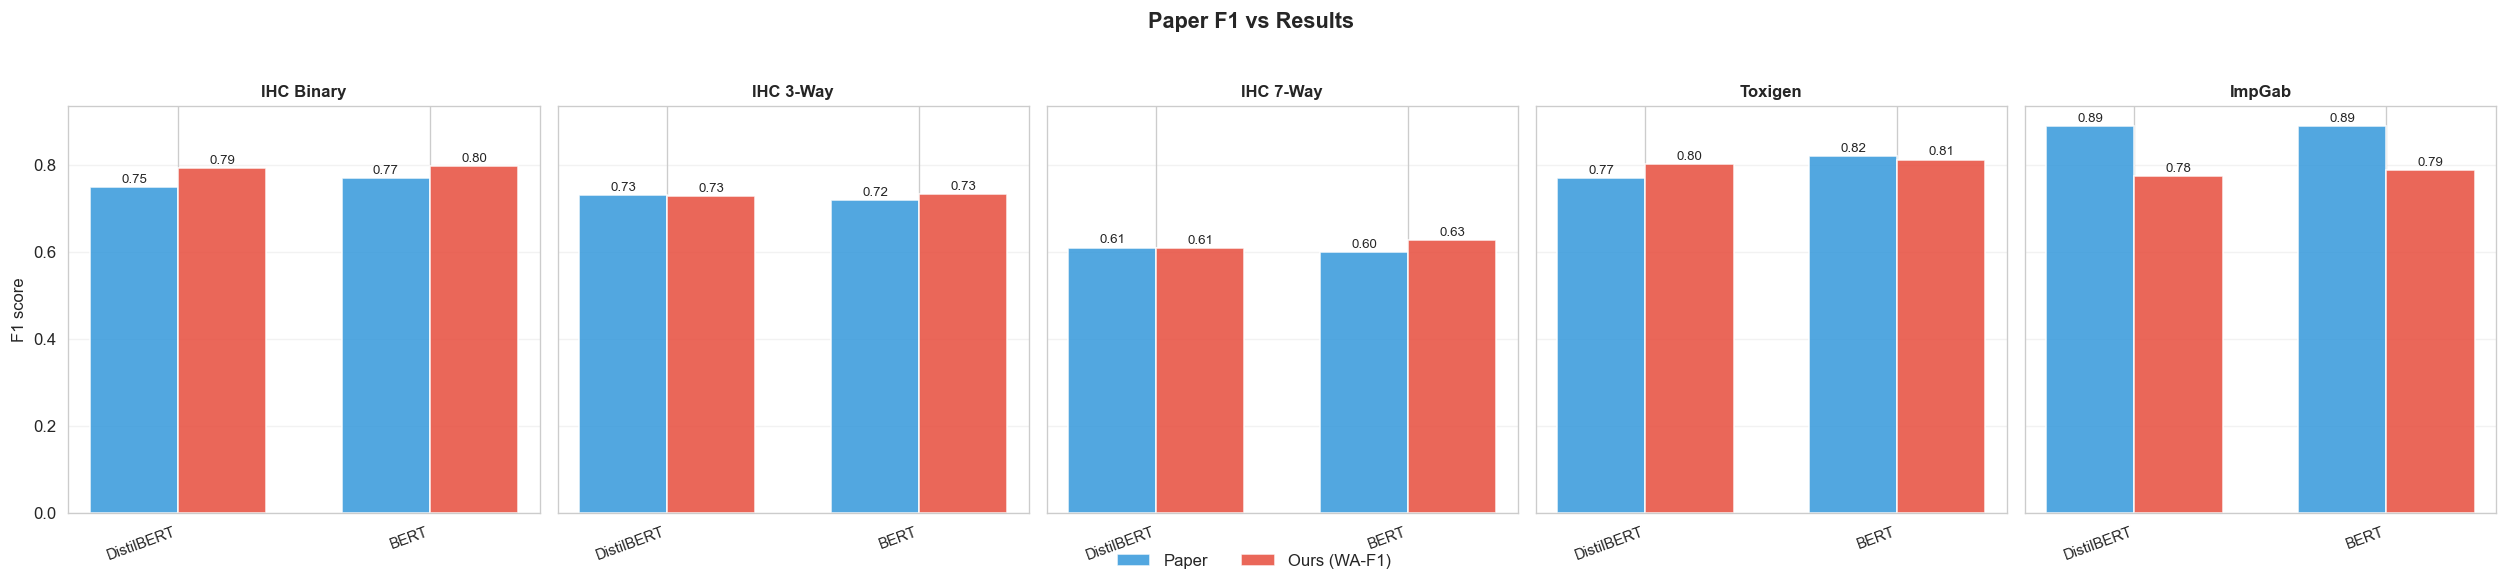

Saved: figures/paper_vs_WA_F1.png


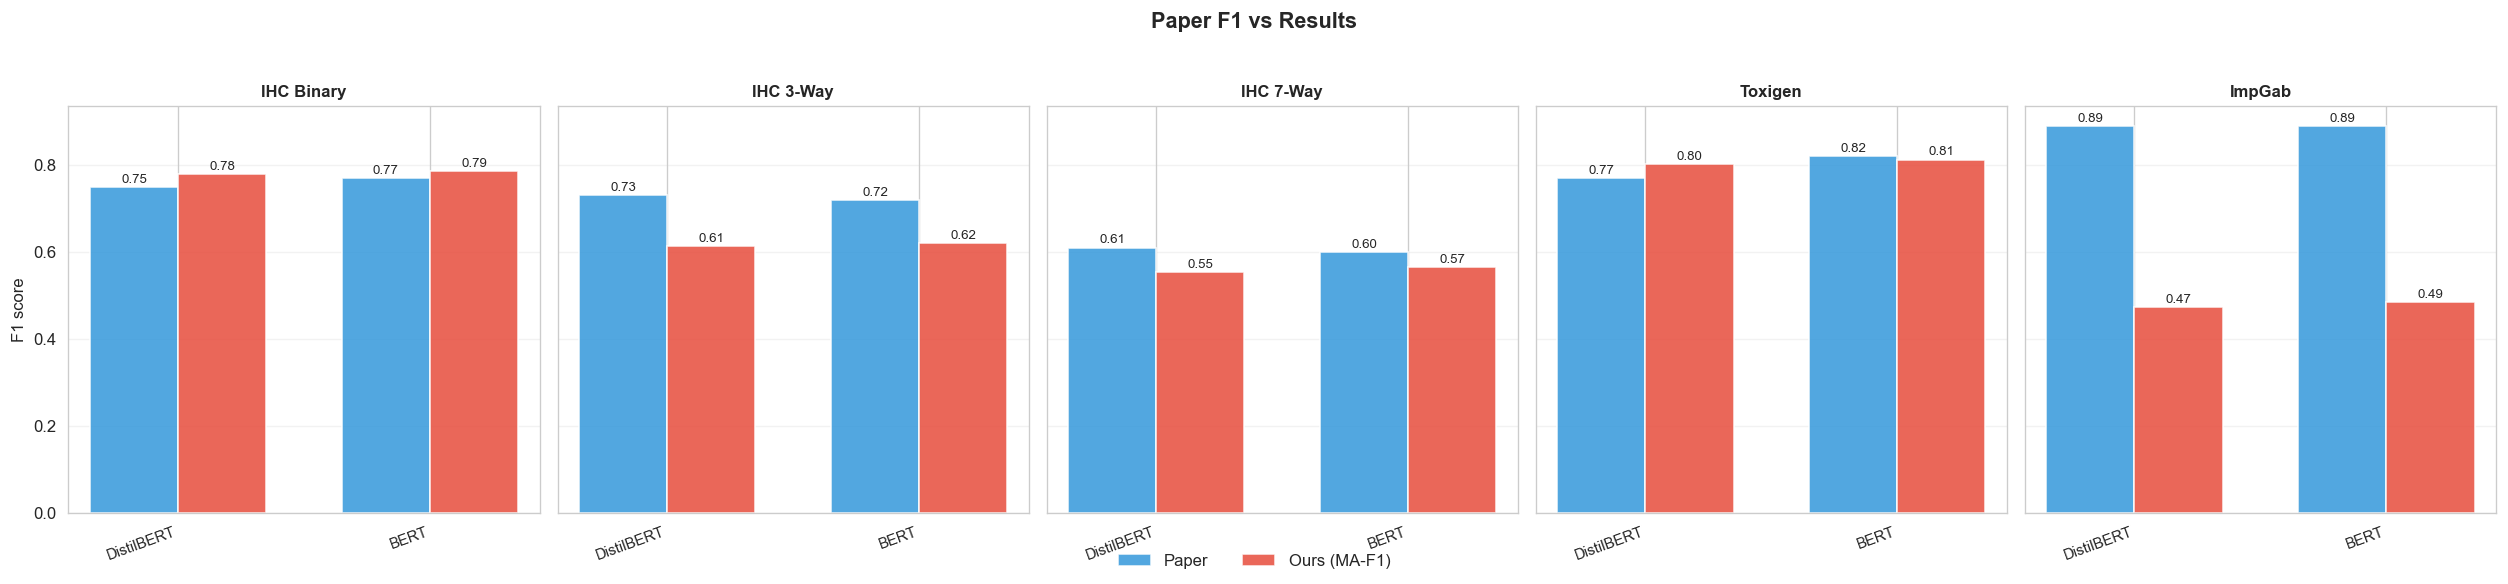

Saved: figures/paper_vs_MA_F1.png


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


our_rows = [
    ("IHC 3-Way", "DistilBERT", 0.7293, 0.6131),
    ("IHC 3-Way", "BERT",       0.7322, 0.6199),

    ("IHC Binary","DistilBERT", 0.7929, 0.7793),
    ("IHC Binary","BERT",       0.7969, 0.7852),

    ("IHC 7-Way", "DistilBERT", 0.6083, 0.5546),
    ("IHC 7-Way", "BERT",       0.6269, 0.5654),

    ("Toxigen",   "BERT",       0.8125, 0.8125),
    ("Toxigen",   "DistilBERT", 0.8027, 0.8027),

    ("ImpGab",    "BERT",       0.7873, 0.4856),
    ("ImpGab",    "DistilBERT", 0.7752, 0.4728),
]
ours = pd.DataFrame(our_rows, columns=["Dataset", "Model", "WA-F1", "MA-F1"])


paper_rows = [
    ("IHC 3-Way",  "DistilBERT", 0.73),
    ("IHC 3-Way",  "BERT",       0.72),

    ("IHC Binary", "DistilBERT", 0.75),
    ("IHC Binary", "BERT",       0.77),

    ("IHC 7-Way",  "DistilBERT", 0.61),
    ("IHC 7-Way",  "BERT",       0.60),

    ("Toxigen",    "DistilBERT", 0.77),
    ("Toxigen",    "BERT",       0.82),

    ("ImpGab",     "DistilBERT", 0.89),
    ("ImpGab",     "BERT",       0.89),
]
paper = pd.DataFrame(paper_rows, columns=["Dataset", "Model", "Paper_F1"])

df = ours.merge(paper, on=["Dataset", "Model"], how="inner")

df["Diff_WA"] = df["WA-F1"] - df["Paper_F1"]
df["Diff_MA"] = df["MA-F1"] - df["Paper_F1"]

print("Merged comparison table:")
print(df.sort_values(["Dataset", "Model"]).to_string(index=False))


def plot_compare(metric_col, title, outfile):
    
    datasets = ["IHC Binary", "IHC 3-Way", "IHC 7-Way", "Toxigen", "ImpGab"]
    models = ["DistilBERT", "BERT"]

    fig, axes = plt.subplots(1, len(datasets), figsize=(4.2*len(datasets), 4.6), sharey=True)
    if len(datasets) == 1:
        axes = [axes]

    for ax, ds in zip(axes, datasets):
        sub = df[df["Dataset"] == ds].set_index("Model").loc[models].reset_index()

        x = np.arange(len(models))
        w = 0.35

        ax.bar(x - w/2, sub["Paper_F1"], width=w, label="Paper", color="#3498db", alpha=0.85)
        ax.bar(x + w/2, sub[metric_col], width=w, label=f"Ours ({metric_col})", color="#e74c3c", alpha=0.85)

        ax.set_title(ds, fontsize=10, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=20, ha="right", fontsize=9)
        ax.grid(axis="y", alpha=0.25)

        
        for i, (p, o) in enumerate(zip(sub["Paper_F1"], sub[metric_col])):
            ax.text(i - w/2, p + 0.01, f"{p:.2f}", ha="center", fontsize=8)
            ax.text(i + w/2, o + 0.01, f"{o:.2f}", ha="center", fontsize=8)

    axes[0].set_ylabel("F1 score", fontsize=10)
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)

    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.savefig(outfile, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved: {outfile}")

plot_compare(
    metric_col="WA-F1",
    title="Paper F1 vs Results ",
    outfile="figures/paper_vs_WA_F1.png",
)

plot_compare(
    metric_col="MA-F1",
    title="Paper F1 vs Results",
    outfile="figures/paper_vs_MA_F1.png",
)

# CELL 19: Load All Trained Models for GUI

In [22]:
MODEL_REGISTRY = {
    'ihc_3way_distilbert': {
        'display_dataset': 'IHC 3-Way',   'display_model': 'DistilBERT',
        'type': 'distilbert',
    },
    'ihc_3way_bert': {
        'display_dataset': 'IHC 3-Way',   'display_model': 'BERT',
        'type': 'bert',
    },
    'ihc_binary_distilbert': {
        'display_dataset': 'IHC Binary',  'display_model': 'DistilBERT',
        'type': 'distilbert',
    },
    'ihc_binary_bert': {
        'display_dataset': 'IHC Binary',  'display_model': 'BERT',
        'type': 'bert',
    },
    'ihc_7way_distilbert': {
        'display_dataset': 'IHC 7-Way',   'display_model': 'DistilBERT',
        'type': 'distilbert',
    },
    'ihc_7way_bert': {
        'display_dataset': 'IHC 7-Way',   'display_model': 'BERT',
        'type': 'bert',
    },
    'Toxigen_binary_BERT': {
        'display_dataset': 'Toxigen',     'display_model': 'BERT',
        'type': 'bert',
    },
    'Toxigen_binary_DistilBERT': {
        'display_dataset': 'Toxigen',     'display_model': 'DistilBERT',
        'type': 'distilbert',
    },
    'ImpGab_3way_BERT': {
        'display_dataset': 'ImpGab 3-Way','display_model': 'BERT',
        'type': 'bert',
    },
    'ImpGab_3way_DistilBERT': {
        'display_dataset': 'ImpGab 3-Way','display_model': 'DistilBERT',
        'type': 'distilbert',
    },
}

def _load_model_dir(model_dir, model_type):
    le_path    = os.path.join(model_dir, 'label_encoder.pkl')
    lname_path = os.path.join(model_dir, 'label_names.json')

    if os.path.exists(le_path):
        with open(le_path, 'rb') as f:
            le = pickle.load(f)
        labels = list(le.classes_)
    elif os.path.exists(lname_path):
        with open(lname_path) as f:
            labels = json.load(f)
        le = None
    else:
        raise FileNotFoundError(f"No label_encoder.pkl or label_names.json in {model_dir}")

    if model_type == 'distilbert':
        tok   = DistilBertTokenizer.from_pretrained(model_dir)
        model = DistilBertForSequenceClassification.from_pretrained(
                    model_dir, output_attentions=True)
    else:
        tok   = BertTokenizer.from_pretrained(model_dir)
        model = BertForSequenceClassification.from_pretrained(
                    model_dir, output_attentions=True)
    model.to(DEVICE)
    model.eval()
    return model, tok, labels

LOADED_MODELS = {}


for exp_name, info in MODEL_REGISTRY.items():
    model_dir = f'models/{exp_name}'
    if not os.path.isdir(model_dir):
        print(f"  {exp_name:<32} NOT FOUND — run training cells first")
        continue
    if not os.path.exists(os.path.join(model_dir, 'config.json')):
        print(f"  {exp_name:<32} config.json missing")
        continue
    try:
        m, t, labels = _load_model_dir(model_dir, info['type'])
        LOADED_MODELS[exp_name] = {
            **info, 'model': m, 'tokenizer': t,
            'labels': labels, 'dir': model_dir,
        }
        tag = f"{info['display_dataset']} [{info['display_model']}]"
        print(f"  {tag:<35} labels={labels}")
    except Exception as e:
        print(f"  {exp_name}: {e}")

if not LOADED_MODELS:
    raise RuntimeError("No trained models found. Run cells 13-17 first.")

print(f"\n {len(LOADED_MODELS)} model(s) loaded.")

_loaded_ds = sorted({v['display_dataset'] for v in LOADED_MODELS.values()})
_loaded_mt = sorted({v['display_model']   for v in LOADED_MODELS.values()})
print(f"Datasets : {_loaded_ds}")
print(f"Models   : {_loaded_mt}")

def _find_exp(dataset_label, model_label):
    for exp, info in LOADED_MODELS.items():
        if info['display_dataset'] == dataset_label and info['display_model'] == model_label:
            return exp
    return None

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 590.11it/s, Materializing param=pre_classifier.weight]                                  


  IHC 3-Way [DistilBERT]              labels=['explicit_hate', 'implicit_hate', 'not_hate']


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 620.07it/s, Materializing param=classifier.weight]                                      


  IHC 3-Way [BERT]                    labels=['explicit_hate', 'implicit_hate', 'not_hate']


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 599.67it/s, Materializing param=pre_classifier.weight]                                  


...

  Toxigen [DistilBERT]                labels=['implicit_hate', 'nonhate']


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 563.40it/s, Materializing param=classifier.weight]                                      


  ImpGab 3-Way [BERT]                 labels=['explicit', 'implicit', 'nonhate']


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 436.22it/s, Materializing param=pre_classifier.weight]                                  


  ImpGab 3-Way [DistilBERT]           labels=['explicit', 'implicit', 'nonhate']

 10 model(s) loaded.
Datasets : ['IHC 3-Way', 'IHC 7-Way', 'IHC Binary', 'ImpGab 3-Way', 'Toxigen']
Models   : ['BERT', 'DistilBERT']


# CELL 20: Prediction + Explainability Helper Functions

In [23]:

import io
import matplotlib
matplotlib.use('Agg')
import matplotlib.patches as mpatches
from PIL import Image

os.makedirs('logs',    exist_ok=True)
os.makedirs('figures', exist_ok=True)

LOG_FILE  = 'logs/hatefusion_gui_history.csv'
FLAG_FILE = 'logs/hatefusion_gui_flags.csv'

LOG_HEADERS = [
    'timestamp', 'raw_text', 'enriched_text',
    'dataset', 'model_type', 'predicted_label', 'probability',
    'emoji_count', 'hate_emoji_count', 'max_hate_score', 'categories_json'
]
FLAG_HEADERS = LOG_HEADERS + ['flag_reason']

for fpath, hdr in [(LOG_FILE, LOG_HEADERS), (FLAG_FILE, FLAG_HEADERS)]:
    if not os.path.exists(fpath):
        with open(fpath, 'w', newline='', encoding='utf-8') as f:
            csv.writer(f).writerow(hdr)



_LABEL_COLORS = {
    'implicit_hate':'#e67e22', 'implicit':'#e67e22',
    'explicit_hate':'#e74c3c', 'explicit':'#e74c3c', 'hate':'#e74c3c',
    'incitement':'#c0392b',    'threatening':'#8e44ad',
    'white_grievance':'#d35400','stereotypical':'#e74c3c',
    'inferiority':'#e67e22',   'irony':'#f39c12', 'other':'#95a5a6',
    'nonhate':'#2ecc71',       'not_hate':'#2ecc71',
}

def _lcolor(label):
    for k, v in _LABEL_COLORS.items():
        if k in label.lower(): return v
    return '#3498db'

def _is_hate(label):
    l = label.lower()
    return (any(k in l for k in ['hate','implicit','explicit','incitement',
                                  'threatening','grievance','stereotypical','infer'])
            and 'not' not in l and 'non' not in l)

def _fig2pil(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    buf.seek(0)
    img = Image.open(buf).copy()
    plt.close(fig)
    return img

def _empty_img(msg="", size=(9,3)):
    fig, ax = plt.subplots(figsize=size)
    ax.text(0.5, 0.5, msg, ha='center', va='center', fontsize=11, color='gray',
            style='italic', wrap=True,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', edgecolor='#dee2e6'))
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
    return _fig2pil(fig)


def predict_single(text, exp_name):
    if exp_name not in LOADED_MODELS:
        return None, 0.0, {}, None, None
    e       = LOADED_MODELS[exp_name]
    cleaned = clean_text_paper(text)
    if not cleaned.strip():
        return None, 0.0, {}, None, None
    enc = e['tokenizer'](cleaned, return_tensors='pt', max_length=128,
                         truncation=True, padding=True)
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    with torch.no_grad():
        out = e['model'](**enc)
    probs   = torch.softmax(out.logits, dim=-1)[0].cpu().numpy()
    idx     = int(np.argmax(probs))
    labels  = e['labels']
    pred    = labels[idx]
    conf    = float(probs[idx])
    probs_d = {labels[i]: float(probs[i]) for i in range(len(labels))}
    tokens  = e['tokenizer'].convert_ids_to_tokens(enc['input_ids'][0].cpu().tolist())
    return pred, conf, probs_d, out.attentions, tokens



def fig_prob_chart(probs_d, pred, title="Prediction Probabilities"):
    labels = list(probs_d.keys())
    values = list(probs_d.values())
    fig, ax = plt.subplots(figsize=(7, max(3, len(labels)*0.7+1.5)))
    colors  = [_lcolor(l) if l==pred else '#bdc3c7' for l in labels]
    bars    = ax.barh(labels, values, color=colors, alpha=0.88,
                      edgecolor='black', linewidth=0.6, height=0.5)
    for bar, val in zip(bars, values):
        ax.text(min(val+0.03,1.12), bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', va='center', ha='left', fontsize=11, fontweight='bold')
    ax.set_xlim(0, 1.28); ax.set_xlabel('Probability', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.4)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    return _fig2pil(fig)


def fig_bertviz(attentions, tokens, layer=1):
    if attentions is None:
        return _empty_img("No attention data available.")
    clean_tok = [t for t in tokens if t != '[PAD]']
    n         = len(clean_tok)
    n_heads   = attentions[layer].shape[1]
    show      = min(n_heads, 6)
    cols, rows = show, (show+2)//3
    HEAD_C = ['#FF3333','#FF8800','#FFEE00','#00FF44','#3399FF','#CC44FF']
    fig, axes = plt.subplots(rows, cols,
                             figsize=(cols*4, rows*max(4, n*0.44+1.2)))
    fig.patch.set_facecolor('#1a1a1a')
    flat = axes.flatten() if rows*cols > 1 else [axes]
    for h in range(show):
        ax = flat[h]; ax.set_facecolor('black')
        attn = attentions[layer][0, h, :n, :n].cpu().numpy()
        for i in range(n):
            for j in range(n):
                w = float(attn[i,j])
                if w > 0.04:
                    ax.plot([0,1],[n-1-i, n-1-j],
                            color=HEAD_C[h%6], alpha=min(1.0, w*2.5),
                            linewidth=min(3.0, w*4.0))
        ax.set_xlim(-0.15, 1.15); ax.set_ylim(-0.6, n-0.4)
        ax.set_yticks(range(n))
        ax.set_yticklabels(clean_tok[::-1], fontsize=8, color='white')
        ax.set_xticks([])
        for sp in ax.spines.values(): sp.set_edgecolor('#444')
        ax.set_title(f'Layer {layer}, Head {h}', fontsize=9, color='white',
                     fontweight='bold',
                     bbox=dict(boxstyle='round', facecolor=HEAD_C[h%6], alpha=0.6))
        ax.tick_params(colors='white')
    for h in range(show, len(flat)):
        flat[h].set_visible(False)
    fig.suptitle(f'BertViz — Layer {layer} (Paper Figs 3 & 4)',
                 fontsize=13, fontweight='bold', color='white', y=1.01)
    plt.tight_layout()
    return _fig2pil(fig)



def fig_lime(text, exp_name, num_samples=300):
    if not HAS_LIME:
        return _empty_img("pip install lime")
    e = LOADED_MODELS.get(exp_name)
    if e is None:
        return _empty_img("Model not loaded.")
    cleaned   = clean_text_paper(text)
    predictor = BatchedPredictor(e['model'], e['tokenizer'],
                                DEVICE, max_length=128, batch_size=LIME_BATCH_SIZE)
    app_labels = e['labels']
    try:
        explainer = LimeTextExplainer(class_names=app_labels, random_state=42)
        exp_obj   = explainer.explain_instance(
            cleaned, predictor.predict_proba,
            num_features=min(15, len(cleaned.split())),
            num_samples=num_samples,
            labels=list(range(len(app_labels))))

        pred, conf, probs_d, _, _ = predict_single(text, exp_name)
        pred_idx = app_labels.index(pred) if pred in app_labels else 0

        fig = plt.figure(figsize=(17, max(6, len(cleaned.split())*0.42+3)))
        gs  = fig.add_gridspec(1, 3, width_ratios=[1,2,1.6], wspace=0.38)

        
        ax_p = fig.add_subplot(gs[0])
        pl, pv = list(probs_d.keys()), list(probs_d.values())
        bc = [_lcolor(l) if l==pred else '#bdc3c7' for l in pl]
        bars = ax_p.barh(pl, pv, color=bc, alpha=0.85, edgecolor='black', linewidth=0.5)
        for bar, val in zip(bars, pv):
            ax_p.text(max(val+0.03,0.06), bar.get_y()+bar.get_height()/2,
                      f'{val:.2f}', ha='left', fontsize=10, fontweight='bold')
        ax_p.set_xlim(0,1.3); ax_p.axvline(0.5,color='gray',linestyle='--',alpha=0.4)
        ax_p.set_title('Prediction\nprobabilities', fontsize=11, fontweight='bold')
        ax_p.grid(axis='x', alpha=0.3)

       
        ax_l = fig.add_subplot(gs[1])
        try:
            feats = exp_obj.as_list(label=pred_idx)
        except Exception:
            feats = exp_obj.as_list()
        words, wts = [f[0] for f in feats], [f[1] for f in feats]
        lc = ['#e67e22' if w>0 else '#3498db' for w in wts]
        ax_l.barh(range(len(words)), wts, color=lc, alpha=0.85,
                  edgecolor='black', linewidth=0.5, height=0.6)
        for i,(word,wt) in enumerate(zip(words,wts)):
            ax_l.text(wt+(0.005 if wt>=0 else -0.005), i, f'{wt:.3f}',
                      va='center', ha='left' if wt>=0 else 'right', fontsize=8)
        ax_l.set_yticks(range(len(words))); ax_l.set_yticklabels(words, fontsize=9)
        ax_l.axvline(0, color='black', linewidth=1.0)
        nh = next((l for l in app_labels if 'not' in l.lower() or 'non' in l.lower()), app_labels[0])
        ax_l.set_title(f'← {nh}    {pred} →', fontsize=11, fontweight='bold')
        ax_l.set_xlabel('Feature Weight', fontsize=9)
        ax_l.grid(axis='x', alpha=0.3)
        ax_l.legend(handles=[mpatches.Patch(color='#e67e22',label='→ Hate'),
                             mpatches.Patch(color='#3498db',label=f'→ {nh}')],
                    fontsize=8, loc='lower right')

        
        ax_t = fig.add_subplot(gs[2])
        ax_t.set_xlim(0,1); ax_t.set_ylim(0,1); ax_t.axis('off')
        ax_t.set_title('Text with highlighted words', fontsize=11, fontweight='bold')
        wi = {f[0].lower():f[1] for f in feats}
        xc, yc, lh = 0.02, 0.90, 0.08
        for word in cleaned.split():
            wl  = word.lower().strip('.,!?;:')
            imp = wi.get(wl, 0)
            ww  = len(word)*0.018+0.02
            if xc+ww > 0.95: xc=0.02; yc-=lh*1.4
            if yc < 0.06: break
            if imp > 0.05:    bg,tc='#FF8C00','white'
            elif imp < -0.05: bg,tc='#3498db','white'
            else:             bg,tc='white','black'
            if bg != 'white':
                ax_t.add_patch(mpatches.FancyBboxPatch(
                    (xc-0.003, yc-lh*0.4), ww+0.004, lh*0.85,
                    boxstyle="round,pad=0.002", facecolor=bg, edgecolor='none',
                    alpha=0.75, transform=ax_t.transAxes, clip_on=True))
            ax_t.text(xc, yc, word, fontsize=10, color=tc,
                      transform=ax_t.transAxes, verticalalignment='center',
                      fontweight='bold' if bg!='white' else 'normal')
            xc += ww
        ax_t.text(0.5, 0.04, f'Prediction: {pred} ({conf:.4f})',
                  ha='center', va='center', fontsize=11, fontweight='bold',
                  color=_lcolor(pred), transform=ax_t.transAxes,
                  bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                            edgecolor=_lcolor(pred), alpha=0.9))

        fig.suptitle(f'LIME — {e["display_dataset"]} [{e["display_model"]}] — Paper Fig 10',
                     fontsize=13, fontweight='bold', y=1.01)
        plt.tight_layout()
        img = _fig2pil(fig)
        plt.savefig(f'figures/lime_{exp_name}.png', dpi=150, bbox_inches='tight')
        return img
    except Exception as exc:
        return _empty_img(f'LIME error:\n{exc}')



def fig_shap(text, exp_name):
    if not HAS_SHAP:
        return _empty_img("pip install shap")
    import shap
    e = LOADED_MODELS.get(exp_name)
    if e is None:
        return _empty_img("Model not loaded.")
    cleaned   = clean_text_paper(text)
    predictor = BatchedPredictor(e['model'], e['tokenizer'],
                                DEVICE, max_length=128, batch_size=LIME_BATCH_SIZE)
    app_labels = e['labels']
    try:
        masker    = shap.maskers.Text(e['tokenizer'])
        explainer = shap.Explainer(predictor.predict_proba, masker,
                                   output_names=app_labels)
        sv        = explainer([cleaned], max_evals=64, batch_size=16)
        pred, conf, probs_d, _, _ = predict_single(text, exp_name)
        pidx  = app_labels.index(pred) if pred in app_labels else 0
        vals  = sv[0, :, pidx].values
        feats = sv[0, :, pidx].data
        top_n = min(15, len(vals))
        si    = np.argsort(np.abs(vals))[::-1][:top_n]
        sw    = [vals[i]  for i in si]
        sf    = [feats[i] for i in si]
        colors = ['#e74c3c' if v>0 else '#3498db' for v in sw]

        fig, axes = plt.subplots(1,2, figsize=(14, max(5, top_n*0.4+2)))
        fig.suptitle(f'SHAP — {e["display_dataset"]} [{e["display_model"]}] | '
                     f'{pred} ({conf:.4f})', fontsize=13, fontweight='bold')

        ax1 = axes[0]
        ax1.barh(range(top_n), sw[::-1], color=colors[::-1], alpha=0.85,
                 edgecolor='black', linewidth=0.5)
        ax1.set_yticks(range(top_n)); ax1.set_yticklabels(sf[::-1], fontsize=9)
        ax1.axvline(0, color='black', linewidth=1.0)
        ax1.set_xlabel('SHAP Value', fontsize=10)
        ax1.set_title(f'Top Tokens → {pred}', fontsize=11, fontweight='bold')
        ax1.grid(axis='x', alpha=0.3)
        ax1.legend(handles=[mpatches.Patch(color='#e74c3c',label='→ Hate'),
                            mpatches.Patch(color='#3498db',label='→ Not-Hate')],
                   fontsize=8)

        ax2 = axes[1]
        pl, pv = list(probs_d.keys()), list(probs_d.values())
        bc = [_lcolor(l) if l==pred else '#bdc3c7' for l in pl]
        bars = ax2.bar(range(len(pl)), pv, color=bc, alpha=0.85,
                       edgecolor='black', linewidth=0.5)
        for bar, val in zip(bars, pv):
            ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax2.set_xticks(range(len(pl))); ax2.set_xticklabels(pl, rotation=20, ha='right', fontsize=9)
        ax2.set_ylabel('Probability', fontsize=10)
        ax2.set_title('Class Probabilities', fontsize=11, fontweight='bold')
        ax2.set_ylim(0,1.18); ax2.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        img = _fig2pil(fig)
        plt.savefig(f'figures/shap_{exp_name}.png', dpi=150, bbox_inches='tight')
        return img
    except Exception as exc:
        return _empty_img(f'SHAP error:\n{exc}')


def fig_emoji_analysis(text):
    
    emojis = emoji_extract(text)

    if not emojis:
        return _empty_img("No emojis found in this text.\n\n"
                          "Try text with emojis like:\n"
                          "'You people 🐒🐒 go back 🔪'")

    infos = [e['info'] for e in emojis]
    feat  = emoji_compute_features(text)


    seen = {}
    for info in infos:
        key = info['emoji']
        if key not in seen:
            seen[key] = info
        else:
            seen[key]['count'] = seen.get(key, {}).get('count', 1) + 1

    unique_infos = list(seen.values())
    for ui in unique_infos:
        if 'count' not in ui:
            ui['count'] = 1

    fig, axes = plt.subplots(1, 3, figsize=(18, max(4, len(unique_infos)*0.6+2)),
                             gridspec_kw={'width_ratios': [2, 2.5, 1.5]})
    fig.suptitle('📊 Emoji Analysis — HateEmoFusion',
                 fontsize=14, fontweight='bold', y=1.02)

   
    ax1 = axes[0]
    ax1.axis('off')
    ax1.set_title('Emojis Detected', fontsize=12, fontweight='bold')

    table_data = []
    cell_colors = []
    for info in unique_infos:
        is_hate = info['is_hate_emoji']
        row = [
            info['emoji'],
            info['meaning'][:25],
            f"{info['hate_score']:.2f}",
            info['category'][:15],
            f"×{info.get('count',1)}",
            " HATE" if is_hate else "✅ Safe"
        ]
        table_data.append(row)
        bg = '#ffcccc' if is_hate else '#ccffcc'
        cell_colors.append([bg]*6)

    if table_data:
        table = ax1.table(cellText=table_data,
                          colLabels=['Emoji','Meaning','Score','Category','Count','Status'],
                          cellColours=cell_colors,
                          colColours=['#ddd']*6,
                          loc='center', cellLoc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1, 1.5)

   
    ax2 = axes[1]
    emoji_labels = [f"{i['emoji']} {i['meaning'][:15]}" for i in unique_infos]
    scores = [i['hate_score'] for i in unique_infos]
    bar_colors = ['#e74c3c' if i['is_hate_emoji'] else '#2ecc71' for i in unique_infos]

    bars = ax2.barh(range(len(emoji_labels)), scores, color=bar_colors,
                    alpha=0.85, edgecolor='black', linewidth=0.5, height=0.6)
    for bar, score in zip(bars, scores):
        ax2.text(score + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{score:.2f}', va='center', fontsize=10, fontweight='bold')
    ax2.set_yticks(range(len(emoji_labels)))
    ax2.set_yticklabels(emoji_labels, fontsize=9)
    ax2.set_xlim(0, 1.15)
    ax2.set_xlabel('Hate Score (0-1)', fontsize=10)
    ax2.set_title('Emoji Hate Scores', fontsize=12, fontweight='bold')
    ax2.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Threshold')
    ax2.grid(axis='x', alpha=0.3)
    ax2.legend(handles=[mpatches.Patch(color='#e74c3c', label='Hate Emoji'),
                        mpatches.Patch(color='#2ecc71', label='Safe Emoji')],
               fontsize=8)

    
    ax3 = axes[2]
    ax3.axis('off')
    ax3.set_title('Feature Summary', fontsize=12, fontweight='bold')

    summary_text = (
        f"Total Emojis     : {int(feat[0])}\n"
        f"Hate Emojis      : {int(feat[1])}\n"
        f"Hate Ratio       : {feat[2]*100:.0f}%\n"
        f"Avg Hate Score   : {feat[3]:.3f}\n"
        f"Max Hate Score   : {feat[4]:.3f}\n"
        f"Avg Sentiment    : {feat[5]:+.3f}\n"
        f"Has Threatening  : {'Yes ' if feat[6] else 'No ✅'}\n"
        f"Has Dehumanizing : {'Yes ' if feat[7] else 'No ✅'}\n"
        f"Has Death Threat : {'Yes ' if feat[8] else 'No ✅'}\n"
    )

    alert_color = '#e74c3c' if feat[1] > 0 else '#2ecc71'
    ax3.text(0.1, 0.5, summary_text, fontsize=10, fontfamily='monospace',
             va='center', transform=ax3.transAxes,
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa',
                       edgecolor=alert_color, linewidth=2))

    plt.tight_layout()
    img = _fig2pil(fig)
    plt.savefig('figures/emoji_analysis.png', dpi=150, bbox_inches='tight')
    return img


def _save_log(text, exp_name, pred, conf):
    e  = LOADED_MODELS.get(exp_name, {})
    ts = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    enriched = emoji_enrich_text(text)
    feat = emoji_compute_features(text)
    cats_json = emoji_get_categories_json(text)
    try:
        with open(LOG_FILE, 'a', newline='', encoding='utf-8') as f:
            csv.writer(f).writerow([
                ts,
                text[:500],
                enriched[:500],
                e.get('display_dataset', ''),
                e.get('display_model', ''),
                pred,
                f'{conf:.4f}',
                int(feat[0]),
                int(feat[1]),
                f'{feat[4]:.4f}',
                cats_json,
            ])
    except Exception as exc:
        print(f"Log write error: {exc}")

def _load_history():
    if not os.path.exists(LOG_FILE):
        return pd.DataFrame(columns=LOG_HEADERS)
    df = pd.read_csv(LOG_FILE, encoding='utf-8')
    if df.empty:
        return pd.DataFrame(columns=LOG_HEADERS)
    df = df.tail(30).iloc[::-1].reset_index(drop=True)
    return df

def _flag_prediction(text, exp_name, pred, conf, reason=""):
    e  = LOADED_MODELS.get(exp_name, {})
    ts = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    enriched = emoji_enrich_text(text)
    feat = emoji_compute_features(text)
    cats_json = emoji_get_categories_json(text)
    try:
        with open(FLAG_FILE, 'a', newline='', encoding='utf-8') as f:
            csv.writer(f).writerow([
                ts, text[:500], enriched[:500],
                e.get('display_dataset',''), e.get('display_model',''),
                pred, f'{conf:.4f}',
                int(feat[0]), int(feat[1]), f'{feat[4]:.4f}',
                cats_json,
                reason[:200] if reason else '',
            ])
        return f"Flagged and saved to {FLAG_FILE}"
    except Exception as exc:
        return f"Flag failed: {exc}"

def _load_flags():
    if not os.path.exists(FLAG_FILE):
        return pd.DataFrame(columns=FLAG_HEADERS)
    df = pd.read_csv(FLAG_FILE, encoding='utf-8')
    if df.empty:
        return pd.DataFrame(columns=FLAG_HEADERS)
    df = df.tail(30).iloc[::-1].reset_index(drop=True)
    return df


print("All functions defined.")

All functions defined.


# CELL 20.1: Word2Vec Baseline + Classifier

In [24]:
import numpy as np
import re
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from gensim.models import Word2Vec

def w2v_tokenize(text: str):
    
    return re.findall(r"[a-z']+", str(text).lower())

def train_word2vec_embeddings(texts, vector_size=200, window=5, min_count=2, workers=4, seed=42):
    
    sentences = [w2v_tokenize(t) for t in texts]
    model = Word2Vec(
        sentences=sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        sg=1,              
        workers=workers,
        seed=seed
    )
    return model

def text_to_tfidf_w2v_vector(text, w2v_model, tfidf_vec, vector_size):
    toks = w2v_tokenize(text)
    if not toks:
        return np.zeros(vector_size, dtype=np.float32)

   
    tfidf = tfidf_vec.transform([text])
    weights = {}

    feature_names = tfidf_vec.get_feature_names_out()
    idxs = tfidf.indices
    vals = tfidf.data
    for i, v in zip(idxs, vals):
        weights[feature_names[i]] = float(v)

    vecs = []
    wts  = []
    for t in toks:
        if t in w2v_model.wv:
            vecs.append(w2v_model.wv[t])
            wts.append(weights.get(t, 0.0))

    if not vecs:
        return np.zeros(vector_size, dtype=np.float32)

    wts = np.array(wts, dtype=np.float32)
    if wts.sum() == 0:
       
        return np.mean(np.array(vecs), axis=0).astype(np.float32)

    wts = wts / (wts.sum() + 1e-9)
    return (np.sum(np.array(vecs) * wts[:, None], axis=0)).astype(np.float32)

def build_w2v_matrix(texts, w2v_model, tfidf_vec, vector_size):
    return np.vstack([text_to_tfidf_w2v_vector(t, w2v_model, tfidf_vec, vector_size) for t in texts])


W2V_DATASET_NAME = "IHC Binary"   
w2v_df = ALL_DATASETS[W2V_DATASET_NAME]["df"].copy()


w2v_texts = w2v_df["clean_text"].astype(str).tolist()
w2v_labels = w2v_df["label"].astype(str).tolist()


from sklearn.model_selection import train_test_split
le_w2v = LabelEncoder()
y_all = le_w2v.fit_transform(w2v_labels)

train_texts, temp_texts, y_train, y_temp = train_test_split(
    w2v_texts, y_all, test_size=0.20, random_state=42, stratify=y_all
)
val_texts, test_texts, y_val, y_test = train_test_split(
    temp_texts, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"[Word2Vec baseline] Dataset={W2V_DATASET_NAME}")
print(f"  Train={len(train_texts):,}  Val={len(val_texts):,}  Test={len(test_texts):,}")
print(f"  Labels={list(le_w2v.classes_)}")

tfidf_vec = TfidfVectorizer(
    tokenizer=w2v_tokenize,
    lowercase=True,
    min_df=2
)
tfidf_vec.fit(train_texts)

W2V_DIM = 200
w2v_model = train_word2vec_embeddings(train_texts, vector_size=W2V_DIM, seed=42)
print(f"  Trained Word2Vec vocab size: {len(w2v_model.wv)} | dim={W2V_DIM}")

X_train = build_w2v_matrix(train_texts, w2v_model, tfidf_vec, W2V_DIM)
X_val   = build_w2v_matrix(val_texts,   w2v_model, tfidf_vec, W2V_DIM)
X_test  = build_w2v_matrix(test_texts,  w2v_model, tfidf_vec, W2V_DIM)

w2v_clf = LogisticRegression(max_iter=2000, n_jobs=-1)
w2v_clf.fit(X_train, y_train)


val_probs = w2v_clf.predict_proba(X_val)
val_preds = np.argmax(val_probs, axis=1)

print("\n Validation report:")
print(classification_report(y_val, val_preds, target_names=list(le_w2v.classes_), zero_division=0))
print("Val accuracy:", accuracy_score(y_val, val_preds))

W2V_BUNDLE = {
    "dataset_name": W2V_DATASET_NAME,
    "w2v_model": w2v_model,
    "tfidf_vec": tfidf_vec,
    "clf": w2v_clf,
    "label_encoder": le_w2v,
    "vector_size": W2V_DIM,
}

[Word2Vec baseline] Dataset=IHC Binary
  Train=17,008  Val=2,126  Test=2,126
  Labels=['hate', 'not_hate']
  Trained Word2Vec vocab size: 9575 | dim=200

 Validation report:
              precision    recall  f1-score   support

        hate       0.66      0.29      0.40       813
    not_hate       0.67      0.91      0.77      1313

    accuracy                           0.67      2126
   macro avg       0.67      0.60      0.59      2126
weighted avg       0.67      0.67      0.63      2126

Val accuracy: 0.6702728127939793


# CELL 20.6: Tokenization + Tensor Visualization

In [25]:
def show_tokenization_and_tensors(text, exp_name, max_preview=30):
    
    e = LOADED_MODELS[exp_name]
    cleaned = clean_text_paper(text)

    print("="*80)
    print(f"EXPERIMENT: {exp_name}  | Dataset={e['display_dataset']} | Model={e['display_model']}")
    print("-"*80)
    print("RAW TEXT:")
    print(text)
    print("\nCLEANED TEXT (after preprocessing + emoji enrichment):")
    print(cleaned)

    
    enc = e["tokenizer"](
        cleaned,
        return_tensors="pt",
        max_length=128,
        truncation=True,
        padding=True
    )
    input_ids = enc["input_ids"][0]
    attn_mask = enc["attention_mask"][0]
    tokens = e["tokenizer"].convert_ids_to_tokens(input_ids.tolist())

    print("\nTOKENIZATION (Transformer tokenizer output):")
    print("Tokens:")
    print(tokens[:max_preview])
    print(f"... total tokens={len(tokens)}")

    print("\nTENSORS:")
    print("input_ids shape:", tuple(enc["input_ids"].shape))
    print("attention_mask shape:", tuple(enc["attention_mask"].shape))
    print("input_ids preview:", input_ids[:max_preview].tolist())
    print("attention_mask preview:", attn_mask[:max_preview].tolist())

def show_word2vec_tokenization(text, max_preview=60):
    cleaned = clean_text_paper(text)
    toks = w2v_tokenize(cleaned)
    print("="*80)
    print("WORD2VEC TOKENIZATION:")
    print("Cleaned text:")
    print(cleaned)
    print("\nTokens:")
    print(toks[:max_preview])
    print(f"... total tokens={len(toks)}")

EXAMPLE_TEXT = "You people are 🐒🐒🐒 go back 🔪"
show_word2vec_tokenization(EXAMPLE_TEXT)

any_exp = next(iter(LOADED_MODELS.keys()))
show_tokenization_and_tensors(EXAMPLE_TEXT, any_exp)

WORD2VEC TOKENIZATION:
Cleaned text:
people [monkey_racial_insult] [monkey_racial_insult] [monkey_racial_insult] go back [knife_weapon_violence]

Tokens:
['people', 'monkey', 'racial', 'insult', 'monkey', 'racial', 'insult', 'monkey', 'racial', 'insult', 'go', 'back', 'knife', 'weapon', 'violence']
... total tokens=15
EXPERIMENT: ihc_3way_distilbert  | Dataset=IHC 3-Way | Model=DistilBERT
--------------------------------------------------------------------------------
RAW TEXT:
You people are 🐒🐒🐒 go back 🔪

CLEANED TEXT (after preprocessing + emoji enrichment):
people [monkey_racial_insult] [monkey_racial_insult] [monkey_racial_insult] go back [knife_weapon_violence]

TOKENIZATION (Transformer tokenizer output):
Tokens:
['[CLS]', 'people', '[', 'monkey', '_', 'racial', '_', 'insult', ']', '[', 'monkey', '_', 'racial', '_', 'insult', ']', '[', 'monkey', '_', 'racial', '_', 'insult', ']', 'go', 'back', '[', 'knife', '_', 'weapon', '_']
... total tokens=33

TENSORS:
input_ids shape: (1, 3

# CELL 20.7: Compare models (BERT vs DistilBERT vs Word2Vec) + Visualization

In [26]:
def explain_word2vec_logreg(text, w2v_bundle, top_k=8):
    
    cleaned = clean_text_paper(text)
    toks = [t for t in w2v_tokenize(cleaned) if t in w2v_bundle["w2v_model"].wv]
    if not toks:
        return "No Word2Vec vocab tokens found for this text."

    clf = w2v_bundle["clf"]
    le  = w2v_bundle["label_encoder"]
    w2v = w2v_bundle["w2v_model"]

    vec = text_to_tfidf_w2v_vector(
        cleaned, w2v, w2v_bundle["tfidf_vec"], w2v_bundle["vector_size"]
    ).reshape(1, -1)

    probs = clf.predict_proba(vec)[0]
    pred_idx = int(np.argmax(probs))
    pred_label = le.classes_[pred_idx]


    if clf.coef_.shape[0] > 1:
        
        W = clf.coef_[pred_idx]
        note = f"(multiclass weights for '{pred_label}')"
    else:
       
        W_pos = clf.coef_[0]
        if pred_idx == 1:
            W = W_pos
            note = f"(binary weights toward positive class '{le.classes_[1]}')"
        else:
            W = -W_pos
            note = f"(binary flipped weights to explain negative class '{le.classes_[0]}')"

    contribs = [(t, float(np.dot(w2v.wv[t], W))) for t in toks]
    contribs_sorted = sorted(contribs, key=lambda x: x[1], reverse=True)

    top_pos = contribs_sorted[:top_k]
    top_neg = sorted(contribs, key=lambda x: x[1])[:top_k]

    lines = []
    lines.append(f"Word2Vec+LogReg predicted: {pred_label} (p={probs[pred_idx]:.4f}) {note}")
    lines.append("Top tokens pushing toward predicted class:")
    for t, s in top_pos:
        lines.append(f"  + {t:<15} {s:+.3f}")
    lines.append("Top tokens pushing away (opposite direction):")
    for t, s in top_neg:
        lines.append(f"  - {t:<15} {s:+.3f}")
    return "\n".join(lines)

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def _clean_for_any(text: str) -> str:
    
    fn = globals().get("clean_text_paper", None)
    return fn(text) if callable(fn) else str(text)

def predict_word2vec_proba(text, w2v_bundle):
    cleaned = _clean_for_any(text)
    clf = w2v_bundle["clf"]
    le  = w2v_bundle["label_encoder"]
    vec = text_to_tfidf_w2v_vector(
        cleaned, w2v_bundle["w2v_model"], w2v_bundle["tfidf_vec"], w2v_bundle["vector_size"]
    ).reshape(1, -1)
    probs = clf.predict_proba(vec)[0]
    labels = list(le.classes_)
    return {labels[i]: float(probs[i]) for i in range(len(labels))}

def visualize_one_example(dataset_label: str, text: str, max_tok_preview: int = 40):
    
    bert_exp   = _find_exp(dataset_label, "BERT")
    distil_exp = _find_exp(dataset_label, "DistilBERT")
    if bert_exp is None or distil_exp is None:
        raise ValueError(f"Could not find both BERT and DistilBERT for dataset '{dataset_label}'")

   
    cleaned = _clean_for_any(text)

    
    pred_b, conf_b, probs_b, att_b, tokens_b = predict_single(text, bert_exp)

    
    pred_d, conf_d, probs_d, att_d, tokens_d = predict_single(text, distil_exp)

    
    probs_w = predict_word2vec_proba(text, W2V_BUNDLE)
    pred_w = max(probs_w, key=probs_w.get)
    conf_w = probs_w[pred_w]

    print("=" * 90)
    print(f"DATASET: {dataset_label}")
    print("-" * 90)
    print("RAW TEXT:")
    print(text)
    print("\nCLEANED TEXT (used by models):")
    print(cleaned)
    print("-" * 90)
    print(f"BERT       => pred={pred_b} | conf={conf_b:.4f}")
    print(f"DistilBERT => pred={pred_d} | conf={conf_d:.4f}")
    print(f"Word2Vec   => pred={pred_w} | conf={conf_w:.4f}")
    print("=" * 90)

    print("\n[1] TOKENIZATION PREVIEW")
    print("-" * 90)

    eB = LOADED_MODELS[bert_exp]
    encB = eB["tokenizer"](cleaned, return_tensors="pt", max_length=128, truncation=True, padding=True)
    idsB = encB["input_ids"][0].tolist()
    maskB = encB["attention_mask"][0].tolist()

    print(f"\nBERT tokens (first {max_tok_preview}):")
    print(tokens_b[:max_tok_preview])
    print("BERT tensor shapes:",
          "input_ids", tuple(encB["input_ids"].shape),
          "| attention_mask", tuple(encB["attention_mask"].shape))
    print("BERT input_ids preview:", idsB[:max_tok_preview])
    print("BERT attn_mask preview:", maskB[:max_tok_preview])

    eD = LOADED_MODELS[distil_exp]
    encD = eD["tokenizer"](cleaned, return_tensors="pt", max_length=128, truncation=True, padding=True)
    idsD = encD["input_ids"][0].tolist()
    maskD = encD["attention_mask"][0].tolist()

    print(f"\nDistilBERT tokens (first {max_tok_preview}):")
    print(tokens_d[:max_tok_preview])
    print("Distil tensor shapes:",
          "input_ids", tuple(encD["input_ids"].shape),
          "| attention_mask", tuple(encD["attention_mask"].shape))
    print("Distil input_ids preview:", idsD[:max_tok_preview])
    print("Distil attn_mask preview:", maskD[:max_tok_preview])

    w2v_tokens = w2v_tokenize(cleaned)
    print(f"\nWord2Vec tokens (first {max_tok_preview}):")
    print(w2v_tokens[:max_tok_preview])

    print("\n[2] PROBABILITY COMPARISON CHART")
    print("-" * 90)

    all_labels = sorted(set(probs_b) | set(probs_d) | set(probs_w))
    x = np.arange(len(all_labels))
    width = 0.25

    yB = [probs_b.get(l, 0.0) for l in all_labels]
    yD = [probs_d.get(l, 0.0) for l in all_labels]
    yW = [probs_w.get(l, 0.0) for l in all_labels]

    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.bar(x - width, yB, width, label=f"BERT (pred={pred_b})", color="#3498db", alpha=0.85)
    ax.bar(x,         yD, width, label=f"DistilBERT (pred={pred_d})", color="#2ecc71", alpha=0.85)
    ax.bar(x + width, yW, width, label=f"Word2Vec (pred={pred_w})", color="#e74c3c", alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(all_labels, rotation=20, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Probability")
    ax.set_title(f"One-Example Comparison — {dataset_label}", fontsize=12, fontweight="bold")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()

    for i in range(len(all_labels)):
        ax.text(x[i]-width, yB[i]+0.01, f"{yB[i]:.2f}", ha="center", fontsize=8)
        ax.text(x[i],       yD[i]+0.01, f"{yD[i]:.2f}", ha="center", fontsize=8)
        ax.text(x[i]+width, yW[i]+0.01, f"{yW[i]:.2f}", ha="center", fontsize=8)

    plt.tight_layout()
    outpath = f"figures/one_example_compare_{dataset_label.replace(' ','_')}.png"
    plt.savefig(outpath, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved: {outpath}")

    print("\n[3] WORD2VEC EXPLANATION (TOP TOKENS)")
    print("-" * 90)
    print(explain_word2vec_logreg(text, W2V_BUNDLE))


EXAMPLE_TEXT = "Go back to where you came from! 🐒🐒🔪"
visualize_one_example("IHC Binary", EXAMPLE_TEXT)

DATASET: IHC Binary
------------------------------------------------------------------------------------------
RAW TEXT:
Go back to where you came from! 🐒🐒🔪

CLEANED TEXT (used by models):
Go back came from! [monkey_racial_insult] [monkey_racial_insult] [knife_weapon_violence]
------------------------------------------------------------------------------------------
BERT       => pred=hate | conf=0.9143
DistilBERT => pred=hate | conf=0.9823
Word2Vec   => pred=not_hate | conf=0.6190

[1] TOKENIZATION PREVIEW
------------------------------------------------------------------------------------------

BERT tokens (first 40):
['[CLS]', 'go', 'back', 'came', 'from', '!', '[', 'monkey', '_', 'racial', '_', 'insult', ']', '[', 'monkey', '_', 'racial', '_', 'insult', ']', '[', 'knife', '_', 'weapon', '_', 'violence', ']', '[SEP]']
BERT tensor shapes: input_ids (1, 28) | attention_mask (1, 28)
BERT input_ids preview: [101, 2175, 2067, 2234, 2013, 999, 1031, 10608, 1035, 5762, 1035, 15301, 1033, 

In [28]:
import os
import json
import pickle
import torch
import numpy as np
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    DistilBertTokenizer, DistilBertForSequenceClassification
)


MODELS_ROOT = r"D:\hatefusion_project\HateFusion\models"  # <-- change if needed

FOLDER_MODEL_TYPE = {
    "ihc_3way_bert": "bert",
    "ihc_3way_distilbert": "distilbert",
    "ihc_7way_bert": "bert",
    "ihc_7way_distilbert": "distilbert",
    "ihc_binary_bert": "bert",
    "ihc_binary_distilbert": "distilbert",
    "ImpGab_3way_BERT": "bert",
    "ImpGab_3way_DistilBERT": "distilbert",
    "Toxigen_binary_BERT": "bert",
    "Toxigen_binary_DistilBERT": "distilbert",
}

def load_labels_from_dir(model_dir):
    
    le_path = os.path.join(model_dir, "label_encoder.pkl")
    lname_path = os.path.join(model_dir, "label_names.json")

    if os.path.exists(le_path):
        with open(le_path, "rb") as f:
            le = pickle.load(f)
        return list(le.classes_)
    if os.path.exists(lname_path):
        with open(lname_path, "r", encoding="utf-8") as f:
            return json.load(f)
    return None

def load_transformer_from_dir(model_dir, model_type, device):
    
    if model_type == "distilbert":
        tok = DistilBertTokenizer.from_pretrained(model_dir)
        mdl = DistilBertForSequenceClassification.from_pretrained(model_dir, output_attentions=True)
    else:
        tok = BertTokenizer.from_pretrained(model_dir)
        mdl = BertForSequenceClassification.from_pretrained(model_dir, output_attentions=True)
    mdl.to(device)
    mdl.eval()
    return tok, mdl

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PATH_MODELS = {} 

print("Loading models from:", MODELS_ROOT)
for folder, mtype in FOLDER_MODEL_TYPE.items():
    model_dir = os.path.join(MODELS_ROOT, folder)
    if not os.path.isdir(model_dir):
        print(f"  SKIP (not found): {folder}")
        continue

    try:
        labels = load_labels_from_dir(model_dir)
        tok, mdl = load_transformer_from_dir(model_dir, mtype, DEVICE)

        if labels is None:
            # fallback: infer from model config if label files missing
            num_labels = int(mdl.config.num_labels)
            labels = [f"class_{i}" for i in range(num_labels)]

        PATH_MODELS[folder] = {
            "dir": model_dir,
            "type": mtype,
            "tokenizer": tok,
            "model": mdl,
            "labels": labels,
        }
        print(f"  LOADED: {folder:<25} type={mtype:<10} labels={labels}")
    except Exception as e:
        print(f"  FAILED: {folder} -> {e}")

if not PATH_MODELS:
    raise RuntimeError("No models were loaded. Check MODELS_ROOT path and folder names.")

print(f"\nLoaded {len(PATH_MODELS)} model(s) from disk.")

Loading models from: D:\hatefusion_project\HateFusion\models


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 524.81it/s, Materializing param=classifier.weight]                                      


  LOADED: ihc_3way_bert             type=bert       labels=['explicit_hate', 'implicit_hate', 'not_hate']


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 536.57it/s, Materializing param=pre_classifier.weight]                                  


  LOADED: ihc_3way_distilbert       type=distilbert labels=['explicit_hate', 'implicit_hate', 'not_hate']


...

  LOADED: ImpGab_3way_DistilBERT    type=distilbert labels=['explicit', 'implicit', 'nonhate']


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 553.89it/s, Materializing param=classifier.weight]                                      


  LOADED: Toxigen_binary_BERT       type=bert       labels=['implicit_hate', 'nonhate']


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 583.96it/s, Materializing param=pre_classifier.weight]                                  


  LOADED: Toxigen_binary_DistilBERT type=distilbert labels=['implicit_hate', 'nonhate']

Loaded 10 model(s) from disk.


In [29]:
import re
import numpy as np
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

def w2v_tokenize(text: str):
    return re.findall(r"[a-z']+", str(text).lower())

def train_word2vec_embeddings(texts, vector_size=200, window=5, min_count=2, workers=4, seed=42):
    sentences = [w2v_tokenize(t) for t in texts]
    model = Word2Vec(
        sentences=sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        sg=1,         
        workers=workers,
        seed=seed
    )
    return model

def text_to_tfidf_w2v_vector(text, w2v_model, tfidf_vec, vector_size):
    toks = w2v_tokenize(text)
    if not toks:
        return np.zeros(vector_size, dtype=np.float32)

    tfidf = tfidf_vec.transform([text])
    weights = {}
    feature_names = tfidf_vec.get_feature_names_out()
    for i, v in zip(tfidf.indices, tfidf.data):
        weights[feature_names[i]] = float(v)

    vecs, wts = [], []
    for t in toks:
        if t in w2v_model.wv:
            vecs.append(w2v_model.wv[t])
            wts.append(weights.get(t, 0.0))

    if not vecs:
        return np.zeros(vector_size, dtype=np.float32)

    wts = np.array(wts, dtype=np.float32)
    if wts.sum() == 0:
        return np.mean(np.array(vecs), axis=0).astype(np.float32)

    wts = wts / (wts.sum() + 1e-9)
    return (np.sum(np.array(vecs) * wts[:, None], axis=0)).astype(np.float32)

def build_w2v_matrix(texts, w2v_model, tfidf_vec, vector_size):
    return np.vstack([text_to_tfidf_w2v_vector(t, w2v_model, tfidf_vec, vector_size) for t in texts])

def _clean_for_any(text: str) -> str:
    fn = globals().get("clean_text_paper", None)
    return fn(text) if callable(fn) else str(text)

W2V_DATASET_NAME = "IHC 3-Way"
w2v_df = ALL_DATASETS[W2V_DATASET_NAME]["df"].copy()

texts_all = w2v_df["clean_text"].astype(str).tolist()
labels_all = w2v_df["label"].astype(str).tolist()

le_w2v = LabelEncoder()
y_all = le_w2v.fit_transform(labels_all)

X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    texts_all, y_all, test_size=0.20, random_state=42, stratify=y_all
)
X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"[Word2Vec] Training baseline for: {W2V_DATASET_NAME}")
print(f"  Train={len(X_train_text):,} Val={len(X_val_text):,} Test={len(X_test_text):,}")
print(f"  Labels={list(le_w2v.classes_)}")

tfidf_vec = TfidfVectorizer(tokenizer=w2v_tokenize, lowercase=True, min_df=2)
tfidf_vec.fit(X_train_text)

W2V_DIM = 200
w2v_model = train_word2vec_embeddings(X_train_text, vector_size=W2V_DIM, seed=42)
print(f"  Word2Vec vocab={len(w2v_model.wv):,} dim={W2V_DIM}")

X_train = build_w2v_matrix(X_train_text, w2v_model, tfidf_vec, W2V_DIM)
X_val   = build_w2v_matrix(X_val_text,   w2v_model, tfidf_vec, W2V_DIM)

w2v_clf = LogisticRegression(max_iter=2000, n_jobs=-1, multi_class="auto")
w2v_clf.fit(X_train, y_train)

val_probs = w2v_clf.predict_proba(X_val)
val_preds = np.argmax(val_probs, axis=1)

print("\n[Word2Vec] Validation report:")
print(classification_report(y_val, val_preds, target_names=list(le_w2v.classes_), zero_division=0))
print("Val accuracy:", accuracy_score(y_val, val_preds))

W2V_BUNDLE_3WAY = {
    "dataset_name": W2V_DATASET_NAME,
    "w2v_model": w2v_model,
    "tfidf_vec": tfidf_vec,
    "clf": w2v_clf,
    "label_encoder": le_w2v,
    "vector_size": W2V_DIM,
}
print("W2V_BUNDLE_3WAY ready.")

[Word2Vec] Training baseline for: IHC 3-Way
  Train=17,008 Val=2,126 Test=2,126
  Labels=['explicit_hate', 'implicit_hate', 'not_hate']


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  Word2Vec vocab=9,628 dim=200

[Word2Vec] Validation report:
               precision    recall  f1-score   support

explicit_hate       0.00      0.00      0.00       107
implicit_hate       0.55      0.19      0.28       706
     not_hate       0.66      0.94      0.77      1313

     accuracy                           0.64      2126
    macro avg       0.40      0.38      0.35      2126
 weighted avg       0.59      0.64      0.57      2126

Val accuracy: 0.6434619002822202
W2V_BUNDLE_3WAY ready.


In [30]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def predict_from_path_model(text, model_key, max_length=128):
    info = PATH_MODELS[model_key]
    tok = info["tokenizer"]
    mdl = info["model"]
    labels = info["labels"]

    cleaned = _clean_for_any(text)
    enc = tok(cleaned, return_tensors="pt", max_length=max_length, truncation=True, padding=True)
    enc = {k: v.to(DEVICE) for k, v in enc.items()}

    with torch.no_grad():
        out = mdl(**enc)

    probs = torch.softmax(out.logits, dim=-1)[0].detach().cpu().numpy()
    idx = int(np.argmax(probs))
    pred = labels[idx] if idx < len(labels) else str(idx)
    conf = float(probs[idx])
    probs_d = {labels[i]: float(probs[i]) for i in range(len(labels))}
    return pred, conf, probs_d

def predict_word2vec_proba(text, w2v_bundle):
    cleaned = _clean_for_any(text)
    clf = w2v_bundle["clf"]
    le  = w2v_bundle["label_encoder"]
    vec = text_to_tfidf_w2v_vector(
        cleaned, w2v_bundle["w2v_model"], w2v_bundle["tfidf_vec"], w2v_bundle["vector_size"]
    ).reshape(1, -1)
    probs = clf.predict_proba(vec)[0]
    labels = list(le.classes_)
    return {labels[i]: float(probs[i]) for i in range(len(labels))}

def plot_probability_compare(probs_by_model, title, outfile=None):
    all_labels = sorted(set().union(*[set(d.keys()) for d in probs_by_model.values()]))
    model_names = list(probs_by_model.keys())
    x = np.arange(len(all_labels))
    width = 0.8 / len(model_names)

    fig, ax = plt.subplots(figsize=(10, 4.8))
    for i, mn in enumerate(model_names):
        vals = [probs_by_model[mn].get(l, 0.0) for l in all_labels]
        ax.bar(x + (i - (len(model_names)-1)/2)*width, vals, width=width, label=mn)

    ax.set_xticks(x)
    ax.set_xticklabels(all_labels, rotation=20, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Probability")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    plt.tight_layout()

    if outfile:
        plt.savefig(outfile, dpi=160, bbox_inches="tight")
        print("Saved:", outfile)
    plt.show()

def compare_ihc_3way_from_disk_with_word2vec(text):
    bert_key   = "ihc_3way_bert"
    distil_key = "ihc_3way_distilbert"

    if bert_key not in PATH_MODELS or distil_key not in PATH_MODELS:
        raise KeyError("ihc_3way_bert or ihc_3way_distilbert not found in PATH_MODELS. Check MODELS_ROOT and folders.")

    pred_b, conf_b, probs_b = predict_from_path_model(text, bert_key)
    pred_d, conf_d, probs_d = predict_from_path_model(text, distil_key)
    probs_w = predict_word2vec_proba(text, W2V_BUNDLE_3WAY)
    pred_w = max(probs_w, key=probs_w.get)
    conf_w = probs_w[pred_w]

    print("=" * 90)
    print("IHC 3-Way — Model Comparison (loaded from disk + Word2Vec)")
    print("-" * 90)
    print("RAW TEXT:")
    print(text)
    print("\nCLEANED TEXT:")
    print(_clean_for_any(text))
    print("-" * 90)
    print(f"BERT       ({bert_key})   => pred={pred_b:<14} conf={conf_b:.4f}")
    print(f"DistilBERT ({distil_key}) => pred={pred_d:<14} conf={conf_d:.4f}")
    print(f"Word2Vec   (IHC 3-Way)    => pred={pred_w:<14} conf={conf_w:.4f}")
    print("=" * 90)

    plot_probability_compare(
        probs_by_model={
            "BERT": probs_b,
            "DistilBERT": probs_d,
            "Word2Vec+LogReg": probs_w
        },
        title="IHC 3-Way: Probability comparison (BERT vs DistilBERT vs Word2Vec)",
        outfile="figures/ihc_3way_compare_disk_plus_word2vec.png"
    )

# ---- Run on one example ----
EXAMPLE_TEXT = "Go back to where you came from! 🐒🐒🔪"
compare_ihc_3way_from_disk_with_word2vec(EXAMPLE_TEXT)

IHC 3-Way — Model Comparison (loaded from disk + Word2Vec)
------------------------------------------------------------------------------------------
RAW TEXT:
Go back to where you came from! 🐒🐒🔪

CLEANED TEXT:
Go back came from! [monkey_racial_insult] [monkey_racial_insult] [knife_weapon_violence]
------------------------------------------------------------------------------------------
BERT       (ihc_3way_bert)   => pred=implicit_hate  conf=0.9425
DistilBERT (ihc_3way_distilbert) => pred=implicit_hate  conf=0.6189
Word2Vec   (IHC 3-Way)    => pred=not_hate       conf=0.5657
Saved: figures/ihc_3way_compare_disk_plus_word2vec.png


# CELL 21: HateFusion Gradio GUI

In [31]:
if not HAS_GRADIO:
    raise ImportError("pip install gradio")

import gradio as gr

try:
    _test_enrich = emoji_enrich_text("test")
    HAS_EMOJI_MODULE = True
except NameError:
    HAS_EMOJI_MODULE = False

DS_CHOICES = sorted({v['display_dataset'] for v in LOADED_MODELS.values()})
MT_CHOICES = sorted({v['display_model']   for v in LOADED_MODELS.values()})
DEF_DS = 'IHC 3-Way'  if 'IHC 3-Way'  in DS_CHOICES else DS_CHOICES[0]
DEF_MT = 'DistilBERT' if 'DistilBERT' in MT_CHOICES else MT_CHOICES[0]

try:
    _e0 = next(iter(LOADED_MODELS.values()))
    _inp = _e0['tokenizer']("test", return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        _o = _e0['model'](**_inp)
    N_LAYERS = len(_o.attentions) if _o.attentions else 6
except Exception:
    N_LAYERS = 6

EMPTY_IMG = _empty_img("Submit text to see results")

def _resolve(dataset_sel, model_sel):
    for e, info in LOADED_MODELS.items():
        if info['display_dataset'] == dataset_sel and info['display_model'] == model_sel:
            return e
    for e, info in LOADED_MODELS.items():
        if info['display_dataset'] == dataset_sel: return e
    return next(iter(LOADED_MODELS))

def update_model_choices(dataset_sel):
    available = sorted({
        v['display_model'] for v in LOADED_MODELS.values()
        if v['display_dataset'] == dataset_sel
    })
    default = 'DistilBERT' if 'DistilBERT' in available else (available[0] if available else 'BERT')
    return gr.update(choices=available, value=default)

def predict_and_explain(
    text, dataset_sel, model_sel,
    show_bertviz, bertviz_layer,
    show_lime, show_shap, show_emoji 
):
    E = EMPTY_IMG
    
    
    if not text or not text.strip():
        return ("Enter some text.", E, E, E, E, E, _load_history())

    exp_name = _resolve(dataset_sel, model_sel)
    if exp_name not in LOADED_MODELS:
        return (f" Model not found: {dataset_sel}/{model_sel}", E, E, E, E, E, _load_history())

    pred, conf, probs_d, attentions, tokens = predict_single(text, exp_name)
    if pred is None:
        return (" Text empty after preprocessing.", E, E, E, E, E, _load_history())

    e_info  = LOADED_MODELS[exp_name]
    emoji   = "🚫" if _is_hate(pred) else "✅"
    
    if HAS_EMOJI_MODULE:
        enriched = emoji_enrich_text(text)
        report = emoji_get_report(text)
        emoji_txt = f"\n\n📝 Enriched Text:\n   {enriched}\n\n{report}"
    else:
        emoji_txt = "\n\n⚠️ Emoji module not loaded. Run Cell 3.5 and 20 first."

    pred_str= (
        f"{emoji}  Prediction : {pred.upper().replace('_',' ')}\n"
        f"   Confidence : {conf:.4f}\n"
        f"   Dataset    : {e_info['display_dataset']}\n"
        f"   Model      : {e_info['display_model']}\n"
        f"   Labels     : {e_info['labels']}"
        f"{emoji_txt}"
    )

    prob_img = fig_prob_chart(
        probs_d, pred,
        title=f"{e_info['display_dataset']} [{e_info['display_model']}]  —  "
              f"{pred.upper().replace('_',' ')}  ({conf:.4f})"
    )

    bviz_img = (fig_bertviz(attentions, tokens, layer=int(bertviz_layer))
                if show_bertviz and attentions is not None
                else _empty_img("Tick 'BertViz' and resubmit"))

    lime_img = (fig_lime(text, exp_name)
                if show_lime and HAS_LIME
                else _empty_img("pip install lime" if not HAS_LIME
                                else "Tick 'LIME' and resubmit "))

    shap_img = (fig_shap(text, exp_name)
                if show_shap and HAS_SHAP
                else _empty_img("pip install shap" if not HAS_SHAP
                                else "Tick 'SHAP' and resubmit"))
                                
    
    if show_emoji and HAS_EMOJI_MODULE:
        try:
            emoji_img = fig_emoji_analysis(text)
        except Exception as e:
            emoji_img = _empty_img(f"Emoji Viz Error:\n{e}")
    else:
        emoji_img = _empty_img("Tick 'Emoji Analysis' and resubmit")

    try:
        _save_log(text, exp_name, pred, conf)
    except:
        pass 
        
    
    return pred_str, prob_img, bviz_img, lime_img, shap_img, emoji_img, _load_history()

def do_flag(text, dataset_sel, model_sel, pred_text, flag_reason):
    if not text or not text.strip():
        return "No text to flag.", _load_flags()
    exp  = _resolve(dataset_sel, model_sel)
    pred, conf, _, _, _ = predict_single(text, exp)
    if pred is None:
        pred, conf = "unknown", 0.0
    
    try:
        status = _flag_prediction(text, exp, pred, conf, reason=flag_reason)
    except:
        status = "Flagging function missing new emoji parameters."
        
    return status, _load_flags()

def do_clear():
    E = _empty_img("Cleared — enter new text")
    return ("", DEF_DS, DEF_MT, "", E, E, E, E, E, _load_history(), _load_flags(), "")


CSS = """
.hf-title{text-align:center;font-size:2em;font-weight:bold;color:#2c3e50;margin-bottom:.1em}
.hf-sub{text-align:center;color:#7f8c8d;font-size:.92em;margin-bottom:.9em}
.hf-sec{font-weight:bold;font-size:1.05em;color:#2c3e50;
         border-bottom:2px solid #e67e22;padding-bottom:3px;margin-bottom:6px}
.pred-box textarea{font-size:1.1em!important}
"""

EXAMPLES = [
    ["Go back to where you came from, you don't belong here!"],
    ["Thank you for your assistance, it was very helpful."],
    ["You may be comfortable in a white-majority country, but how is Mexico doing?"],
    ["If they just worked harder they wouldn't need handouts."],
    ["You people are 🐒🐒🐒 go back 🔪"],
    ["Die already 💀💀⚰️ you worthless 🐷"],
    ["Those people are always causing trouble in our neighborhoods 🤮🐀."],
]

with gr.Blocks(
    theme=gr.themes.Soft(primary_hue="orange", neutral_hue="slate"),
    title="HateEmoFusion — Implicit Hate Speech & Emoji Detection",
    css=CSS,
) as demo:

    gr.HTML(f"""
        <div class="hf-title">⚡ HateEmoFusion</div>
        <div class="hf-sub">
            Enter a text (with or without emojis) to see if it's classified as hate speech.<br>
        </div>
    """)

    with gr.Row(equal_height=True):
        with gr.Column(scale=5):
            gr.HTML('<div class="hf-sec">📝 Input Text</div>')
            text_in = gr.Textbox(label="text",
                                 placeholder="Enter text here… emojis supported! 🐒🔪💀",
                                 lines=5, max_lines=12)
            gr.Examples(examples=EXAMPLES, inputs=text_in, label="Examples")
            with gr.Row():
                clear_btn  = gr.Button("🗑️ Clear",  variant="secondary", size="lg")
                submit_btn = gr.Button("🚀 Submit", variant="primary",   size="lg")

        with gr.Column(scale=5):
            gr.HTML('<div class="hf-sec">🎯 Prediction Result</div>')
           
            pred_out = gr.Textbox(label="output 0 — Prediction",
                                  interactive=False, lines=14, 
                                  elem_classes=["pred-box"])
            prob_img = gr.Image(label="output 1 — Probability Chart",
                                type="pil", height=320)

    gr.HTML('<hr style="border-color:#e67e22;margin:10px 0;">')
    gr.HTML('<div class="hf-sec">⚙️ Model & Dataset Selection</div>')
    with gr.Row():
        ds_sel = gr.Dropdown(choices=DS_CHOICES, value=DEF_DS,
                             label="📂 Dataset",
                             info="Choose the dataset variant")
        mt_sel = gr.Dropdown(choices=MT_CHOICES, value=DEF_MT,
                             label="🤖 Model Type",
                             info="BERT or DistilBERT")
    ds_sel.change(fn=update_model_choices, inputs=[ds_sel], outputs=[mt_sel])

    gr.HTML('<div class="hf-sec" style="margin-top:10px;">🔬 Explainability Options</div>')
    with gr.Row():
        cb_bertviz = gr.Checkbox(label="🧠 BertViz ", value=True)
        cb_lime    = gr.Checkbox(label="🟠 LIME ",      value=True)
        cb_shap    = gr.Checkbox(label="🔵 SHAP ",  value=False)
        cb_emoji   = gr.Checkbox(label="📊 Emoji Analysis ", value=True) 
        bv_layer   = gr.Slider(minimum=0, maximum=N_LAYERS-1, value=1, step=1,
                               label=f"BertViz Layer (0–{N_LAYERS-1})")

    gr.HTML('<hr style="border-color:#3498db;margin:10px 0;">')
    gr.HTML('<div class="hf-sec">📈 Explainability Visualizations</div>')
    with gr.Tabs():
        with gr.TabItem("🧠 BertViz "):
            bviz_img = gr.Image(label="BertViz — Attention Head View",
                                type="pil", height=560)
        with gr.TabItem("🟠 LIME "):
            lime_img = gr.Image(label="LIME — Word Importance (Paper Fig 10)",
                                type="pil", height=560)
        with gr.TabItem("🔵 SHAP "):
            shap_img = gr.Image(label="SHAP — Token Importance",
                                type="pil", height=480)
        with gr.TabItem("📊 Emoji Analysis "): # NEW TAB
            emoji_img = gr.Image(label="Emoji Analysis — Hate Score Breakdown",
                                 type="pil", height=480)

    gr.HTML('<hr style="border-color:#e74c3c;margin:10px 0;">')
    gr.HTML('<div class="hf-sec">🚩 Flag Incorrect Prediction</div>')
    gr.HTML(f'<div style="color:#7f8c8d;font-size:.85em;margin-bottom:6px;">'
            f'Flag this prediction as wrong. Saved to CSV.</div>')
    with gr.Row():
        flag_reason = gr.Textbox(label="Reason (optional)",
                                 placeholder="e.g. wrong class, borderline case…",
                                 lines=1, scale=4)
        flag_btn = gr.Button("🚩 Flag this prediction", variant="stop", size="lg", scale=1)
    flag_status = gr.Textbox(label="Flag Status", interactive=False, lines=1)

    gr.HTML('<div class="hf-sec" style="margin-top:10px;">📋 Flagged Predictions</div>')
    ref_flag_btn = gr.Button("🔄 Refresh Flags", size="sm", variant="secondary")
    flags_tbl    = gr.DataFrame(value=_load_flags(), interactive=False, wrap=True)

    gr.HTML('<hr style="border-color:#bdc3c7;margin:10px 0;">')
    with gr.Row():
        gr.HTML('<div class="hf-sec">📋 Prediction History (last 30)</div>')
        ref_hist_btn = gr.Button("🔄 Refresh", size="sm", variant="secondary")
    hist_tbl = gr.DataFrame(value=_load_history(), interactive=False, wrap=True)

    gr.HTML(f"""
        <hr style="border-color:#ecf0f1;margin-top:12px;">
        <div style="text-align:center;color:#95a5a6;font-size:.8em;">
            HateEmoFusion &nbsp;|&nbsp; {len(LOADED_MODELS)} model(s) loaded
        </div>
    """)

   
    _inputs  = [text_in, ds_sel, mt_sel, cb_bertviz, bv_layer, cb_lime, cb_shap, cb_emoji]
    
    
    _outputs = [pred_out, prob_img, bviz_img, lime_img, shap_img, emoji_img, hist_tbl]

    submit_btn.click(fn=predict_and_explain, inputs=_inputs,  outputs=_outputs, show_progress=True)
    text_in.submit(  fn=predict_and_explain, inputs=_inputs,  outputs=_outputs, show_progress=True)

    
    clear_btn.click(
        fn=do_clear, inputs=[],
        outputs=[text_in, ds_sel, mt_sel, pred_out,
                 prob_img, bviz_img, lime_img, shap_img, emoji_img,
                 hist_tbl, flags_tbl, flag_reason],
    )

    flag_btn.click(
        fn=do_flag,
        inputs=[text_in, ds_sel, mt_sel, pred_out, flag_reason],
        outputs=[flag_status, flags_tbl],
    )

    ref_hist_btn.click(fn=_load_history, inputs=[], outputs=[hist_tbl])
    ref_flag_btn.click(fn=_load_flags,   inputs=[], outputs=[flags_tbl])


print("=" * 65)
print("HateEmoFusion GUI  →  http://localhost:7862")
print("=" * 65)

demo.launch(
    server_name="0.0.0.0",
    server_port=7868,
    share=True,   
    inbrowser=True,
)

HateEmoFusion GUI  →  http://localhost:7862
* Running on local URL:  http://0.0.0.0:7868

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.
